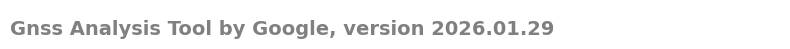

In [37]:
# @title Version

# Version of the tool, must be updated manually whenever the colab changes.
TOOL_VERSION='2026.01.29'

import matplotlib.pyplot as plt
def show_title_and_version(version:str):
    """Creates a text-based icon on a single line using Google's colors."""
    fig, ax = plt.subplots(figsize=(8, .5))  # Adjusted for a single line
    text = "Gnss Analysis Tool by Google, version " + version
    bbox = ax.text(0.0,0.5, text, color='#808080', fontsize=14, fontweight='bold', fontname="sans-serif", ha='left', va='top', transform=ax.transAxes).get_window_extent(renderer=fig.canvas.get_renderer())
    text_width = bbox.width
    ax.axis('off')
    plt.tight_layout()
    plt.show()
show_title_and_version(TOOL_VERSION)

In [ ]:
# === CHANGE THESE FOR EACH DEVICE ===
LOG_DIR          = r"../Log1"                                 # folder with gnss_log_*.txt
DEVICE_NAME      = "Xiaomi 13 (Qualcomm MPSS.HI.4.3.1)"    # label for reports
BIAS_UNC_THRESH  = 200.0   # ns -- relax to 200 for MPSS.HI; standard is 40

# Trace settings
DEVICE_TYPE      = "PHONE"   # "PHONE" or "WATCH"
IS_STATIC_TRACE  = False     # set True for a stationary recording; enables stricter ADR/PRR thresholds
STATIC_LATITUDE_DEG   = -1   # override only if IS_STATIC_TRACE=True and you know exact position
STATIC_LONGITUDE_DEG  = -1
STATIC_ALTITUDE_WGS84_M = -1

import pathlib as _pl, re as _re
_txt = next(_pl.Path(LOG_DIR).glob("gnss_log_*.txt"))
GNSS_LOGGER = str(_txt)

# Auto-detect OUTPUT_DIR
OUTPUT_DIR = _pl.Path(LOG_DIR) / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device    : {DEVICE_NAME}")
print(f"Log file  : {_txt.name}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"BiasUnc   : {BIAS_UNC_THRESH} ns")


# Overview and Instructions

This notebook is a comprehensive tool for analyzing GNSS logs. It validates receiver performance against a set of conformance checks and visualizes signal quality metrics.

### What this notebook does:
*   **Parses Raw Logs**: Loads GNSS measurement data from text files (e.g., from the GNSS Logger app).
*   **Conformance Testing**: Automatically checks various metrics against defined thresholds, including:
    *   **C/N0 Analysis**: Signal strength of the strongest satellites.
    *   **Time Synchronization**: Jitter and clock discontinuity analysis.
    *   **Measurement Quality**: Residuals for Pseudorange (PR), Accumulated Delta Range (ADR), and Pseudorange Rate (PRR).
*   **Visualization**: Generates charts for C/N0, clock bias, and a summary "Spider Plot" to visualize conformance status.

### How to use it:
1.  **Setup**: In the [Setup](#scrollTo=Setup) cell below, select the `DEVICE_TYPE`, and specify the path to your log file in the `GNSS_LOGGER` variable:

    ```
    'path/to/your/gnss_logger.txt'
    ```


2.  **Run Analysis**: Execute all cells in the notebook (`Runtime` > `Run all`).
3.  **Inspect Results**: Scroll through the notebook to view detailed plots for each metric and the final [Conformance Checks](#scrollTo=Conformance_Checks)  to see pass or fail test [Results](#scrollTo=Results)

### Video instructions:
[For Google Partners: How to Use GNSS Analysis Colab](https://drive.google.com/file/d/19Ohp6iY4ubt68_qMsqjX5R3frYzYEYWv/view?usp=drivesdk)

In [38]:
# @title Setup (auto-configured -- edit the CONFIG cell above, not here)

NMEA_GROUND_TRUTH = ""   # path to NMEA ground-truth file, or empty

SELF_TEST_MODE = False

# Initialize global constants (overridden later when file is loaded)
LOG_FILE_NAME = GNSS_LOGGER
MODEL_NAME    = DEVICE_NAME


# Utilities

In [39]:
#@title Conformance Thresholds

# Metric thresholds required for performance conformance.
# These are assumed to be for dynamic situations in open sky.
# See the STATIC_CONF_OVERRIDES for open sky static thresholds.
# By convention, all percents are [0, 100].
BASE_CONF = {
    # Basic Checks
    'USABLE_MSR_MIN_PCT': 85,
    'TOP_4_SATS_MIN_AVG_ANTENNA_CN0': 40,
    'EPOCH_DELTA_TIME_MAX_SEC': 2.15,
    # === Time-sync ===
    'DELTA_ELAPSED_NANOS_MAX_STD_MILLIS': 2.5,
    # max(delta(elapsedRealtimeNanos)) - min(delta(elapsedRealtimeNanos))
    'DELTA_ELAPSED_NANOS_MAX_DIFFERENCE_MILLIS': 1,
     # std(delta(gps_millis-elapsedRealtimeNanos))
    'TIME_SYNC_MAX_STD_MILLIS': 2.5,
    # max(abs(delta(gps_millis-elapsedRealtimeNanos)))
    'TIME_SYNC_MAX_DIFFERENCE_MILLIS': 2.2,
    # Usable ADR
    'VALID_ADR_MIN_PCT': 70,
    'USABLE_ADR_MIN_PCT': 65,
    'MAX_PERCENT_ADR_VARIABILITY': 5.0,
    # === Rate Bias (PRR-Delta(ADR)) ===
    'RATE_BIASE_MAX_ABS_MEDIAN_MPS': 0.07,
    'RATE_BIASE_MAX_STD_MPS': 0.25,
    # === PR Noise ===
    'MAX_RMS_L1_DELTA_PR_MINUS_DELTA_ADR_M': 7.0,
    'MAX_RMS_L5_DELTA_PR_MINUS_DELTA_ADR_M': 0.85,
    # === PR analysis ===
    'L1_PR_RESIDUAL_MAX_CENTER_STD_M': 6.5,
    'L5_PR_RESIDUAL_MAX_CENTER_STD_M': 4.0,
    'L1_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M': 5.0,
    'L5_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M': 4.5,
    'CLOCK_BIAS_MAX_CENTER_STD_MPS': 2.0,
    'MAX_PERCENT_PR_RESIDUAL_OUTLIERS': 5.0,
    # === ADR residuals ===
    # ADR residual std of (3, 97) percentiles (to remove outliers).
    'ADR_RESIDUAL_MAX_CENTER_STD_M': 0.015,
    'NORMALIZED_ADR_RESIDUAL_MAX_MEDIAN_M': 0.025,
    # ADR epoch is considered bad if max(abs(residual)) > than this.
    'ADR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_M': 0.15,
    # Percent of 'BAD' ADR epochs allowed.
    'ADR_RESIDUAL_MAX_PCT_BAD_EPOCHS': 5,
    'ADR_RESIDUAL_MIN_EPOCHS_FOR_SUFFICIENT_STATS': 30,
    # When computing ADR residuals, we're either solving for dx,dy,dz,db
    # (no static or Ground Truth) or db (with static or with Ground Truth). In
    # either case we need a few signals beyond the minimum amount to make
    # residual analysis meaningful.
    # Any epoch with the number of ADR signals below this threshold will be
    # dropped from the analysis. MIN_ADR_SIGNALS_FOR_EPOCH_YES_GT is used a
    # threshold when solving for db only, while MIN_ADR_SIGNALS_FOR_EPOCH_NO_GT
    # is used as a threshold when solving for dx,dy,dz,db.
    'MIN_ADR_SIGNALS_FOR_EPOCH_YES_GT': 3,
    'MIN_ADR_SIGNALS_FOR_EPOCH_NO_GT': 6,
    # === PRR residuals ===
    # PRR residual std of (3, 97) percentiles (to remove outliers).
    'PRR_RESIDUAL_MAX_CENTER_STD_MPS': 0.21,
    'NORMALIZED_PRR_RESIDUAL_MAX_MEDIAN_MPS': 0.2,
    'PRR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_MPS': 1.5,
    'PRR_RESIDUAL_MAX_PCT_BAD_EPOCHS': 28,
    # === Time tag jitter ===
    'JITTER_MAX_STD_SEC': 1e-3,
    'MAX_GPS_MILLIS_JUMP_NO_DISCONTINUITY_SEC': 0.1,
    # === Basic Checks on BaseSignalType ===
    'SIG_TYPE_REQUIRED': ['GPS_L1', 'GAL_E1', 'GLO_G1', 'GPS_L5', 'GAL_E5A'],
    'SIG_TYPE_PER_EPOCH_MIN_AVG': {
        'GPS_L1': 7.5,
        'GPS_L5': 3.5,
        'GLO_G1': 4,
        'QZS_J1': 1,
        'QZS_J5': 1,
        'BDS_B1C': 4,
        'BDS_B1I': 5,
        'BDS_B2A': 4,
        'GAL_E1': 5,
        'GAL_E5A': 4.5,
        'GAL_E5B': 4.5,
    }
}

# If a static traces is used, override certain conformance thresholds with these values.
STATIC_CONF_OVERRIDES = {
  'VALID_ADR_MIN_PCT': 90,
  'USABLE_ADR_MIN_PCT': 86,
  'ADR_RESIDUAL_MAX_PCT_BAD_EPOCHS': 2,
  'PRR_RESIDUAL_MAX_CENTER_STD_MPS': 0.1,
  'PRR_RESIDUAL_MAX_PCT_BAD_EPOCHS': 2,
}

assert set(STATIC_CONF_OVERRIDES.keys()).issubset(BASE_CONF.keys()), "Static override key not in BASE_CONF"


In [40]:
# @title Imports, Constants

# Standard Library
import copy
import enum
import functools
import math
import os
import re
from collections import defaultdict, deque
from datetime import datetime, timedelta, timezone
from io import StringIO
from itertools import chain
from math import ceil
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union
import unittest
import urllib.request
import tempfile
import colorsys

import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, UnivariateSpline, splev, splrep
import seaborn as sns
from matplotlib import pyplot as plt, font_manager as fm
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from dataclasses import dataclass, field
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

from IPython.display import HTML, display

try:
  import pymap3d
except ImportError:
  print('Attempting to install pymap3d.')
  # This is a command meant for external colab, internal colab may not work and may require a custom runtime.
  try:
    %pip install pymap3d
    import pymap3d
  except Exception as e:
    print('Failed to install pymap3d lib (needed for lla->ecef conversion for approximate location).')
    raise e

MIN_CN0_ALLOWED_DBHZ = 20
MIN_EL_ALLOWED_CN0_ANALYSIS_DEG = 5

# We are more strict on Cn0 and elevation for ADR analysis.
MIN_CN0_ALLOWED_ADR_ANALYSIS_DBHZ = 20
MIN_ELEV_ALLOWED_FOR_ADR_ANALYSIS = 20


# A map from base signal type to ISRB in meters. This should have {GPS_L1:0.0}.
IsrbDict = Dict[str, float]

# Speed of light in m/s defined by the various GNSS ICDs, see go/gnss-system-constants
LIGHTSPEED_MPS = 2.99792458e8
# WGS 84 value of earth's rotation rate (rad/s).
EARTH_ROTATION_RPS = 7.2921151467e-5

SEMI_TO_RAD = math.pi

# 4-th degee Taylor polynomial for cos()
COS_TAYLOR_POLY_4 = np.poly1d([1.0 / 24.0, 0.0, -0.5, 0.0, 1.0])

# Number of seconds from the GPS epoch to the UTC epoch.
# This is a normal delta, with no leap seconds considered.
GPS_UTC_EPOCHS_OFFSET_SECONDS = 315964800

GPS_L1_CENTER_FREQ_HZ = 1575420000

# These are required cols for satpvt related computations.
REQUIRED_SATPVT_COLS = [
    'SvPositionEcefXMeters',
    'SvPositionEcefYMeters',
    'SvPositionEcefZMeters',
    'SvVelocityEcefXMetersPerSecond',
    'SvVelocityEcefYMetersPerSecond',
    'SvVelocityEcefZMetersPerSecond',
    'SvHardwareCodeBiasMeters',
    'SvClockBiasMeters',  #'SvClockInfoTimeCorrectionMeters',
    'SvClockDriftMetersPerSecond',  #'SvClockInfoTimeClockDriftMetersPerSecond',
    'SvIonoDelayMeters',
    'SvTropoDelayMeters',
]

# Older versions of DEBUG gnss logger used different column names.
LEGACY_SATPVT_TO_MODERN_SATPVT = {
    'SvClockInfoHardwareCodeBiasMeters': 'SvHardwareCodeBiasMeters',
    'SvClockInfoTimeCorrectionMeters': 'SvTimeCorrectionMeters',
    'SvClockInfoTimeClockDriftMetersPerSecond': (
        'SvTimeClockDriftMetersPerSecond'
    ),
}

CHIPSET_TO_SATPVT_STANDARD = {
    'SvTimeCorrectionMeters': 'SvClockBiasMeters',
    'SvTimeClockDriftMetersPerSecond': 'SvClockDriftMetersPerSecond',
}

CONSTEL_FREQ_TABLE = {
    0: {'UNKNOWN': (0, 999999999999)},
    1: {
        'GPS_L1': (1563000000, 1587000000),
        'GPS_L2': (1215000000, 1240000000),
        'GPS_L5': (1164000000, 1189000000),
    },
    3: {'GLO_G1': (1593000000, 1610000000), 'GLO_G2': (1237000000, 1254000000)},
    4: {
        'QZS_J1': (1563000000, 1587000000),
        'QZS_J2': (1215000000, 1240000000),
        'QZS_J5': (1164000000, 1189000000),
    },
    5: {
        'BDS_B1C': (1569000000, 1583000000),
        'BDS_B1I': (1553000000, 1568990000),
        'BDS_B2A': (1164000000, 1189000000),
        'BDS_B2B': (1189000000, 1225000000),
    },
    6: {
        'GAL_E1': (1559000000, 1591000000),
        'GAL_E5A': (1164000000, 1189000000),
        'GAL_E5B': (1189000000, 1218000000),
        'GAL_E6': (1258000000, 1300000000),
    },
}


# Code type priorities taken from compacting this list:
#   G:12&PWCSLX G:5&IQX R:12&PC R:3&IQX R:46&ABX E:16&BCXZ E:578&IQX
#   J:1&SLXCZ J:26&SLX J:5&IQX C:267&IQX C:18&DPX I:ABCX S:1&C S:5&IQX
# https://software.rtcm-ntrip.org/export/HEAD/ntrip/trunk/BNC/src/bnchelp.html#rnxvers2
CODE_TYPE_PRIORITY = 'DPWABCSLIQXZ'

L5_FREQ_SIGNAL_TYPES = [
    'GPS_L5',
    'QZS_J5',
    'BDS_B2A',
    'BDS_B2B',
    'GAL_E5A',
    'GAL_E5B',
]

CONSTEL_ID_MAP = {
    1: 'GPS', 3: 'GLO', 4: 'QZS', 5: 'BDS', 6: 'GAL', 7: 'NVC'
}


In [41]:
# @title Util Methods: Reading, Processing


def GetCodeTypeRanking(full_sig_type: str) -> int:
  """Returns a numerical value of code type ranking, lower is better and 'UNKNOWN' maps to the largest value."""
  code = full_sig_type.split('_')[-1]
  if len(code) != 1 or code not in CODE_TYPE_PRIORITY:
    return 999
  return CODE_TYPE_PRIORITY.index(code)


class GnssMeasurementState(enum.Flag):
  """Represents the bit flags of GnssMeasurement#getState.

  See: https://developer.android.com/reference/android/location/GnssMeasurement
  """

  STATE_UNKNOWN = 0x00000
  STATE_CODE_LOCK = 0x00001
  STATE_BIT_SYNC = 0x00002
  STATE_SUBFRAME_SYNC = 0x00004
  STATE_TOW_DECODED = 0x00008
  STATE_MSEC_AMBIGUOUS = 0x00010
  STATE_SYMBOL_SYNC = 0x00020
  STATE_GLO_STRING_SYNC = 0x00040
  STATE_GLO_TOD_DECODED = 0x00080
  STATE_BDS_D2_BIT_SYNC = 0x00100
  STATE_BDS_D2_SUBFRAME_SYNC = 0x00200
  STATE_GAL_E1BC_CODE_LOCK = 0x00400
  STATE_GAL_E1C_2ND_CODE_LOCK = 0x00800
  STATE_GAL_E1B_PAGE_SYNC = 0x01000
  STATE_SBAS_SYNC = 0x02000
  STATE_TOW_KNOWN = 0x04000
  STATE_GLO_TOD_KNOWN = 0x08000
  STATE_2ND_CODE_LOCK = 0x10000

  def IsUsableForPr(self, constellation: int, sig_type: str) -> bool:
    """Given the signal type returns whether this state is usable for PR.

    Args:
      sig_type: signal_type.SignalType of the measurement

    Returns:
      True if the measurement can be used for pseudorange measurements.
    """
    if sig_type in ['GAL_E1_UNKNOWN', 'GAL_E1_B', 'GAL_E1_C']:
      # TODO: Possibly remove the check for STATE_CODE_LOCK if we
      # don't have to support devices without the chipset fix or traces from
      # those devices.  For now, check if either code lock bit is set.
      if (
          GnssMeasurementState.STATE_CODE_LOCK not in self
          and GnssMeasurementState.STATE_GAL_E1BC_CODE_LOCK not in self
      ):
        return False
      if self._ShouldDiscardGalE1():
        return False
    else:
      if GnssMeasurementState.STATE_CODE_LOCK not in self:
        return False
    if not self.IsTowReady(constellation):
      return False
    return True

  def IsTowReady(self, constel: int) -> bool:
    """Returns whether the time-of-week (or day) is ready.

    Args:
      constel: constellation int type of the measurement

    Returns:
      True if the measurement state shows that the measurement has the info
      required to determine the time the signal was transmitted.
    """
    if constel == 3:  # GLONASS
      if (
          GnssMeasurementState.STATE_GLO_TOD_KNOWN not in self
          and GnssMeasurementState.STATE_GLO_TOD_DECODED not in self
      ):
        return False
    else:
      if (
          GnssMeasurementState.STATE_TOW_DECODED not in self
          and GnssMeasurementState.STATE_TOW_KNOWN not in self
      ):
        return False
    return True

  def _ShouldDiscardGalE1(self) -> bool:
    """Should a GAL_E1 measurement be discarded (special logic required for a buggy chipset)."""
    cls = GnssMeasurementState
    return (
        (cls.STATE_GAL_E1C_2ND_CODE_LOCK not in self)
        and (cls.STATE_2ND_CODE_LOCK not in self)
        and (cls.STATE_TOW_DECODED in self)
        and (cls.STATE_GAL_E1B_PAGE_SYNC in self)
    )


def GetSignalTypeWithCodeType(
    constel: int, freq_hz: float, code_type: str
) -> str:
  """Returns the signal type based on constellation, frequency and code type."""
  code_type = code_type if len(code_type) == 1 else 'UNKNOWN'
  sig_type = GetBaseSignalType(constel, freq_hz)
  if sig_type != 'UNKNOWN':
    sig_type += '_' + code_type
  return sig_type


def GetBaseSignalType(constel: int, freq_hz: float) -> str:
  """Returns a signal type, without CodeType, from constellation and frequency."""
  freqs = CONSTEL_FREQ_TABLE.get(constel, {})
  for id_freq_range in freqs.items():
    rng = id_freq_range[1]
    if rng[0] <= freq_hz <= rng[1]:
      return id_freq_range[0]
  return 'UNKNOWN'


def IsAdrStateUsable(adr_state: int) -> bool:
  """Checks if the ADR state is usable for ADR positioning."""
  # return true if adr_state ends in bx001.
  # this corresponds to (not ADR_STATE_UNKNOWN) & ADR_STATE_VALID & ...
  #  (not ADR_STATE_RESET) & (not ADR_STATE_CYCLE_SLIP)
  # ADR_STATE_HALF_CYCLE_RESOLVED, ADR_STATE_HALF_CYCLE_REPORTED are ignored
  return (adr_state & 0b111) == 0b001


def IsAdrStateValid(adr_state: int) -> bool:
  """Checks if the ADR state is valid."""
  # return true if adr_state ends in bx1.
  # this corresponds to (not ADR_STATE_UNKNOWN) & ADR_STATE_VALID & ...
  #  (not ADR_STATE_RESET) & (not ADR_STATE_CYCLE_SLIP)
  # ADR_STATE_HALF_CYCLE_RESOLVED, ADR_STATE_HALF_CYCLE_REPORTED are ignored
  return (adr_state & 0b1) == 0b1


def LoadFixes(gnss_logger_path: str) -> pd.DataFrame:
  """Reads 'Fix' rows from Gnss Logger and produces a dataframe where each row corresponds to a fix."""
  with open(gnss_logger_path) as file:
    fix_lns = [
        ln.replace('#', '').strip().split(',')
        for ln in file.readlines()
        if 'Fix' in ln[:10] and not 'format:' in ln
    ]
  col_names = fix_lns[0]
  # Some versions of GNSS logger have a mismatch between the header and number
  # of entires in the Fix rows.
  data_rows = [c[: len(col_names)] for c in fix_lns[1:]]
  df = pd.DataFrame(data_rows, columns=col_names)
  # Some columns may be imported as 'Object' type, but we want everything to be numeric.
  for c in df.columns:
    if c != 'Fix' and c != 'Provider':
      df[c] = pd.to_numeric(df[c], errors='coerce')
  # Drop rows with missing UnixTimeMillis.
  df.dropna(subset=['UnixTimeMillis'], inplace=True)
  df.sort_values(by=['UnixTimeMillis', 'Provider'], inplace=True)
  return df


def UtcMillisFromNmea(date_str: str, gpgga_time: str) -> int:
  """Converts date_str and gpgga_time to utcTimeMillis.

  Args:
    date_str: the date, example: '270824' is Aug 27th, 2024
    gpgga_time: time of day in utc, example '200744.00' is 8:07::44.00

  Returns: milliseconds since the utc epoch.
  """
  assert len(date_str) == 6
  dt = datetime.strptime(date_str + gpgga_time, '%d%m%y%H%M%S.%f')
  utc_secs = dt.replace(tzinfo=timezone.utc).timestamp()
  return int(utc_secs * 1000)


def ReadNmeaGroundTruth(nmea_ground_truth_path: str) -> Optional[pd.DataFrame]:
  """Returns a dataframe of NMEA ground truth with columns: utcTimeMillis, GtEcefXMeters, GtEcefYMeters, GtEcefZMeters.

  It is expected that these GT locations will correspond to the ground truth
  location at the raw GNSS measurement times.
  """
  utc_tod_idx = 1
  lat_idx = 2
  lat_dir_idx = 3
  lon_idx = 4
  lon_dir_idx = 5
  alt_above_mean_sea_level_idx = 9
  undulation_idx = 11  # relationship between the geoid and the WGS84 ellipsoid

  GPRMC_date_idx = 9

  lng_col_idx = 1
  alt_col_idx = 2
  rows = []
  utc_tod_to_datestr = {}
  with open(nmea_ground_truth_path) as file:
    for line in file.readlines():
      splt = line.split(',')
      if splt[0] == '$GPRMC':
        # We only need to get the date.
        utc_tod_to_datestr[splt[utc_tod_idx]] = splt[GPRMC_date_idx]
        continue
      if splt[0] != '$GPGGA':
        continue
      lat_val = float(splt[lat_idx])
      lat_deg = int(lat_val / 100) + (lat_val / 100 - int(lat_val / 100)) / 0.6
      if splt[lat_dir_idx] == 'S':
        lat_deg = -lat_deg
      lng_val = float(splt[lon_idx])
      lng_deg = int(lng_val / 100) + (lng_val / 100 - int(lng_val / 100)) / 0.6
      if splt[lon_dir_idx] == 'W':
        lng_deg = -lng_deg

      d = {
          'UtcTod': splt[utc_tod_idx],
          'GtLatDeg': lat_deg,
          'GtLngDeg': lng_deg,
          'GtAltAboveSeaM': float(splt[alt_above_mean_sea_level_idx]),
          'Undulation': float(splt[undulation_idx]),
      }
      rows.append(d)

  df = pd.DataFrame(rows)
  df['GtAltWgs84M'] = df['GtAltAboveSeaM'] + df['Undulation']
  df['utcTimeMillis'] = df.apply(
      lambda r: UtcMillisFromNmea(
          utc_tod_to_datestr.get(r['UtcTod'], '000000'), r['UtcTod']
      ),
      axis=1,
  )

  df[['GtEcefXMeters', 'GtEcefYMeters', 'GtEcefZMeters']] = LlaToEcefM(
      df['GtLatDeg'], df['GtLngDeg'], df['GtAltWgs84M']
  )
  if np.any(
      ~np.isfinite(df[['GtEcefXMeters', 'GtEcefYMeters', 'GtEcefZMeters']])
  ):
    return None
  return df[
      ['utcTimeMillis', 'GtEcefXMeters', 'GtEcefYMeters', 'GtEcefZMeters']
  ].copy()


def LlaToEcefM(
    lat_deg: Union[float, np.ndarray],
    lng_deg: Union[float, np.ndarray],
    alt_m: Union[float, np.ndarray],
) -> Optional[np.ndarray]:
  return np.array(pymap3d.ecef.geodetic2ecef(lat_deg, lng_deg, alt_m)).T


def StandardizeSatpvtColNames(
    df: pd.DataFrame, is_debug_gnss_logger_version: bool
) -> pd.DataFrame:
  """Maps satpvt columns to the naming scheme consistent with release gnss logger.

  If is_debug_gnss_logger_version=True, then only load satpvt provided by the
  chipset.
  Otherwise, load satpvt provided by gnss logger.

  Fail if satpvt is missing.

  An exception will be thrown if satpvt columns are missing.
  """
  # As of mid 2025, here are the four versions of gnss logger floating around:
  # 1. no satpvt: fail
  # 2. chipset satpvt (legacy names): rename columns to release versions
  # 3. gnss logger satpvt, debug_mode=false: give warning about missing fields and add dummy values
  # 4. chipset satpvt (modern name) AND gnss logger satpvt: rename chipset fields, remove gnss logger fields

  gnss_logger_satpvt_cols = [
      'SvPositionEcefXMeters',
      'SvPositionEcefYMeters',
      'SvPositionEcefZMeters',
      'SvVelocityEcefXMetersPerSecond',
      'SvVelocityEcefYMetersPerSecond',
      'SvVelocityEcefZMetersPerSecond',
      'SvClockBiasMeters',
      'SvClockDriftMetersPerSecond',
      'KlobucharAlpha0',
      'KlobucharAlpha1',
      'KlobucharAlpha2',
      'KlobucharAlpha3',
      'KlobucharBeta0',
      'KlobucharBeta1',
      'KlobucharBeta2',
      'KlobucharBeta3',
  ]
  orig_col_names = set(df.columns)
  has_gnss_logger_satpvt_cols = 'KlobucharAlpha0' in df.columns
  if is_debug_gnss_logger_version:
    if 'ChipsetSvPositionEcefXMeters' in df.columns:
      cols_to_drop = [c for c in gnss_logger_satpvt_cols if c in df.columns]
      if cols_to_drop:
        print(
            'INFO: Dropping %d columns related to GNSS logger computed satpvt in'
            ' order to use chipset satpvt.'
            % len(cols_to_drop)
        )
        df.drop(
            columns=[c for c in cols_to_drop if c in df.columns], inplace=True
        )
      print('Renaming chipset columns to standard satpvt names.')
      df.rename(
          columns=lambda col: col.replace('Chipset', '', 1)
          if col.startswith('ChipsetSv')
          else col,
          inplace=True,
      )
      print(
          'Renamed %d chipset satpvt col names to legacy names.'
          % (len(orig_col_names - set(df.columns)))
      )
    else:
      # A few legacy column names need to be renamed.
      df.rename(columns=LEGACY_SATPVT_TO_MODERN_SATPVT, inplace=True)
    df.rename(columns=CHIPSET_TO_SATPVT_STANDARD, inplace=True)
  else:
    # Satpvts come from the gnss logger app.
    # Iono/tropo delays are missing. Add fillers for those values
    # (to compute later once we have lat/lng/alt and elevation)
    df[['SvIonoDelayMeters', 'SvTropoDelayMeters']] = np.nan
    df['SvHardwareCodeBiasMeters'] = 0
    print('WARNING: assuming code bias is 0.')

  missing_cols = set(REQUIRED_SATPVT_COLS) - set(df.columns)
  if missing_cols:
    print('ORIG COLS: %s' % sorted(orig_col_names))
    print('Missing satpvt columns %s' % list(missing_cols))
    LogFatal('Missing satpvt from gnss logger file, please update the gnss logger app.')
  return df


def LoadGnssData(gnss_logger_path: str) -> pd.DataFrame:
  """Reads from Gnss Logger and produces a dataframe where each row corresponds to a raw GNSS measurement."""
  with open(gnss_logger_path) as file:
    lns = file.readlines()
    is_debug_version = any(
        ln
        for ln in lns
        if 'DEBUG BUILD' in ln
    )
    if is_debug_version:
      print('Found debug version')
    raw_lns = [
        ln.replace('#', '').strip().split(',')
        for ln in lns
        if 'Raw,' in ln[:10] and not 'format:' in ln
    ]
  col_names = raw_lns[0]
  df = pd.DataFrame(raw_lns[1:], columns=col_names)

  # Generic cleanup of the df.
  df.drop(columns=['Raw'], inplace=True)
  # Some columns may be imported as 'Object' type, but we want everything to be numeric.
  cols_to_keep_str = ['CodeType']
  for c in df.columns:
    if c in cols_to_keep_str:
      df[c] = df[c].astype(str)
    else:
      df[c] = pd.to_numeric(df[c], errors='coerce')

  # If needed, rename satpvt columns to legacy names.
  StandardizeSatpvtColNames(df, is_debug_version)

  # New columns derived from other fields.
  df['SignalType'] = df[
      ['ConstellationType', 'CarrierFrequencyHz', 'CodeType']
  ].apply(
      lambda r: GetSignalTypeWithCodeType(r.iloc[0], r.iloc[1], r.iloc[2]),
      axis=1,
  )
  df['BaseSignalType'] = df[['ConstellationType', 'CarrierFrequencyHz']].apply(
      lambda r: GetBaseSignalType(r.iloc[0], r.iloc[1]), axis=1
  )
  df['Constellation'] = df['ConstellationType'].map(CONSTEL_ID_MAP).fillna('OTHER')

  # Add boolean column indicating if the given measurement has valid ADR.
  df['AccumulatedDeltaRangeState'] = np.nan_to_num(df['AccumulatedDeltaRangeState']).astype(int)
  df['AdrValid'] = df['AccumulatedDeltaRangeState'].apply(
      IsAdrStateValid
  ) & np.isfinite(df['AccumulatedDeltaRangeMeters'])
  df['AdrUsable'] = df['AccumulatedDeltaRangeState'].apply(
      IsAdrStateUsable
  ) & np.isfinite(df['AccumulatedDeltaRangeMeters'])
  df['GpsMillis'] = (
      df['TimeNanos'] - df['FullBiasNanos'] - df['BiasNanos']
  ) / 1e6
  df['ElapsedSec'] = (
      df['GpsMillis'].to_numpy() - min(df['GpsMillis'].to_numpy())
  ) / 1e3
  df['State'] = np.nan_to_num(df['State']).astype(int)
  df['MeasurementUsable'] = df.apply(
      lambda r: GnssMeasurementState(r['State']).IsUsableForPr(
          r['ConstellationType'], r['SignalType']
      ),
      axis=1,
  )

  return df[
      df.SignalType != 'UNKNOWN'
  ].copy()  # Drop unknown signal types, like SBAS.


def CalculateDeltaMeasurements(df: pd.DataFrame) -> pd.DataFrame:
  """Takes a dataframe of Raw Measurements from Gnss Logger, and adds Delta measurement columns based on the prior epoch.."""
  time_col = 'GpsMillis'
  time_col_units_per_second = 1000
  # time_col = 'utcTimeMillis'
  # time_col_units_per_second = 1000
  # time_col = 'TimeNanos'
  # time_col_units_per_second = 1e9
  next_time_col = 'next' + time_col

  timestamps = list(df[time_col].unique())
  # Create dict from {cur_time -> next_time}. Don't match epochs more than 1.1sec apart.
  cur_time_to_next_time = {
      cur: next
      for cur, next in zip(timestamps[:-1], timestamps[1:])
      if 0.9 <= np.abs(next - cur) / time_col_units_per_second <= 1.1
  }
  for t in timestamps:
    if t not in cur_time_to_next_time:
      cur_time_to_next_time[t] = -999

  df_prev = df.copy()
  # Createa new column, next_time_col, whose values is the timestamp of the next epoch.
  df_prev[next_time_col] = df_prev[time_col].map(cur_time_to_next_time)

  # Match signals from epoch i to i+1
  df_joined = df.merge(
      df_prev[df_prev[next_time_col] != -999],
      how='left',
      left_on=[time_col, 'Svid', 'SignalType'],
      right_on=[next_time_col, 'Svid', 'SignalType'],
      suffixes=('', '_prev'),
      validate='one_to_one',
  )
  # cast all '_prev' column types to the orignal column type.
  for c in df_joined.columns:
    if '_prev' in c:
      orig_c = c.replace('_prev', '')
      df_joined[c] = df_joined[c].fillna(0).astype(df[orig_c].dtypes)

  # Create delta columns.
  df_joined[
      ['DeltaPrM', 'DeltaPrMps', 'DeltaAdrM', 'DeltaAdrMps', 'DeltaTimeSec']
  ] = np.nan

  df_joined['DeltaPrM'] = (
      df_joined['PseudorangeMeters'] - df_joined['PseudorangeMeters_prev']
  )

  adr_usable_idx = (
      (df_joined['AdrUsable'] == True)
      & (df_joined['AdrUsable_prev'] == True)
      & (df_joined['SvPositionEcefXMeters'] != 0)
  )

  df_joined.loc[adr_usable_idx, 'DeltaAdrM'] = (
      df_joined[adr_usable_idx]['AccumulatedDeltaRangeMeters']
      - df_joined[adr_usable_idx]['AccumulatedDeltaRangeMeters_prev']
  )
  df_joined['DeltaTimeSec'] = (
      df_joined[time_col] - df_joined[time_col + '_prev']
  ) / time_col_units_per_second
  df_joined['DeltaPrMps'] = df_joined['DeltaPrM'] / df_joined['DeltaTimeSec']

  df_joined.loc[adr_usable_idx, 'DeltaAdrMps'] = (
      df_joined.loc[adr_usable_idx, 'DeltaAdrM'].to_numpy()
      / df_joined[adr_usable_idx]['DeltaTimeSec'].to_numpy()
  )
  df_joined['HasClockDiscontinuity'] = (
      df_joined['HardwareClockDiscontinuityCount']
      != df_joined['HardwareClockDiscontinuityCount_prev']
  ) & (np.isfinite(df_joined['HardwareClockDiscontinuityCount_prev']))

  if 'SvIssueOfDataEphemeris' in df_joined.columns:
    df_joined['HasEphemerisDiscontinuity'] = (
        df_joined['SvIssueOfDataEphemeris']
        != df_joined['SvIssueOfDataEphemeris_prev']
    ) & (np.isfinite(df_joined['SvIssueOfDataEphemeris_prev']))
  else:
    df_joined['HasEphemerisDiscontinuity'] = False

  if 'PrrCommonBiasMps' in df_joined.columns:
    df_joined['DeltaPrrCommonBiasMps'] = (
        df_joined[adr_usable_idx]['PrrCommonBiasMps']
        - df_joined[adr_usable_idx]['PrrCommonBiasMps_prev']
    ) / df_joined['DeltaTimeSec']

  # If a '*_prev' columns contains any of these substrings, don't drop the col.
  subset_col_names_to_keep = [
      'PseudorangeMeters',
      'AccumulatedDeltaRange',
      'SvPositionEcef',
      'AdrUsable',
      'SvClock',
      'SvHardwareCodeBiasMeters',
  ]
  cols_to_drop = [
      c
      for c in df_joined.columns
      if '_prev' in c
      and not any((keepsub in c) for keepsub in subset_col_names_to_keep)
  ] + [next_time_col]
  return df_joined.drop(cols_to_drop, axis=1)


def SvVis(
    sv_xyz_ecef_m: np.ndarray, obs_ecef_m: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
  """Returns the  distance from each satellite to the observer (in meters).

  Args:
    sv_xyz_ecef_m: (np.ndarray, n x 3)  each row represents the xyz pos of each
      satellite in meters
    obs_ecef_m: (np.ndarray, 1 x 3) xyz of the observer in meters.

  Returns:
    tuple <distance_array_m, unit_vector_array>
  """
  repeated_obs_ecef_m = np.broadcast_to(
      obs_ecef_m.transpose(), (len(sv_xyz_ecef_m), len(obs_ecef_m))
  )
  delta = sv_xyz_ecef_m - repeated_obs_ecef_m
  l2_norm = np.linalg.norm(delta, ord=2, axis=1)
  unit_delta = delta / l2_norm[:, np.newaxis]
  return l2_norm, unit_delta


def GeoRangesM(
    obs_ecef_m: np.ndarray, sv_xyz_at_ttx_in_ecef_at_ttx: np.ndarray
) -> np.ndarray:
  """Returns the georanges between the user at time TTX and the satellites at time TTX in TTX coordinates.

  Args:
     obs_ecef_m: location of the user at TRX.
    sv_xyz_at_ttx_in_ecef_at_ttx: (n x 3) ndarray, location of the n satellites
      at TTX and in TTX coordinates.

  Returns:
    The georanges in meters from the user to the satellite. This includes the
    corrections for the Sagnac effect and is accurate within ~10e-3 meters.
  """
  num_sats = sv_xyz_at_ttx_in_ecef_at_ttx.shape[0]
  usr = np.broadcast_to(obs_ecef_m.transpose(), (num_sats, len(obs_ecef_m)))
  ttx_l2 = np.linalg.norm(usr - sv_xyz_at_ttx_in_ecef_at_ttx, axis=1)
  trx_correction = (
      EARTH_ROTATION_RPS
      * (
          sv_xyz_at_ttx_in_ecef_at_ttx[:, 0] * usr[:, 1]
          - sv_xyz_at_ttx_in_ecef_at_ttx[:, 1] * usr[:, 0]
      )
      / LIGHTSPEED_MPS
  )
  return np.squeeze(ttx_l2 + trx_correction)


def FlightTimeCorrection(
    sv_xyz_ecef_m_ttx: np.ndarray, flight_time_sec: np.ndarray
) -> np.ndarray:
  """Returns new ECEF coordinates after the earth has rotated flight_time_sec.

  Handles the case where sv_xyz_ecef_m_ttx has shape (3) or shape (n,3), for n
  different satellites.

  Args:
    sv_xyz_ecef_m_ttx: np.array, [n x 3] size. (x,y,z) ECEF coordinates of the
      satellite in meters
    flight_time_sec: float or nd.array of size n, duration the earth has rotated
      in seconds

  Returns:
    a new satellite location with respect to ECEF coordinates flight_time_sec in
    the past.
  """
  orig_shape = sv_xyz_ecef_m_ttx.shape
  sv_xyz_ecef_m_ttx = np.reshape(sv_xyz_ecef_m_ttx, (-1, 3))
  theta = EARTH_ROTATION_RPS * np.squeeze(flight_time_sec)
  cos_theta = np.cos(theta)
  sin_theta = np.sin(theta)
  x = sv_xyz_ecef_m_ttx[:, 0] * cos_theta + sv_xyz_ecef_m_ttx[:, 1] * sin_theta
  y = -sv_xyz_ecef_m_ttx[:, 0] * sin_theta + sv_xyz_ecef_m_ttx[:, 1] * cos_theta
  return np.column_stack((x, y, sv_xyz_ecef_m_ttx[:, 2])).reshape(orig_shape)


def CenterMassStd(
    vals: Union[np.ndarray, pd.Series], tail_percentile_to_trunc=3
) -> float:
  """Returns a standard deviation measure that is robust to tail outliers.

  Args:
    vals: numpy array or pd.Series with values
    tail_percentile_to_trunc: amount of tail-percentile that will be removed
      from the tails, 0 <= tail_percentile_to_trunc<=49.

  Returns:
    a robust measure of standard deviation
  """
  if len(vals)==0:
    return np.nan
  p_low, p_high = np.nanpercentile(
      vals, [tail_percentile_to_trunc, 100 - tail_percentile_to_trunc]
  )
  return np.nanstd(vals[(vals >= p_low) & (vals <= p_high)])


def ToFlattenedDeque(vals: Union[list[Any], list[list[Any]]]):
  """Converts a list (potentially nested) into a single deque."""
  try:
    return deque(chain(*vals))  #
  except:
    # axs is only 1d
    pass
  return deque(vals)


def Rms(arr: np.ndarray) -> float:
  """Calculates the Root Mean Square (RMS) of a NumPy array."""
  arr = arr[np.isfinite(arr)]
  if len(arr) == 0:
    return np.nan
  return np.sqrt(np.nanmean(arr**2))


def RobustMovingAverage(x:np.ndarray, y:np.ndarray, knot_interval:float = 40, gap_threshold:float = 100) -> np.ndarray:
    """Returns an array of length ||x||, with smoothed y values.

    x must be strictly increasing.
    """
    assert gap_threshold > knot_interval

    # Recursively fits splines to continuous segments of data.
    # Base Case: If no gaps > gap_threshold exist, fit a spline (or mean).
    # Recursive Step: If a gap exists, split at the largest gap and recurse.
    if len(x) <= 3:
        return np.full_like(y, np.mean(y) if len(y) > 0 else 0)

    # Check for gaps larger than gap_threshold.
    dt = np.diff(x)
    max_gap_idx = np.argmax(dt)
    max_gap = dt[max_gap_idx]
    assert min(dt) > 0, "x must be strictly increasing"

    if max_gap > gap_threshold:
        split_idx = max_gap_idx + 1
        left_smooth = RobustMovingAverage(x[:split_idx], y[:split_idx], knot_interval, gap_threshold)
        right_smooth = RobustMovingAverage(x[split_idx:], y[split_idx:], knot_interval, gap_threshold)
        return np.concatenate([left_smooth, right_smooth])

    try:
        duration_seg = x.max() - x.min()
        num_knots = max(2, ceil(duration_seg / knot_interval))
        knot_xvals = np.linspace(x.min(), x.max(), int(num_knots))[1:-1]
        tck = splrep(x=x, y=y, t=knot_xvals, k=3)
        return splev(x, tck)

    except (ValueError, TypeError, ArithmeticError) as e:
        # Fallback for numerical instability (e.g., perfectly collinear points)
        print('exceptoin, falling back to mean')
        return np.full_like(y, np.mean(y))

def LogFatal(message: str):
  """Prints a fatal error message in a red large font and then dies.

  Args:
      message: The message to display as a fatal error.
  """
  warning_html = (
      "<div style='color: red; font-size: 30px; font-weight: bold; text-align:"
      f" left;  padding: 10px;'>FATAL ERROR: {message}</div>"
  )
  display(HTML(warning_html))
  raise ValueError()


def LogWarning(message: str):
  """Prints a warning message in a red large font.

  Args:
      message: The message to display as a warning.
  """
  warning_html = (
      "<div style='color: red; font-size: 20px; font-weight: bold; text-align:"
      f" left;  padding: 10px;'>WARNING: {message}</div>"
  )
  display(HTML(warning_html))


def LogConformanceTestFailure(
    test_label: str, actual_value: str, expected_value: str
):
  """Displays an HTML formatted conformance test failure message with a yellow background."""

  test_failure_html = (
      "<div style='background-color: #FFFFE0; padding: 1px 0;'>"  # Light yellow background container
      "<div style='color: purple; font-size: larger; font-weight: bold;"
      " text-align: left; padding: 5px 10px;'>Conformance test failure:"
      f' {test_label}</div>'
      "<div style='text-align: left; padding: 5px 10px;'><span"
      f" style='font-weight: bold;'>Actual:</span> {actual_value}</div>"
      "<div style='text-align: left; padding: 5px 10px;'><span"
      f" style='font-weight: bold;'>Expected:</span> {expected_value}</div>"
      '</div>'
  )
  display(HTML(test_failure_html))


def AssertSatpvtAvailable(df:pd.DataFrame):
  """Raises a fatal error if satpvt is not available in the dataframe."""
  required_cols = REQUIRED_SATPVT_COLS.copy()
  # We don't need iono/tropo corrections at this point.
  required_cols.remove('SvIonoDelayMeters')
  required_cols.remove('SvTropoDelayMeters')

  # Asssert that at least one row has all the cols required for satpvt.
  if not np.any(np.all(np.isfinite(df[required_cols]), axis=1)):
    print("\nINSTRUCTIONS TO FIX THIS ERROR: Update GnssLogger app, and log data when your device has a network connection")
    LogFatal('Missing Satpvt data. No epoch contains values for every required column.')

class ConformanceCheckResults:
  """Conformance check results."""

  def __init__(self):
    # Each item is list ['Section', 'Check Name', 'Status', 'Details']
    self._df_rows = []

  def AddResult(
      self,
      section: str,
      metric: str,
      passed: bool,
      msg: str,
      requirement: str,
      description: str,
  ):
    status_str = self._StatusStr(passed)
    section_str = '<b>' + section.upper() + '</b>'
    v = {
        'Section': section_str,
        'Check Name': metric,
        'Status': status_str,
        'Details': msg,
        'Description': description,
    }
    v['Quality spec.'] = (
        "<div style='float: left; text-align: left'>%s</div>"
        % requirement.replace('\n', '<br>')
    )
    # Replace an existing row with the same section_name+ metric_name
    # If not found then append.
    for i, row in enumerate(self._df_rows):
      if row['Section'] == section_str and row['Check Name'] == metric:
        self._df_rows[i] = v
        break
    else:
      self._df_rows.append(v)

    if msg:
      # This saves us from having to re-print everything inside each cell.
      print(msg)

    if not passed:
      LogConformanceTestFailure(metric, msg, requirement)

  def Display(self) -> None:
    display_columns = ['Section', 'Check Name', 'Status', 'Details', 'Quality spec.']
    df = pd.DataFrame.from_dict(self._df_rows)
    display(
        HTML(
            df[display_columns].to_html(
                escape=False, index=False, columns=display_columns
            )
        )
    )

  def DisplaySummary(self) -> None:
    d = defaultdict(list)  # dict[Section, [list_of_rows]]
    for row in self._df_rows:
      d[row['Section']].append(row)

    rows = []  # ['Section', 'Status', 'Details']
    for section, status_rows in d.items():
      failed_checks = [
          s['Check Name'] for s in status_rows if 'Failed' in s['Status']
      ]
      passed = len(failed_checks) == 0
      status_str = self._StatusStr(passed)
      failure_str = ''
      n = len(status_rows)
      if failed_checks:
        failure_str = 'Fail: ' + ', '.join([f'"{z}"' for z in failed_checks])
      rows.append([
          '%s (Pass %d/%d)' % (section, n - len(failed_checks), n),
          status_str,
          f'<div style="text-align: left;">{failure_str}</div>',
      ])
    df = pd.DataFrame(rows, columns=['Section', 'Status', 'Details'])
    display(HTML(df.to_html(escape=False, index=False)))

  def DisplayRequirements(self) -> None:
    display_columns = ['Section', 'Description', 'Quality spec.']
    df = pd.DataFrame.from_dict(self._df_rows)
    display(
        HTML(
            df[display_columns].to_html(
                escape=False, index=False, columns=display_columns
            )
        )
    )

  def _StatusStr(self, passed: bool) -> str:
    return (
        self._ColorText('Passed', 'green')
        if passed
        else self._ColorText('Failed', 'red')
    )

  def _ColorText(self, text: str, color: str):
    """Creates colored HTML, eg: _ColorText('Failed', 'red')."""
    return f'<span style="color:{color}">{text}</span>'

In [42]:
# @title Util Methods: Clock

CONSTELLATION_GPS = 1
CONSTELLATION_GLONASS = 3
CONSTELLATION_QZSS = 4
CONSTELLATION_BEIDOU = 5
CONSTELLATION_GALILEO = 6
CONSTELLATION_IRNSS = 7

_NANOS_PER_SECOND = 1000000000
# Nanos-per-week = nanos/sec * sec/min * min/hr * hr/day * days/week
_NANOS_PER_GPS_WEEK = _NANOS_PER_SECOND * 60 * 60 * 24 * 7

GPS_UTC_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)

# Unix timestamps, in seconds since 1 January 1970, of known leap seconds
# This list will need to be adjusted when new leap seconds are added.
# It is currently valid through at least 2025-06-29.
LEAP_SECONDS_LIST = np.array([
    46828800,
    78364800,
    109900800,
    173059200,
    252028800,
    315187200,
    346723200,
    393984000,
    425520000,
    457056000,
    504489600,
    551750400,
    599184000,
    820108800,
    914803200,
    1025136000,
    1119744000,
    1167264000,
])

# GT and measurement timestamps are allowed to be misaligend by this much time.
GROUND_TRUTH_ALLOWED_MISSMATCH_MILLIS = 10

def DatetimeToGpsTime(utctime: datetime):
  """Converts a datetime to GPS time seconds.

  Args:
    utctime: utc time in datetime format

  Returns:
    gps time in seconds since the GPS Epoch (from 1980).
  """
  secs_since_gps_epoch_no_leap = (utctime - GPS_UTC_EPOCH).total_seconds()
  leap_secs = np.sum((secs_since_gps_epoch_no_leap - LEAP_SECONDS_LIST) > 0)
  return secs_since_gps_epoch_no_leap + leap_secs


def ReceivedSvTimeNanosSinceGpsEpoch(
    utc_time_millis: int,
    nanos_since_gps_epoch: int,
    received_sv_time_nanos: int,
    constel: int,
) -> int:
  """Calculates ReceivedSvTimeNanosSinceGpsEpoch from raw measurement fields.

  This method interprets the ReceivedSvTimeNanos field from the raw
  measurement according to its constellation and turns it into a absolute time
  referenced from the GPS epoch.

  Args:
    utc_time_millis: time in UTC milliseconds
    nanos_since_gps_epoch: the receiver clock's time in nanoseconds since the
      GPS epoch
    received_sv_time_nanos: nanoseconds since some time reference when this
      signal was sent.  The constellation and state determine what this means.
    constel: the constellation that determines the time reference of
      |received_sv_time_nanos|

  Returns:
    Time that the signal was sent in nanos since GPS epoch as an int or None
    if it is unknown how the received time in the raw measurement is
    referenced.
  """

  # Glonass is special, so just handle it a little differently
  # We actually need to get the UTC time of the current day, add the Moscow time
  # offset then add the satellite time in seconds to the beginning of the day.
  if constel == CONSTELLATION_GLONASS:
    # We have the receiver clock time in GPS time, but we need to figure out
    # the Moscow day and get the nanos since the GPS epoch for the start of
    # that day, then add the received sv time.

    # Start with figuring out the UTC date from the receiver clock
    utc_time = datetime.fromtimestamp(utc_time_millis / 1000, tz=timezone.utc)
    # Now, add 3 hours so that we can determine what day it is in Moscow
    moscow_time = utc_time + timedelta(hours=3)
    moscow_date = datetime(
        year=moscow_time.year,
        month=moscow_time.month,
        day=moscow_time.day,
        tzinfo=timezone.utc,
    )
    # Now, we need to check if the signal transmit time is larger than the
    # time since the beginning of the day, because if it is, then it is
    # referenced from the previous day (or else it was sent after the
    # receiver received it).
    # But we have to allow for some common bias in our receiver clock, so add
    # a few seconds from trx. If this spans the day boundary, then the TRX - TTX
    # delta will be much larger than this threshold.
    if (received_sv_time_nanos / 1e9) > (
        moscow_time - moscow_date
    ).total_seconds() + 5:
      moscow_date -= timedelta(days=1)
    seconds_since_gps_epoch = int(DatetimeToGpsTime(moscow_date)) - 3 * 60 * 60
    return int(
        seconds_since_gps_epoch * _NANOS_PER_SECOND + received_sv_time_nanos
    )

  # Here's the general approach for the non-Glonass satellites:
  # 1) determine the start time of this constellation in GPS time
  # 2) subtract that from the receiver GPS time
  # 3) divide by the length of a week to determine the week number for this
  #    constellation
  # 4) subtract the time to the beginning of the week to determine the time
  #    elapsed since the beginning of the week for the receiver
  # 5) if the receied_sv_time_nanos is greater than the receiver's time since
  #    the beginning of the week, we know the signal was transmitted in the
  #    previous week, so subtract 1 from the week number
  # 6) compute the satellite ttx in GPS time by taking the sum of
  #    constellation start time (in GPS time) + week number * week length +
  #    received_sv_time_nanos

  if constel == CONSTELLATION_GPS or constel == CONSTELLATION_QZSS:
    # QZS is same as GPS
    constel_start_datetime = datetime(
        year=1980, month=1, day=6, tzinfo=timezone.utc
    )
    constel_start_time_nanos_since_gps_epoch = 0
  elif constel == CONSTELLATION_GALILEO:
    constel_start_datetime = datetime(
        year=1999, month=8, day=22, tzinfo=timezone.utc
    ) - timedelta(seconds=13)
    constel_start_time_nanos_since_gps_epoch = (
        int(DatetimeToGpsTime(constel_start_datetime)) * _NANOS_PER_SECOND
    )
  elif constel == CONSTELLATION_BEIDOU:
    constel_start_datetime = datetime(
        year=2006, month=1, day=1, tzinfo=timezone.utc
    )
    # Beidou constellation start time is on a second with a leap second! Because
    # DatetimeToGpsTime does not include it, so we have to manually add 1 here.
    constel_start_time_nanos_since_gps_epoch = (
        int(DatetimeToGpsTime(constel_start_datetime) + 1) * _NANOS_PER_SECOND
    )
  else:
    raise ValueError(f'Unknown constellation: {constel}')
  received_time_in_constel_time = (
      nanos_since_gps_epoch - constel_start_time_nanos_since_gps_epoch
  )
  num_weeks = int(received_time_in_constel_time / _NANOS_PER_GPS_WEEK)
  beginning_of_this_week = num_weeks * _NANOS_PER_GPS_WEEK
  trx_tow = received_time_in_constel_time - beginning_of_this_week
  # If the TTX is after the TRX, then the two times span a week boundary.
  # But we have to allow for some common bias in our receiver clock, so add
  # a few seconds from trx.  If this spans the week boundary, then the TRX - TTX
  # delta will be about 1 week.
  if received_sv_time_nanos > trx_tow + 5 * _NANOS_PER_SECOND:
    beginning_of_this_week -= _NANOS_PER_GPS_WEEK
  received_sv_time_nanos_since_gps_epoch = (
      constel_start_time_nanos_since_gps_epoch
      + beginning_of_this_week
      + received_sv_time_nanos
  )
  return received_sv_time_nanos_since_gps_epoch


def AddPseudorangeColumns(df: pd.DataFrame, millis_to_ecef_m:dict[int, np.ndarray]) -> None:
  """Adds PseudorangeMeters and PseudorangeUncertaintyMeters to the dataframe."""
  initial_full_bias_nanos = df['FullBiasNanos'].iloc[0]
  initial_bias_sub_nanos = df['BiasNanos'].iloc[0]
  prev_discontinuity_count = df['HardwareClockDiscontinuityCount'].iloc[0]
  psuedoranges_m = []
  for _, row in df.iterrows():
    if prev_discontinuity_count != row['HardwareClockDiscontinuityCount']:
      initial_full_bias_nanos = row['FullBiasNanos']
      initial_bias_sub_nanos = row['BiasNanos']
      prev_discontinuity_count = row['HardwareClockDiscontinuityCount']
    reciever_clock_nanos = row['TimeNanos'] - initial_full_bias_nanos
    received_sv_gps_nanos = ReceivedSvTimeNanosSinceGpsEpoch(
        row['utcTimeMillis'],
        nanos_since_gps_epoch=reciever_clock_nanos,
        received_sv_time_nanos=row['ReceivedSvTimeNanos'],
        constel=row['ConstellationType'],
    )

    # Note: Make sure to do the subtraction between the int fields first,
    pr_m = (
        LIGHTSPEED_MPS
        * (
            (reciever_clock_nanos - received_sv_gps_nanos)
            - initial_bias_sub_nanos
        )
        / 1e9
    )
    psuedoranges_m.append(pr_m)

  df['PseudorangeMeters'] = psuedoranges_m
  df['PseudorangeUncertaintyMeters'] = (
      LIGHTSPEED_MPS * df['ReceivedSvTimeUncertaintyNanos'] / 1e9
  )

def AddSvAzElColumns(df: pd.DataFrame, millis_to_ecef_m:dict[int, np.ndarray]) -> None:
  """Adds SvAzDeg and SvElevationDeg to the dataframe."""
  if millis_to_ecef_m and 'SvPositionEcefXMeters' in df.columns:
    # Compute the elevation of each satellite.
    import pymap3d
    millis_to_lla_deg = {m:pymap3d.ecef.ecef2geodetic(v[0],v[1],v[2],deg=True) for m, v in millis_to_ecef_m.items() if v is not None and np.all(np.isfinite(v))}
    def SatElevDeg(row) -> float:
      loc_lla = millis_to_lla_deg.get(row.utcTimeMillis)
      if loc_lla is None: return np.nan, np.nan
      az_deg, el_deg, _ = pymap3d.aer.ecef2aer(row.SvPositionEcefXMeters, row.SvPositionEcefYMeters, row.SvPositionEcefZMeters, loc_lla[0], loc_lla[1], loc_lla[2], deg=True)
      return az_deg, el_deg
    df[['SvAzDeg','SvElevationDeg']] = df.apply(SatElevDeg, axis=1, result_type='expand')


In [43]:
# @title Util Methods: Atmospheric Corrections


# Standard temperature at sea level in K.
_t0_k = 273.15 + 18.0

# Standard pressure at sea level in millibars.
_p0_mb = 1013.25

# Standard relative humidity at sea level.
_r_h0 = 0.5

_DELTA_R_VALUES = np.array([
    [0.003, 0.003, 0.002, 0.002, 0.002, 0.002, 0.001, 0.001],
    [0.006, 0.006, 0.005, 0.005, 0.004, 0.003, 0.003, 0.002],
    [0.012, 0.011, 0.01, 0.009, 0.008, 0.006, 0.005, 0.004],
    [0.02, 0.018, 0.017, 0.015, 0.013, 0.011, 0.009, 0.007],
    [0.031, 0.028, 0.025, 0.023, 0.021, 0.017, 0.014, 0.011],
    [0.039, 0.035, 0.032, 0.029, 0.026, 0.021, 0.017, 0.014],
    [0.05, 0.045, 0.041, 0.037, 0.033, 0.027, 0.022, 0.018],
    [0.065, 0.059, 0.054, 0.049, 0.044, 0.036, 0.03, 0.024],
    [0.075, 0.068, 0.062, 0.056, 0.051, 0.042, 0.034, 0.028],
    [0.087, 0.079, 0.072, 0.065, 0.059, 0.049, 0.04, 0.033],
    [0.102, 0.093, 0.085, 0.077, 0.07, 0.058, 0.047, 0.039],
    [0.111, 0.101, 0.092, 0.083, 0.076, 0.063, 0.052, 0.043],
    [0.121, 0.11, 0.1, 0.091, 0.083, 0.068, 0.056, 0.047],
])


class SaastamoinenModel:
  """Saastamoinen tropospheric delay model.

  This implementation is also known as modified Saastamoinen model published in
  [3], based on previous papers [1, 2]. [5] contains a concise description of
  the same algorithm.

  References (http://shortn/_1BnGmqO1ZT):
  [1]: J. Saastamoinen, Contributions to the theory of atmospheric refraction,
  1972
  [2]: J. Saastamoinen, Introduction to practical computation of astronomical
  refraction, 1972
  [3]: J. Saastamoinen, Contributions to the theory of atmospheric refraction,
  Part II, 1973
  [4]: Y. Liu, Y.Chen, H. Baki Iz, Precision of precipitable water vapor from
  radiosonde data for GPS solutions, 2000
  [5]: G Xu, GPS Theory Algorithms And Applications, 2007
  [6]: go/navipedia/Galileo_Tropospheric_Correction_Model
  """

  def __init__(self):
    # deltaR correction function table.
    #
    # Reference: Table XI in [3].
    heights = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

    # pyformat: disable
    z_degrees = [
        60.0, 66.0, 70.0, 73.0, 75.0, 76.0, 77.0,
        78.0, 78.5, 79.0, 79.5, 79.75, 80.0,
    ]
    # pyformat: enable

    points = []
    for z in z_degrees:
      for h in heights:
        points.append((h, z))

    self._delta_r_interp = LinearNDInterpolator(
        points, np.ravel(_DELTA_R_VALUES)
    )

  def _b_func(self, h_km: float):
    """Saastamoinen correction term B."""
    # Reference: Table X in [3].
    return np.interp(
        h_km,
        [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0],
        [1.156, 1.079, 1.006, 0.938, 0.874, 0.813, 0.757, 0.654, 0.563],
    )

  def _delta_r_func(self, h_km: float, z_rad: float):
    """Saastamoinen correction term deltaR."""
    z = np.clip(math.degrees(z_rad), 60.0, 80.0)
    return self._delta_r_interp(h_km, z)

  def _g_func(self, latitude_rad: float, h_km: float):
    """Saastamoinen gravitational correction term."""
    # Reference:
    # "Reduction of Local Gravity to the Centroid of the Atmospheric Column" [2]
    # "Correction for Local Latitude and Station Height" [3]
    return 1 + 0.0026 * math.cos(2 * latitude_rad) + 0.00028 * h_km

  def path_delay_meters(
      self,
      elevation_rad: float,
      t_c: Optional[float] = None,
      p_mb: Optional[float] = None,
      r_h: Optional[float] = None,
      height_amsl_m: Optional[float] = 0.0,
      latitude_rad: Optional[float] = math.pi / 4.0,
  ) -> float:
    """Compute tropospheric path delay in meters.

    If any of the parameters -- tempeaure, air pressure, relative humidity -- is
    absent, it will be estimated using receiver elevation height.

    Saastamoinen model can also be used only for zenith hydrostatic delay and
    combined with other wet delay model and mapping functions [6]. To do so, set
    relative humidity to zero, and elevation to 90 degrees.

    Args:
      elevation_rad: satellite elevation in radians.
      t_c: temperature at receiver location (C).
      p_mb: air pressure at receiver location (mbar).
      r_h: relative humidity at receiver location.
      height_amsl_m: receiver elevation height above mean sea level (meters).
      latitude_rad: receiver latitude in radians (default set to 45 degree).

    Returns:
      Tropospheric path delay in meters.
    """
    # Set minimal elevation to 5 degrees.
    elevation_rad = max(elevation_rad, math.radians(5))

    # Zenith angle of the satellite.
    z_rad = math.pi / 2.0 - elevation_rad

    # The Saastamoinen model is not defined for heights outside [0, 5km].
    h = np.clip(height_amsl_m, 0.0, 5000.0)
    h_km = h / 1000.0

    # Empirical formulas to estimate P, T, R_h based on elevation height [5].
    if not t_c:
      t_k = _t0_k - 0.0065 * h
    else:
      t_k = t_c + 273.15
    if t_k < 0.0:
      raise ValueError(
          f'Invalid temperature T (K): {t_k}',
      )

    if not p_mb:
      p_mb = _p0_mb * ((1 - 2.26e-5 * h) ** 5.225)
    if p_mb < 0.0:
      raise ValueError(
          f'Invalid air pressue P (mb): {p_mb}',
      )

    if not r_h:
      r_h = _r_h0 * math.exp(-0.0006396 * h)
    if not 0.0 <= r_h <= 1.0:
      raise ValueError(f'Invalid relative humidity: {r_h}')

    # Partial pressure of water vapour.
    #
    # There are many empirical formulas to estimate 'e' based on relative
    # humidity and T (https://en.wikipedia.org/wiki/Vapour_pressure_of_water).
    #
    # This particular one is popular among GNSS community and originally
    # published in "Liu. J 1982. Weather forecasting in meteorological station"
    # accroding to [4].
    e = r_h * math.exp(-37.2465 + 0.213166 * t_k - 0.000256908 * (t_k**2))

    # Reference: Formula (56b) in [3].
    return 0.002277 / self._g_func(latitude_rad, h_km) / math.cos(z_rad) * (
        p_mb
        + (1255.0 / t_k + 0.05) * e
        - self._b_func(h_km) * (math.tan(z_rad) ** 2)
    ) + self._delta_r_func(h_km, z_rad)


class KlobucharModel:
  """Klobuchar ionospheric delay model.

  This implementation is based on [1].

  Reference: J. A. Klobuchar, "Ionospheric Time-Delay Algorithm for
  Single-Frequency GPS Users," in IEEE Transactions on Aerospace and Electronic
  Systems, vol. AES-23, no. 3, pp. 325-331, May 1987.

  [1]: https://gssc.esa.int/navipedia/index.php/Klobuchar_Ionospheric_Model
  """

  def __init__(self, alpha: np.ndarray, beta: np.ndarray):
    if len(alpha) != 4 or len(beta) != 4:
      raise ValueError('number of alpha/beta parameters must be 4')

    # numpy poly1d coefficients are defined in decreasing powers.
    self._amplitude_func = np.poly1d(alpha[::-1])
    self._period_func = np.poly1d(beta[::-1])

  def path_delay_meters(
      self,
      latitude_rad: float,
      longitude_rad: float,
      elevation_deg: float,
      azimuth_deg: float,
      gps_seconds: float,
      freq_hz: float,
  ) -> float:
    """Compute GNSS ionospheric path delay in meters.

    Args:
      latitude_rad: latitude of receiver's location.
      longitude_rad: longitude of receiver's location.
      elevation_deg: satellite elevation in radians.
      azimuth_deg: satellite azimuth in radians.
      gps_seconds: number of seconds since GPS epoch.
      freq_hz: signal frequency in Hz

    Returns:
      GNSS Ionospheric path delay in meters.
    """
    return self._gps_l1_delay_meters(
        latitude_rad,
        longitude_rad,
        np.radians(elevation_deg),
        np.radians(azimuth_deg),
        gps_seconds,
    ) * ((GPS_L1_CENTER_FREQ_HZ / freq_hz) ** 2)

  def _gps_l1_delay_meters(
      self,
      latitude_rad: float,
      longitude_rad: float,
      elevation_rad: float,
      azimuth_rad: float,
      gps_seconds: float,
  ) -> float:
    """Compute GPS L1 ionospheric path delay in meters."""
    # Unit conversations for input data.
    phi_semi = latitude_rad / SEMI_TO_RAD
    lambda_semi = longitude_rad / SEMI_TO_RAD
    elevation_semi = elevation_rad / SEMI_TO_RAD

    # Earth-centred angle
    psi_semi = 0.0137 / (elevation_semi + 0.11) - 0.022

    # Ionospheric Pierce Point (IPP) latitude
    lat_ipp_semi = phi_semi + psi_semi * math.cos(azimuth_rad)
    if lat_ipp_semi > +0.416:
      lat_ipp_semi = +0.416
    elif lat_ipp_semi < -0.416:
      lat_ipp_semi = -0.416

    # IPP longitude
    lng_ipp_semi = lambda_semi + psi_semi * math.sin(azimuth_rad) / math.cos(
        lat_ipp_semi * SEMI_TO_RAD
    )

    # IPP geomagnetic latitude
    lat_magnetic_semi = lat_ipp_semi + 0.064 * math.cos(
        (lng_ipp_semi - 1.617) * SEMI_TO_RAD
    )

    # Local time (seconds of day) at the IPP
    tow_seconds = gps_seconds % 86400
    seconds_of_day = (43200 * lng_ipp_semi + tow_seconds) % 86400

    # Ionospheric delay amplitude
    amplitude = self._amplitude_func(lat_magnetic_semi)
    if amplitude < 0.0:
      amplitude = 0.0

    # Ionospheric delay period
    period = self._period_func(lat_magnetic_semi)
    if period < 72000:
      period = 72000

    # Ionospheric delay phase (Maximum activity at 14:00 -- 50400s)
    x = 2.0 * math.pi * (seconds_of_day - 50400) / period

    # Slant factor
    slant_factor = 1.0 + 16.0 * ((0.53 - elevation_semi) ** 3)

    # Ionospheric delay in seconds
    if abs(x) < 1.57:
      iono_delay_s = (5.0e-9 + amplitude * COS_TAYLOR_POLY_4(x)) * slant_factor
    else:
      iono_delay_s = 5.0e-9 * slant_factor

    return iono_delay_s * LIGHTSPEED_MPS


@functools.cache
def GetOrCreateKlobucharModel(
    klobuchar_alphas: np.ndarray, klobuchar_betas: np.ndarray
) -> KlobucharModel:
  return KlobucharModel(alpha=np.array(klobuchar_alphas), beta=klobuchar_betas)


def ComputeAtmosphericDelays(
    df: pd.DataFrame, millis_to_ecef_m: dict[int, np.ndarray]
) -> None:
  if any(np.isfinite(df['SvIonoDelayMeters'])) and any(
      np.isfinite(df['SvTropoDelayMeters'])
  ):
    print('Some iono/tropo values already populated. Skipping recomputation.')
    return df

  alpha_cols = [
      'KlobucharAlpha0',
      'KlobucharAlpha1',
      'KlobucharAlpha2',
      'KlobucharAlpha3',
  ]
  beta_cols = [
      'KlobucharBeta0',
      'KlobucharBeta1',
      'KlobucharBeta2',
      'KlobucharBeta3',
  ]
  missing_cols = set(alpha_cols + beta_cols) - set(df.columns)

  assert not missing_cols, f'Missing Klobuchar parameters: {missing_cols}'

  tropo_model = SaastamoinenModel()
  utc_millis_to_lla = {}  # Cache the LLA per epoch (in radians)

  # It is expected, but not garunteed, that all rows will have the same Klobuchar parameters.
  iono_m = [np.nan] * len(df)
  tropo_m = [np.nan] * len(df)
  for i, (_, row) in enumerate(df.iterrows()):
    klob_model = GetOrCreateKlobucharModel(
        tuple(row[alpha_cols].values), tuple(row[beta_cols].values)
    )
    utc_millis = row['utcTimeMillis']
    if utc_millis not in utc_millis_to_lla:
      ecef_m = millis_to_ecef_m.get(utc_millis)
      if ecef_m is None:
        utc_millis_to_lla[utc_millis] = None
        continue
      utc_millis_to_lla[utc_millis] = pymap3d.ecef.ecef2geodetic(
          ecef_m[0], ecef_m[1], ecef_m[2], deg=False
      )
    lla = utc_millis_to_lla[utc_millis]
    if lla is None:
      continue
    gps_seconds = (
        row['utcTimeMillis'] / 1000
        - GPS_UTC_EPOCHS_OFFSET_SECONDS
        + row['LeapSecond']
    )
    iono_m[i] = klob_model.path_delay_meters(
        latitude_rad=lla[0],
        longitude_rad=lla[1],
        elevation_deg=row['SvElevationDeg'],
        azimuth_deg=row['SvAzDeg'],
        gps_seconds=gps_seconds,
        freq_hz=row['CarrierFrequencyHz'],
    )
    tropo_m[i] = tropo_model.path_delay_meters(
        elevation_rad=np.radians(row['SvElevationDeg']), latitude_rad=lla[0]
    )
  df['SvIonoDelayMeters'] = iono_m
  df['SvTropoDelayMeters'] = tropo_m

  return df

In [44]:
#@title Util Methods: WLS and PR/ADR/PRR Residuals

RAW_TO_FIX_TOL_MILLIS = 30 * 1000  # we just need approximate locations for utcTimeMillis in Raw gnss epochs.
MAX_ITERATIONS = 100
MAX_DEL_POS_FOR_NAV_M_WITH_TAU = 10
MIN_ELEV_DEG_FOR_RESIDUALS = 20


def UnixTimeToUTCTime(unix_time_ms: Union[int, float]) -> datetime:
  """Converts a Unix Time in ms to UTC Time.

  Args:
    unix_time_ms: (int) Unix Time in milliseconds.

  Returns:
    UTC Time in |datetime| format.
  """
  return datetime(
      1970, 1, 1, tzinfo=timezone.utc
  ) + timedelta(seconds=unix_time_ms / 1000)


def ContainsGroundTruth(df:pd.DataFrame) -> bool:
  """Returns true if the given dataframe has the ground truth location."""
  return ('GtEcefXMeters' in df.columns) and np.all(np.isfinite(df['GtEcefXMeters']))

def WlsPosition(
    df:pd.DataFrame,
    isrb_m:Optional[IsrbDict] = None,
    ignore_ground_truth:bool = False
    ) -> Tuple[np.ndarray, np.ndarray, IsrbDict]:
  """
  Computes the location, residual and clock bias from pseudoranges, using Ground Truth if available..

  Args:
    df: pandas dataframe repsenting a single epoch.
    isrb_m: optional ISRBs to use for solving position. If specified all base
        signal types must be present in the obect.
    ignore_ground_truth: if True, ignores GtEcef fields in the df, and
        calculates WLS only using pseudoranges.

  Returns:
    tuple[ecef_xyzb_m, PR residual per signal, dict[str, float]], where the last
    returned value is the ISRBs.
  """

  sv_xyz_ecef_m_ttx = df[['SvPositionEcefXMeters', 'SvPositionEcefYMeters','SvPositionEcefZMeters']].to_numpy()
  clock_m = df['SvClockBiasMeters'] - df['SvHardwareCodeBiasMeters']
  correction_m = df['SvIonoDelayMeters'] + df['SvTropoDelayMeters']
  corrected_pr_m = (df['PseudorangeMeters'] + clock_m - correction_m).to_numpy()
  # TODO: heavily inflate pr_m_unc if elev < 10
  pr_m_unc = df['PseudorangeUncertaintyMeters'].to_numpy()

  use_gt_position = ContainsGroundTruth(df) and not ignore_ground_truth

  if isrb_m:
    # If we know the ISRBs, just adjust the corrected PRs and set all
    # signal_tau_idx to 0 (so we only solve for the common bias).
    signal_tau_idx = np.zeros(len(corrected_pr_m), dtype=int)
    corrected_pr_m -= df['BaseSignalType'].map(isrb_m).to_numpy()
  else:
    # Numerically categorize each signal type starting at 0, but hard-code GPS_L1
    # as the reference signal.
    signal_tau_idx = [] # read from BaseSignalType
    tau_lookup = {'GPS_L1':0}
    for sig_type in df['BaseSignalType']:
      if sig_type not in tau_lookup:
        tau_lookup[sig_type] = max(tau_lookup.values()) + 1
      signal_tau_idx.append(tau_lookup[sig_type])
    signal_tau_idx = np.array(signal_tau_idx)

  # Use WLS to solve for position, clock and isrbs

  num_states = 3 + max(signal_tau_idx) + 1
  # Each measurement is a pseudorange for a specific signal type from a
  # specific satellite
  num_meas = len(signal_tau_idx)
  # x_vec is the vector of states, and this is returned, containing the WLS
  # position solution in x_vec[:3]

  if use_gt_position:
    x0_ecef_m = df[['GtEcefXMeters','GtEcefYMeters','GtEcefZMeters']].to_numpy()[0,:]
  else:
    x0_ecef_m = np.array([0,0,0])
  x_vec = np.append(x0_ecef_m, [0] * (num_states - 3))
  w_pr = np.array(1.0 / pr_m_unc)

  # Initialize approximate georange from x0_ecef_m.
  geo_range_m = GeoRangesM(x0_ecef_m, sv_xyz_ecef_m_ttx)
  dx = x_vec + np.inf
  h_matrix = np.zeros((num_meas, num_states))
  iterations = 0
  while np.linalg.norm(dx[:3]) > MAX_DEL_POS_FOR_NAV_M_WITH_TAU:
    iterations += 1
    if iterations == MAX_ITERATIONS:
      # If we've exhausted our max iterations, but haven't converged, return
      # x0 and infinite unc.
      return (np.zeros(4) + np.inf,
          np.zeros(num_meas) + np.inf,
          isrb_m if isrb_m is not None else {}
      )
    t_flight_s = geo_range_m / LIGHTSPEED_MPS
    sv_xyz_ecef_m_trx = FlightTimeCorrection(
        sv_xyz_ecef_m_ttx, t_flight_s
    )

    geo_range_m, los_array = SvVis(sv_xyz_ecef_m_trx, x_vec[:3])
    # When solving at fixed position, we do not populate the los array in h.
    if not use_gt_position:
      h_matrix[:, :3] = -1 * los_array
    h_matrix[:, 3:] = 0  # clear indicator variables.
    # Signals with signal_tau_idx=0 will be the absolute error, the non-zero
    # signal_tau_idx will have a bias of x_vec[4]+x_vec[signal_tau_idx]
    h_matrix[:, 3] = 1
    h_matrix[np.arange(len(h_matrix)), 3 + signal_tau_idx] = 1

    # local clock error + tau (num_meas x 1)(in meters)
    dt_m = np.matmul(h_matrix[:, 3:], x_vec[3:]).squeeze()
    pr_hat_m = geo_range_m + dt_m  # updated pseudorange estimate

    residuals_m = corrected_pr_m - pr_hat_m  # residuals.

    # We add the 3 "position" measurements so that the state of dx[:3] maps to
    # zero, and the h matrix is full rank.
    if use_gt_position:
      h_append = np.concatenate(
          (np.identity(3), np.zeros((3, num_states - 3))), axis=1
      )
      h_matrix = np.concatenate((h_matrix, h_append))
      residuals_m = np.concatenate((residuals_m, np.zeros(3)))
      if len(w_pr) == num_meas:
        w_pr = np.concatenate((w_pr, np.ones(3)))

    z_pr_m = w_pr * residuals_m  # weighted residuals

    # create weighted matrix, mult each row by corresponding w_pr
    wh_matrix = h_matrix * w_pr[:, np.newaxis]

    hh = np.matmul(wh_matrix.transpose(), wh_matrix)
    is_singular = np.linalg.cond(hh) > 1e12
    if is_singular:
      return np.full(4, np.nan), np.full(len(residuals_m), np.nan), {}
    try:
      dx = np.linalg.lstsq(wh_matrix, z_pr_m, rcond=None)[0]
    except ValueError:
      return np.full(4, np.nan), np.full(len(residuals_m), np.nan), {}
    x_vec = x_vec.squeeze() + dx


  residuals_m = residuals_m - np.matmul(h_matrix, dx)  # update residuals
  # Take out the three measurements added when solve_at_x0_ecef_m.
  residuals_m = residuals_m[:num_meas]
  if not isrb_m:
    isrb_m = {sig_type:(x_vec[3+idx] if idx > 0 else 0.0) for sig_type, idx in tau_lookup.items()}
  return x_vec[:4], residuals_m, isrb_m


def WlsDeltaAdr(df, cur_user_ecef_m: Optional[np.ndarray], prev_user_ecef_m: Optional[np.ndarray ]= None) -> np.ndarray:
  """Computes WLS-ADR.

  Args:
    df: pandas dataframe repsenting a single epoch, with columns for previous epoch measurements (if available).
    cur_user_ecef_m: approximate user location to the nearest 1km in ecef coordinates, unless prev_user_ecef_m is specified. If cur_user_ecef_m is none then nans will be returned..
    prev_user_ecef_m: if specified, cur_user_ecef_m and prev_user_ecef_m will be used at GT locations, from which residuals will be computed. In this case WLS is only used to compute the common bias.

  Returns:
    returns delta ecef_xyzb_m between this epoch and the previous epoch, and the delta ADR residual per signal.
  """
  idx_good = df['AdrUsable'] & df['AdrUsable_prev'] & np.isfinite(df['SvPositionEcefXMeters']) & np.isfinite(df['SvPositionEcefXMeters_prev'])
  assert np.all(idx_good)
  assert len(df['utcTimeMillis'].unique()) == 1, "More than one epoch given as argument."

  # (n x 3) matrixes.
  cur_sv_xyz_ecef_m_ttx = df[['SvPositionEcefXMeters', 'SvPositionEcefYMeters','SvPositionEcefZMeters']].to_numpy()
  prev_sv_xyz_ecef_m_ttx = df[['SvPositionEcefXMeters_prev', 'SvPositionEcefYMeters_prev','SvPositionEcefZMeters_prev']].to_numpy()

  # (n x 1) arrays
  delta_clock_m = (df['SvClockBiasMeters'] - df['SvHardwareCodeBiasMeters']) - (df['SvClockBiasMeters_prev']- df['SvHardwareCodeBiasMeters_prev'])
  delta_adr_m = ((df['AccumulatedDeltaRangeMeters'] - df['AccumulatedDeltaRangeMeters_prev']) + delta_clock_m).to_numpy()
  adr_unc_m = df['AccumulatedDeltaRangeUncertaintyMeters'].to_numpy()

  num_meas = len(cur_sv_xyz_ecef_m_ttx)
  if cur_user_ecef_m is None:
    return np.full(4, np.nan), np.full(num_meas, np.nan)

  solve_at_user_ecef_m = prev_user_ecef_m is not None
  if not solve_at_user_ecef_m:
    prev_user_ecef_m = cur_user_ecef_m

  num_states = 4
  # x_vec is the vector of states, and this is returned, containing the WLS
  # delta position solution (without the delta bias)
  x_vec = cur_user_ecef_m[:3] - prev_user_ecef_m[:3]

  # Weights for each measurement.
  w_adr = 1.0 / adr_unc_m

  # Compute an accurate flight time by computing georange at ttx.
  prev_flight_time_sec = (
      GeoRangesM(prev_user_ecef_m[:3], prev_sv_xyz_ecef_m_ttx)
      / LIGHTSPEED_MPS
  )
  cur_flight_time_sec = (
      GeoRangesM(cur_user_ecef_m[:3], cur_sv_xyz_ecef_m_ttx)
      / LIGHTSPEED_MPS
  )

  prev_sv_xyz_ecef_m_trx = FlightTimeCorrection(
      prev_sv_xyz_ecef_m_ttx, prev_flight_time_sec
  )
  cur_sv_xyz_ecef_m_trx = FlightTimeCorrection(
      cur_sv_xyz_ecef_m_ttx, cur_flight_time_sec
  )

  prev_geo_range_m, los_array_prev_trx_ecef_m = SvVis(
      prev_sv_xyz_ecef_m_trx, prev_user_ecef_m[:3]
  )
  cur_geo_range_m, los_array_cur_trx_ecef_m = SvVis(
      cur_sv_xyz_ecef_m_trx, cur_user_ecef_m[:3]
  )

  delta_pr_hat_m = cur_geo_range_m - prev_geo_range_m

  residuals_delta_adr_m = delta_adr_m - delta_pr_hat_m  # residuals.

  h_matrix = np.zeros(shape=(num_meas, num_states))

  # We use the average of the los arrays.
  los_array_avg_trx_ecef_m = 0.5 * (
      los_array_cur_trx_ecef_m + los_array_prev_trx_ecef_m
  )

  # When solving at fixed positions, we do not populate the los array in h.
  if not solve_at_user_ecef_m:
    h_matrix[:, :3] = -1 * los_array_avg_trx_ecef_m
  h_matrix[:, 3] = 1  # fourth column is time

  # We add the 3 "delta position" measurements so that the state of
  # delta_xyz_b_m[:3] maps to zero, and the h matrix is full rank.
  if solve_at_user_ecef_m:
    h_append = np.eye(3, num_states)
    h_matrix = np.concatenate((h_matrix, h_append))
    residuals_delta_adr_m = np.concatenate((residuals_delta_adr_m, np.zeros(3)))
    w_adr = np.concatenate((w_adr, np.ones(3)))

  z_delta_pr_m = w_adr * residuals_delta_adr_m  # weighted residuals.

  # check weighted GDOP before continuing
  # Hwwh = H'*(Wdr'*Wdr)*H;
  wh_matrix = h_matrix * w_adr[:, np.newaxis]

  hh = np.matmul(wh_matrix.transpose(), wh_matrix)
  try:
    is_singular = np.linalg.cond(hh) > 1e12
  except np.linalg.LinAlgError:
    is_singular = True
  if is_singular:
    # no soln defined...
    return np.full(4, np.nan), np.full(num_meas, np.nan)

  # Technically this is an dx update for WLS, however since we started at 0
  # and we don't need to iterate...
  # This is an update to delta_prior, where:
  #   delta_prior = cur_user_ecef_m - prev_user_ecef_m
  delta_xyz_b_m = np.linalg.lstsq(wh_matrix, z_delta_pr_m, rcond=None)[0]

  residuals_delta_adr_m = residuals_delta_adr_m - np.matmul(
      h_matrix, delta_xyz_b_m
  )  # update residuals
  # Take out the three measurements added when solve_at_user_ecef_m.
  residuals_delta_adr_m = residuals_delta_adr_m[:num_meas]

  # Add delta_xyz_b_m to delta_prior to get the overall delta from the x_vec.
  delta_xyz_b_m[:3] += x_vec

  return delta_xyz_b_m, residuals_delta_adr_m


def LoadRawUtcMillisToApproxEcef(gnss_logger_file:str, df_raw:np.ndarray) -> Tuple[Optional[dict[int, Optional[np.ndarray]]], str]:
  """Returns a dict<key: utcTimeMillis, value: array(ecef_m)> of approximate locations for each timestamp.

  Returns (None, error_message) if fixes cannot be loaded or there is another processing error.
  """
  df_fix = LoadFixes(gnss_logger_file)
  if len(df_fix) == 0:
    return None, 'No fixes loaded.'

  df_raw_utc_millis = df_raw[['utcTimeMillis']].copy().drop_duplicates().sort_values('utcTimeMillis')
  # Note: this doesn't specify which provider of location is chosen. For example some fixes could be from GPS and others from FLP.
  df_approx_locations = pd.merge_asof(df_raw_utc_millis, df_fix,  left_on='utcTimeMillis', right_on='UnixTimeMillis', tolerance=RAW_TO_FIX_TOL_MILLIS, direction='nearest')
  ecef_m = np.array(pymap3d.ecef.geodetic2ecef(df_approx_locations['LatitudeDegrees'], df_approx_locations['LongitudeDegrees'], df_approx_locations['AltitudeMeters']))
  # if coordinates have no nearby location then fill with None.
  ecef_m = [np.array(v) if np.all(np.isfinite(v)) else None for v in ecef_m.T.tolist()]

  df_approx_locations['ApproxLocationEcefM'] = ecef_m
  df_approx_locations.set_index('utcTimeMillis', inplace=True)
  return df_approx_locations['ApproxLocationEcefM'].to_dict(), ''


def AddPrWlsResidualsToDf(df:pd.DataFrame,min_pr_sigs_per_epoch:int=6) -> str:
  """Adds news columns, 'PrResidualM' and 'NormalizedPrResidualM', to the dataframe. The value will be nan wherever a pseudorange residual cannot be computed.

  Args:
    df: data frame to read satellite positions and raw measurments from.
    min_pr_sigs_per_epoch: minimum number of pseudorange sigs per epoch, otherwise don't compute PR residuals for the given epoch.

  Returns:
    an error message if an PR residual cannot be computed.
  """
  required_cols = ['SvPositionEcefXMeters', 'SvClockBiasMeters', 'SvHardwareCodeBiasMeters', 'PseudorangeMeters', 'PseudorangeUncertaintyMeters']
  missing_cols = set(required_cols) - set(df.columns)
  if missing_cols:
    return 'Incorrect version of GNSS logger used (missing column %s). ' % str(missing_cols)

   # Some rows may not have valid satpvt, ignore those rows.
  idx_pr_usable = np.all(np.isfinite(df[required_cols]), axis=1) & (df['SvElevationDeg'] >= MIN_ELEV_DEG_FOR_RESIDUALS)

  # Compute the per-epoch ISRBs and set isrb_m as the median value.
  sig_type_isrb_solns = defaultdict(list)
  epoch_isrb_storage = {}

  for t, g in df[idx_pr_usable].groupby('utcTimeMillis'):
    if len(g) < min_pr_sigs_per_epoch:
      continue
    xyzb_m, _, epoch_isrb_m = WlsPosition(g)
    if not np.all(np.isfinite(xyzb_m)): continue

    epoch_isrb_storage[t] = epoch_isrb_m

    for k, v in epoch_isrb_m.items():
      sig_type_isrb_solns[k].append(v)
  isrb_m = {s:np.nanmedian(v) for s,v in sig_type_isrb_solns.items()}

  # Add ISRB to df.
  for s in isrb_m.keys():
    s_vals = {t: d.get(s, np.nan) for t, d in epoch_isrb_storage.items()}
    df[f'IsrbM_{s}'] = df['utcTimeMillis'].map(s_vals)

  # Compute the residuals and normalized residuals using isrb_m.
  all_pr_residuals_m = []
  all_normalized_pr_residuals_m = []
  all_clock_bias_m = []
  for _, g in df[idx_pr_usable].groupby('utcTimeMillis'):
    if len(g) < min_pr_sigs_per_epoch:
      all_pr_residuals_m.extend(np.full(len(g), np.nan))
      all_normalized_pr_residuals_m.extend(np.full(len(g), np.nan))
      all_clock_bias_m.extend(np.full(len(g), np.nan))
      continue
    degrees_of_freedom = 1 if ContainsGroundTruth(g) else 4
    xyzb_m, pr_residuals_m, isrb_m = WlsPosition(g, isrb_m=isrb_m)
    all_pr_residuals_m.extend(pr_residuals_m)
    n = len(g)
    all_normalized_pr_residuals_m.extend(np.abs(pr_residuals_m * np.sqrt(n/(n-degrees_of_freedom))))
    all_clock_bias_m.extend(np.full(len(g), xyzb_m[3]))
  df['PrResidualM'] = np.nan
  df['NormalizedAbsPrResidualM'] = np.nan
  df['ClockBiasM'] = np.nan
  df.loc[idx_pr_usable, 'PrResidualM'] = all_pr_residuals_m
  df.loc[idx_pr_usable, 'NormalizedAbsPrResidualM'] = all_normalized_pr_residuals_m
  df.loc[idx_pr_usable, 'ClockBiasM'] = all_clock_bias_m
  return ''


def GetWlsPositions(
    df:pd.DataFrame,
    min_pr_sigs_per_epoch:int=6) -> Optional[pd.DataFrame]:
  """ Obtains a panda dataframe of wls positions and time stamps .

  Args:
    df: data frame to read satellite positions and raw measurements from.
    min_pr_sigs_per_epoch: minimum number of pseudorange sigs per epoch,
       otherwise don't compute a position for the given epoch.

  Returns:
    a panda dataframe of WLS positions and time stamps, None if not possible.
  """
  required_cols = ['SvPositionEcefXMeters', 'SvClockBiasMeters', 'SvHardwareCodeBiasMeters', 'PseudorangeMeters', 'PseudorangeUncertaintyMeters']
  missing_cols = set(required_cols) - set(df.columns)
  if missing_cols:
    print('Incorrect version of GNSS logger used (missing column %s). ' % str(missing_cols))
    return None

   # Some rows may not have valid satpvt, ignore those rows.
  idx_pr_usable = np.all(np.isfinite(
      df[required_cols]), axis=1) & (
          df['SvElevationDeg'] >= MIN_ELEV_DEG_FOR_RESIDUALS)

  ts = []
  x = []
  y = []
  z = []
  utc = []
  for t, g in df[idx_pr_usable].groupby('utcTimeMillis'):
    if len(g) < min_pr_sigs_per_epoch:
      continue
    xyzb_m, _, _ = WlsPosition(g, ignore_ground_truth=True)
    if not np.all(np.isfinite(xyzb_m)):
      continue
    ts.append(t)
    utc.append(UnixTimeToUTCTime(t).strftime("%Y-%m-%d %H:%M:%S"))
    x.append(xyzb_m[0])
    y.append(xyzb_m[1])
    z.append(xyzb_m[2])

  lla = pymap3d.ecef2geodetic(x, y, z)
  df_wls = pd.DataFrame(
      data={
          'utcTimeMillis':ts,
          'utcTime': utc,
          'latitude_deg': lla[0],
          'longitude_deg': lla[1],
          'altitude_m': lla[2]}
      )
  return df_wls


def AddAdrWlsResidualsToDf(df:pd.DataFrame, millis_to_ecef_m:dict[int, np.ndarray], is_static:bool, min_adr_sigs_per_epoch:int) -> str:
  """Adds a new column, 'AdrResidualM', to the dataframe. The value will be nan wherever an ADR residual cannot be computed.

  Will not compute residuals for epochs around clock discontinuity/ephemeris
  discontinuities, or use signals with elev < MIN_ELEV_ALLOWED_FOR_ADR_ANALYSIS.

  Args:
    df: data frame to read satellite positions and raw measurments from.
    millis_to_ecef_m: dict<utcTimeMillis, array(ecef_m)>, containing approximate
     positions in ECEF, which is used to compute the line-of-site vector for ADR-WLS.
    is_static: true if the phone is known not to move during the entire trace.
    min_adr_sigs_per_epoch: minimum number of ADR sigs per epoch, otherwise don't compute ADR residuals for the given epoch.

  Returns:
    an error message if an ADR residual cannot be computed.
  """
  # We actually need more cols than this, but these are enough to ensure the required df transforms have been done.
  required_cols = ['utcTimeMillis', 'DeltaAdrMps', 'SvPositionEcefXMeters', 'SvPositionEcefXMeters_prev']
  missing_cols = set(required_cols) - set(df.columns)
  if missing_cols:
    return 'Incorrect version of GNSS logger used (missing sat position column). '

  if not millis_to_ecef_m:
    return 'Missing approximate location (needed to compute residuals).'
  # Only use rows with satpvt and rows for which deltaADR was computed.
  idx_adr_usable = np.all(np.isfinite(df[required_cols]), axis=1) & (~df['HasEphemerisDiscontinuity']) & (~df['HasClockDiscontinuity']) & (df['SvElevationDeg'] >= MIN_ELEV_ALLOWED_FOR_ADR_ANALYSIS) & (df['Cn0DbHz'] >= MIN_CN0_ALLOWED_ADR_ANALYSIS_DBHZ)

  # Keep track of all residuals and set them inside the df at the end.
  all_delta_adr_residuals_m = []
  all_normalized_delta_adr_residuals_m = []
  for utc_millis, g in df[idx_adr_usable].groupby('utcTimeMillis'):
    if len(g) < min_adr_sigs_per_epoch or utc_millis not in millis_to_ecef_m:
      all_delta_adr_residuals_m.extend(np.full(len(g), np.nan))
      all_normalized_delta_adr_residuals_m.extend(np.full(len(g), np.nan))
      continue
    prev_pos = millis_to_ecef_m[utc_millis] if is_static else None
    delta_xyzb_m, delta_adr_residuals_m = WlsDeltaAdr(g, millis_to_ecef_m[utc_millis], prev_user_ecef_m=prev_pos)

    degrees_of_freedom = 1 if is_static else 4
    all_delta_adr_residuals_m.extend(delta_adr_residuals_m)
    n = sum(np.isfinite(delta_adr_residuals_m))
    all_normalized_delta_adr_residuals_m.extend(np.abs(delta_adr_residuals_m * np.sqrt(n/(n-degrees_of_freedom))))
  df['AdrResidualM'] = np.nan
  df['NormalizedAbsAdrResidualM'] = np.nan
  df.loc[idx_adr_usable, 'AdrResidualM'] = all_delta_adr_residuals_m
  df.loc[idx_adr_usable, 'NormalizedAbsAdrResidualM'] = all_normalized_delta_adr_residuals_m
  return ''

def WlsVelocity(df:pd.DataFrame, user_ecef_m: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
  """Computes the user velocity and residuals given PRR measurements.

  Args:
    df: data frame to read satellite positions and raw measurments from.
    user_ecef_m: np.array (3), approx user position at time t, need to be within
      ~300m of actual.

  Returns:
    a tuple of (velocity_xyzb_mps, residuals_mps) for the given epoch.
  """
  cur_sv_xyz_ecef_m_ttx = df[[
      'SvPositionEcefXMeters',
      'SvPositionEcefYMeters',
      'SvPositionEcefZMeters',
  ]].to_numpy()
  cur_sv_xyz_ecef_mps_ttx = df[[
      'SvVelocityEcefXMetersPerSecond',
      'SvVelocityEcefYMetersPerSecond',
      'SvVelocityEcefZMetersPerSecond',
  ]].to_numpy()
  corrected_prr_mps = (
      df['PseudorangeRateMetersPerSecond']
      + df['SvClockDriftMetersPerSecond']
  ).to_numpy()
  corrected_prr_mps_unc = df[
      'PseudorangeRateUncertaintyMetersPerSecond'
  ].to_numpy()

  num_meas = len(cur_sv_xyz_ecef_m_ttx)
  num_states = 4

  # Weights for each measurement.
  w_prr = 1.0 / corrected_prr_mps_unc

  # Sat PVT at ttx (transmit time) but in trx (receive time) coords
  t_flight_s = GeoRangesM(user_ecef_m[:3], cur_sv_xyz_ecef_m_ttx) / LIGHTSPEED_MPS

  cur_sv_xyz_ecef_m_ttx_trx = FlightTimeCorrection(
      cur_sv_xyz_ecef_m_ttx, t_flight_s
  )
  cur_sv_xyz_ecef_mps_ttx_trx = FlightTimeCorrection(
      cur_sv_xyz_ecef_mps_ttx, t_flight_s
  )

  _, los_ecef_m_ttx_trx = SvVis(cur_sv_xyz_ecef_m_ttx_trx, user_ecef_m[:3])

  # row-wise dot product.
  prr_hat_mps_ttx_trx = np.sum(
      cur_sv_xyz_ecef_mps_ttx_trx * los_ecef_m_ttx_trx, axis=1
  )

  residuals_mps = corrected_prr_mps - prr_hat_mps_ttx_trx
  z_prr_mps_ttx_trx = w_prr * residuals_mps  # weighted residuals

  h_matrix = np.zeros(shape=(num_meas, num_states))

  h_matrix[:, :3] = -1 * los_ecef_m_ttx_trx
  h_matrix[:, 3] = 1  # fourth column is time

  # check weighted GDOP before continuing.
  # Hwwh = H'*(Wdr'*Wdr)*H
  # Multiply each col in h_matrix by w_prr.
  wh_matrix = h_matrix * np.tile(w_prr, (num_states, 1)).transpose()

  hh = np.matmul(wh_matrix.transpose(), wh_matrix)
  try:
    is_singular = np.linalg.cond(hh) > 1e12
  except np.linalg.LinAlgError:
    is_singular = True
  if is_singular:
    return np.full(4, np.nan), np.full(num_meas, np.nan)

  # This is a dx update, however we started at 0 and don't need to iterate.
  velocity_xyzb_mps = np.linalg.lstsq(wh_matrix, z_prr_mps_ttx_trx, rcond=None)[
      0
  ]

  # Update the residuals.
  residuals_mps = residuals_mps - np.matmul(h_matrix, velocity_xyzb_mps)

  return velocity_xyzb_mps, residuals_mps


def AddVelocityWlsResidualsToDf(df, millis_to_ecef_m : dict[int, np.ndarray]) -> str:
  """Adds a new column, 'PrrResidualMps', to the dataframe.

  The value will be nan wherever a PRR residual cannot be computed.
  """
  # We actually need more cols than this, but these are enough to ensure the required data is available.
  required_cols = [
      'utcTimeMillis',
      'SvPositionEcefXMeters',
      'SvVelocityEcefXMetersPerSecond',
      'PseudorangeRateMetersPerSecond',
      'SvClockDriftMetersPerSecond',
      'PseudorangeRateUncertaintyMetersPerSecond'
  ]
  missing_cols = set(required_cols) - set(df.columns)
  if missing_cols:
    return 'Incorrect version of GNSS logger used (missing sat position column). '
  if not millis_to_ecef_m:
    return 'Missing approximate location (needed to compute residuals).'

  # Some rows may not have valid satpvt, ignore those rows.
  idx_doppler_usable = np.all(np.isfinite(df[required_cols]), axis=1) & (df['SvElevationDeg'] >= MIN_ELEV_DEG_FOR_RESIDUALS)

  all_prr_residuals_mps = []
  all_normalized_abs_residuals_mps = []
  all_clock_mps = []
  # TODO: if trace is static set this to 1 and change WlsVelocity logic.
  degrees_of_freedom = 4
  for t_utc_millis, g in df_valid[idx_doppler_usable].groupby('utcTimeMillis'):
    user_loc = millis_to_ecef_m.get(t_utc_millis)
    n = len(g)
    if user_loc is not None:
      vel_xyzb_mps, residuals_mps = WlsVelocity(g, user_loc)
      all_prr_residuals_mps.extend(residuals_mps)
      if n <= degrees_of_freedom:
        all_normalized_abs_residuals_mps.extend(np.full(len(g), np.nan))
      else:
        all_normalized_abs_residuals_mps.extend(np.abs(residuals_mps * np.sqrt(n/(n-degrees_of_freedom))))
      all_clock_mps.extend(np.full(len(g), vel_xyzb_mps[3]))
    else:
      all_prr_residuals_mps.extend(np.full(len(g), np.nan))
      all_clock_mps.extend(np.full(len(g), np.nan))
      all_normalized_abs_residuals_mps.extend(np.full(len(g), np.nan))
  df['PrrResidualMps'] = np.nan
  df['PrrCommonBiasMps'] = np.nan
  df['NormalizedAbsPrrResidualMps'] = np.nan
  df.loc[idx_doppler_usable, 'PrrResidualMps'] = all_prr_residuals_mps
  df.loc[idx_doppler_usable, 'PrrCommonBiasMps'] = all_clock_mps
  df.loc[idx_doppler_usable, 'NormalizedAbsPrrResidualMps'] = all_normalized_abs_residuals_mps
  return ''

In [45]:
# @title Util Methods: GnssMeas Class
# classes that are copied from matlab GnssAnalysisApp structures,
# defined in a way that makes them convenient for analysis and plotting by
# signal and signal-type

@dataclass
class SvidDef:
  # The satellite id class copied from the matlab GnssAnalysisApp
  # Svid.constellation id .signal_type (also: .FreqBand .FreqMhz .Color)
  constellation: int
  id: int
  signal_type: str


@dataclass
class GnssMeas:
  # The basic data structure copied from the matlab GnssAnalysisApp, gnssMeas class,
  # formatted conveniently for batch processing and plotting:
  # GnssMeas.fct_seconds = Nx1 Full cycle time tag of M batched measurements.
  #         .svid       = 1xM array of structures for all unique svIds in gnssRaw,
  #          Svid.id .constellation .FreqBand .FreqMhz .Color
  #         .cn0_dbhz    = NxM
  #   ... and so on
  #   Nx1 arrays for things that have one value per epoch, N = number of epochs
  #   NxM array for things that have one value per signal, M = number of signals
  # see go/gnssanalysisapp-design-doc >> Data Structures

  fct_seconds: np.ndarray # Nx1 array
  svid: List[SvidDef] # List of length M
  cn0_dbhz: np.ndarray # NxM array
  baseband_cn0_dbhz: np.ndarray # NxM array


def ExtendedSvid(svids: List[SvidDef]) -> np.ndarray:
  # input is an svid class,
  # return: an "extended svid", which is a number that can be sorted
  return np.array([s.constellation * 1000 + s.id for s in svids])

def ConvertDfToGnssMeas(df: pd.DataFrame) -> GnssMeas:
  # convert the standard python measurement dataframe to the GnssMeas class
  # that is useful for analyzing and plotting by signal orsignal type
  work_df = df.copy()
  if 'BaseSignalType' not in work_df.columns:
    if 'ConstellationType' in work_df.columns and 'CarrierFrequencyHz' in work_df.columns:
       work_df['BaseSignalType'] = work_df.apply(lambda r: GetBaseSignalType(r.ConstellationType, r.CarrierFrequencyHz), axis=1)
    else:
       raise ValueError("DataFrame missing required column: BaseSignalType or (ConstellationType, CarrierFrequencyHz)")

  if 'ConstellationType' not in work_df.columns:
    raise ValueError("DataFrame missing required column: ConstellationType")

  valid_signals = GnssConstants.GENERAL_L1_BAND + GnssConstants.GENERAL_L5_BAND
  work_df = work_df[work_df['BaseSignalType'].isin(valid_signals)]

  if 'BasebandCn0DbHz' not in work_df.columns: work_df['BasebandCn0DbHz'] = np.nan
  if 'Svid' not in work_df.columns: raise ValueError("DataFrame missing required column: Svid")

  time_col = 'ElapsedSec' if 'ElapsedSec' in work_df.columns else 'GpsMillis'
  g = work_df.groupby([time_col, 'ConstellationType', 'Svid', 'BaseSignalType'])[['Cn0DbHz', 'BasebandCn0DbHz']].mean().reset_index()
  pivot_cn0 = g.pivot(index=time_col, columns=['ConstellationType', 'Svid', 'BaseSignalType'], values='Cn0DbHz')
  pivot_bb = g.pivot(index=time_col, columns=['ConstellationType', 'Svid', 'BaseSignalType'], values='BasebandCn0DbHz')

  # Col indices are: 0=ConstellationType, 1=Svid, 2=BaseSignalType
  # SvidDef expects (constellation, id, signal_type)
  svids_list = [SvidDef(int(col[0]), int(col[1]), str(col[2])) for col in pivot_cn0.columns]
  return GnssMeas(pivot_cn0.index.values, svids_list, pivot_cn0.values, pivot_bb.values)

In [46]:
# @title Util Methods: C/N0
# --- Constants ---
class GnssConstants:
  # Mappings based on standard GNSS definitions
  GUI_CONSTELLATION_ORDER_STR = ['GPS', 'GLO', 'GAL', 'BDS', 'QZS']
  CONSTELLATION_STR = ['UNKNOWN', 'GPS', 'SBAS', 'GLO', 'QZS', 'BDS', 'GAL', 'IRN']

  # Groupings for Analysis using names in CONSTEL_FREQ_TABLE
  # Generated dynamically from the global CONSTEL_FREQ_TABLE
  GENERAL_L1_BAND = [
      sig for constel in CONSTEL_FREQ_TABLE.values() for sig in constel
      if any(x in sig for x in ['L1', 'E1', 'G1', 'B1', 'J1'])
  ]
  GENERAL_L5_BAND = [
      sig for constel in CONSTEL_FREQ_TABLE.values() for sig in constel
      if any(x in sig for x in ['L5', 'E5', 'B2', 'J5'])
  ]

  GPSGLO_DELTA_DB = 2.5 # expected difference between GPS and GLO received signal strength
  CNO_DEL_ANT_BB_DB = 4.0 # expected difference between antenna and baseband C/N0

class GnssQualityThresholds:
    CNO_GOOD_DB = 38.0
    CNO_MED_DB = 33.0

@dataclass
class StrongestCn0Struct:
  # structure copied from matlab GnssAnalysisApp,
  # google3/location/lbs/bluesky/matlab/gnsstools/analysis/AnalyzeStrongestCn0.m
  #   .StrongestCn0(1:5) = array of StrongestCn0 structures:
  #   StrongestCn0.Constellation: 'GPS', 'GLO', 'BDS', 'GAL', 'QZS', 'ALL'
  #               .Svid           1xm sorted strong-weak Svid structures
  #               .L1MeanCn0DbHz  1xm mean C/N0, across all epochs (dB.Hz)
  #               .L5MeanCn0DbHz  1xm mean C/N0, across all epochs (dB.Hz)
  #               .L1MeanCn0CommonDbHz mean C/N0 at common L1L5 epochs
  #               .L5MeanCn0CommonDbHz ditto L5

  constellation: str = ''
  svid: List[SvidDef] = field(default_factory=list)
  l1_mean_cn0_dbhz: np.ndarray = field(default_factory=lambda: np.array([]))
  l5_mean_cn0_dbhz: np.ndarray = field(default_factory=lambda: np.array([]))
  l1_mean_cn0_common_dbhz: np.ndarray = field(default_factory=lambda: np.array([]))
  l5_mean_cn0_common_dbhz: np.ndarray = field(default_factory=lambda: np.array([]))


@dataclass
class Cn0AnalysisResults:
  # stores the output of the C/N0 analysis logic
  strongest_cn0: List[StrongestCn0Struct] = field(default_factory=list)
  strongest_baseband_cn0: Optional[List[StrongestCn0Struct]] = None

# --- Core Functions ---
def AddCorrespondingL5(strongest_cn0: StrongestCn0Struct, cn0_dbhz: np.ndarray,
                         all_svids: List[SvidDef], con_type: Optional[int]) -> StrongestCn0Struct:
  # add L5 signals if they exist:
  #   .l5_mean_cn0_dbhz  1xm mean C/N0 (dB.Hz) across all epochs
  #   .l1_mean_cn0_common_dbhz 1xm mean C/N0 at common epochs
  #   .l5_mean_cn0_common_dbhz 1xm mean C/N0 at common epochs
  #    common epochs = where both L1 and L5 have finite C/N0, ...
  #    i.e. where both are tracking at the same time
  m = len(strongest_cn0.l1_mean_cn0_dbhz)
  strongest_cn0.l5_mean_cn0_dbhz = np.full(m, np.nan)
  strongest_cn0.l1_mean_cn0_common_dbhz = np.full(m, np.nan)
  strongest_cn0.l5_mean_cn0_common_dbhz = np.full(m, np.nan)

  if con_type is None:
    j_meas_indices = np.arange(len(all_svids))
  else:
    j_meas_indices = np.where([s.constellation == con_type for s in all_svids])[0]

  l5_indices = [i for i in j_meas_indices if all_svids[i].signal_type in GnssConstants.GENERAL_L5_BAND]
  l1_indices = [i for i in j_meas_indices if all_svids[i].signal_type in GnssConstants.GENERAL_L1_BAND]

  if not l5_indices:
    return strongest_cn0

  e_svid_l1 = ExtendedSvid([all_svids[i] for i in l1_indices])
  e_svid_l5 = ExtendedSvid([all_svids[i] for i in l5_indices])
  e_svid_strongest = ExtendedSvid(strongest_cn0.svid)

  for j, l5_idx in enumerate(l5_indices):
    current_l5_extended_id = e_svid_l5[j]
    j_strongest_mask = (e_svid_strongest == current_l5_extended_id)

    if np.any(j_strongest_mask):
      y = cn0_dbhz[:, l5_idx]
      i_f = np.isfinite(y)

      if np.any(i_f):
        strongest_cn0.l5_mean_cn0_dbhz[j_strongest_mask] = np.mean(y[i_f])

        match_l1_in_subset = np.where(e_svid_l1 == current_l5_extended_id)[0]
        if len(match_l1_in_subset) == 1:
          k_l1 = l1_indices[match_l1_in_subset[0]]
          i_common = i_f & np.isfinite(cn0_dbhz[:, k_l1])

          if np.any(i_common):
            strongest_cn0.l1_mean_cn0_common_dbhz[j_strongest_mask] = np.mean(cn0_dbhz[i_common, k_l1])
            strongest_cn0.l5_mean_cn0_common_dbhz[j_strongest_mask] = np.mean(cn0_dbhz[i_common, l5_idx])

  return strongest_cn0

def ComputeStrongestCn0(cn0_dbhz: np.ndarray, svid: List[SvidDef], constel_ind: Optional[int]) -> StrongestCn0Struct:
  res = StrongestCn0Struct()
  # Compute strongest mean C/N0s per constellation, return:
  #    .constellation      1xm
  #    .svid               1xm
  #    .l1_mean_cn0_dbhz   1xm
  # and with L5 signals if they exist:
  #   .l5_mean_cn0_dbhz  1xm mean C/N0 (dB.Hz) across all epochs
  #   .l1_mean_cn0_common_dbhz 1xm mean C/N0 at common epochs
  #   .l5_mean_cn0_common_dbhz 1xm mean C/N0 at common epochs
  #    common epochs = where both L1 and L5 have finite C/N0, ...
  #    i.e. where both are tracking at the same time

  if constel_ind is None:
    con_type = None
    res.constellation = 'ALL'
    j_meas_mask = np.ones(len(svid), dtype=bool)
  else:
    constel_name = GnssConstants.GUI_CONSTELLATION_ORDER_STR[constel_ind]
    res.constellation = constel_name
    try:
      con_type = GnssConstants.CONSTELLATION_STR.index(constel_name)
    except ValueError:
      con_type = -1
    j_meas_mask = np.array([s.constellation == con_type for s in svid])

  is_l1 = np.array([s.signal_type in GnssConstants.GENERAL_L1_BAND for s in svid])
  j_meas = np.where(j_meas_mask & is_l1)[0]

  m = len(j_meas)
  if m == 0:
    return res

  current_constel_svids = [svid[i] for i in j_meas]
  l1_cn0_mean = np.full(m, np.nan)

  for idx, col_idx in enumerate(j_meas):
    y = cn0_dbhz[:, col_idx]
    finite_vals = y[np.isfinite(y)]
    if len(finite_vals) > 0:
      l1_cn0_mean[idx] = np.mean(finite_vals)

  valid_indices = np.where(np.isfinite(l1_cn0_mean))[0]
  if len(valid_indices) == 0:
    return res

  sorted_indices = valid_indices[np.argsort(l1_cn0_mean[valid_indices])[::-1]]
  res.svid = [current_constel_svids[i] for i in sorted_indices]
  res.l1_mean_cn0_dbhz = l1_cn0_mean[sorted_indices]

  res = AddCorrespondingL5(res, cn0_dbhz, svid, con_type)
  return res

def AnalyzeStrongestCn0(gnss_meas: GnssMeas, results: Cn0AnalysisResults) -> Cn0AnalysisResults:
  num_constellations = len(GnssConstants.GUI_CONSTELLATION_ORDER_STR)
  has_baseband = not np.all(np.isnan(gnss_meas.baseband_cn0_dbhz))

  results.strongest_cn0 = []
  results.strongest_baseband_cn0 = [] if has_baseband else None

  for i in range(num_constellations):
    results.strongest_cn0.append(ComputeStrongestCn0(gnss_meas.cn0_dbhz, gnss_meas.svid, i))
    if has_baseband:
      results.strongest_baseband_cn0.append(ComputeStrongestCn0(gnss_meas.baseband_cn0_dbhz, gnss_meas.svid, i))

  results.strongest_cn0.append(ComputeStrongestCn0(gnss_meas.cn0_dbhz, gnss_meas.svid, None))
  if has_baseband:
    results.strongest_baseband_cn0.append(ComputeStrongestCn0(gnss_meas.baseband_cn0_dbhz, gnss_meas.svid, None))

  return results

def AnalysisCn0BySignalType(strongest_cn0_list: List[StrongestCn0Struct],
                                strongest_baseband_list: Optional[List[StrongestCn0Struct]]) -> List[str]:
  target_list = strongest_baseband_list if strongest_baseband_list is not None and len(strongest_baseband_list) > 0 else strongest_cn0_list
  cno_type = 'Baseband' if target_list == strongest_baseband_list else 'Antenna'

  cs = []
  cs.append(f"Strongest n {cno_type} C/No by constellation:")
  cs.append("mean(top n C/No), each band evaluated separately")
  cs.append("Constel, n L1,   C/No, n L5, C/No (dBHz),")

  for struct in target_list:
    if (len(struct.l1_mean_cn0_dbhz) == 0 or not np.any(np.isfinite(struct.l1_mean_cn0_dbhz))) and \
       (len(struct.l5_mean_cn0_dbhz) == 0 or not np.any(np.isfinite(struct.l5_mean_cn0_dbhz))):
      continue

    l1_vals = np.sort(struct.l1_mean_cn0_dbhz[np.isfinite(struct.l1_mean_cn0_dbhz)])[::-1]
    n_l1 = min(4, len(l1_vals))
    l1_mean = np.mean(l1_vals[:n_l1]) if n_l1 > 0 else np.nan

    l5_vals = np.sort(struct.l5_mean_cn0_dbhz[np.isfinite(struct.l5_mean_cn0_dbhz)])[::-1]
    n_l5 = min(4, len(l5_vals))
    l5_mean = np.mean(l5_vals[:n_l5]) if n_l5 > 0 else np.nan

    l1_mean_str = f"{l1_mean:6.1f}" if np.isfinite(l1_mean) else "   nan"
    l5_mean_str = f"{l5_mean:11.1f}" if np.isfinite(l5_mean) else "        nan"

    row_str = f"{struct.constellation:>7}, {n_l1:>4}, {l1_mean_str}, {n_l5:>4}, {l5_mean_str},"
    cs.append(row_str)

  cs.append("")
  cs.append("L1L5 top n, both bands evaluated at common epochs")
  cs.append("Constel,  n, L1 C/No, L5 C/No, L1-L5 C/No (dBHz),")

  for struct in target_list:
    l1_common = struct.l1_mean_cn0_common_dbhz
    l5_common = struct.l5_mean_cn0_common_dbhz
    mask = np.isfinite(l1_common)
    if not np.any(mask): continue

    l1_c = np.sort(l1_common[mask])[::-1]
    l5_c = np.sort(l5_common[mask])[::-1]
    n = min(4, len(l1_c))
    mean_l1 = np.mean(l1_c[:n])
    mean_l5 = np.mean(l5_c[:n])
    diff = mean_l1 - mean_l5

    row_str = f"{struct.constellation:>7}, {n:>2}, {mean_l1:7.1f}, {mean_l5:7.1f}, {diff:17.1f},"
    cs.append(row_str)

  cs.append("")
  return cs


# ==========================================
# Helper Functions for C/No Bar Chart
# ==========================================

def SvidLegendStrings(svid_input: Union[SvidDef, List[SvidDef]]) -> List[str]:
  """
  Generates a label (e.g., G01_L1, E05_E1) based on constellation and ID.
  Uses data structures from the C/N0 Analysis cell.

  Args:
    svid_input: A single SvidDef object or a list of SvidDef objects.

    The SvidDef object is a Python data class defined in the "C/N0 Analysis"
    section. It uniquely identifies a specific satellite signal.
    It contains three fields:

    constellation: An integer representing the satellite constellation (e.g., GPS, GLONASS, Galileo).
    id: An integer representing the unique Satellite Vehicle ID (SVID).
    signal_type: A string representing the specific signal type (e.g., 'GPS_L1', 'GAL_E1').

  Returns:
    A list of strings, each representing a legend label for the corresponding SvidDef.
  """
  if isinstance(svid_input, SvidDef):
      svids = [svid_input]
  else:
      svids = svid_input

  labels = []
  for s in svids:
      # Determine prefix based on constellation
      if s.constellation == CONSTELLATION_GPS: prefix = 'G'
      elif s.constellation == CONSTELLATION_GLONASS: prefix = 'R'
      elif s.constellation == CONSTELLATION_GALILEO: prefix = 'E'
      elif s.constellation == CONSTELLATION_BEIDOU: prefix = 'C'
      elif s.constellation == CONSTELLATION_QZSS: prefix = 'J'
      else: prefix = ''

      # Use text following underscore in signal_type as suffix
      try:
          suffix = s.signal_type.split('_', 1)[1]
      except IndexError:
          suffix = ''

      labels.append(f"{prefix}{s.id:02d}_{suffix}")
  return labels

def GetBarColor(cn0_dbhz: float, del_thresh_db: float) -> tuple:
  """
  Determines the color of a bar based on its C/N0 value relative to quality thresholds.

  Args:
    cn0_dbhz: The C/N0 value in dB-Hz.
    del_thresh_db: An adjustment (in dB) subtracted from the standard quality thresholds
                   (e.g. to account for baseband vs antenna differences).

  Returns:
    A tuple (r, g, b) of floats representing the color:
      - Green: Good quality
      - Yellow: Medium quality
      - Orange: Poor quality
  """
  # utility function for PlotStrongestCn0
  # set colors: green, yellow, orange
  COLOR_ORANGE = (255/255, 140/255, 0/255) # HTML "darkorange"

  if cn0_dbhz > (GnssQualityThresholds.CNO_GOOD_DB - del_thresh_db):
      c = (0, 1, 0) # green
  elif cn0_dbhz > (GnssQualityThresholds.CNO_MED_DB - del_thresh_db):
      c = (1, 1, 0) # yellow
  else:
      c = COLOR_ORANGE
  return c

def CountConstellations(strongest_cn0: List[StrongestCn0Struct], max_num_strong: int) -> Tuple[int, int]:
  """
  Counts the number of constellations with measurements and the total number of bars to plot.

  Args:
    strongest_cn0: A list of StrongestCn0Struct objects, each containing C/N0 data for a constellation.
    max_num_strong: The maximum number of strong satellites to consider for each constellation.

  Returns:
    A tuple containing:
      - num_c: The number of constellations that have measurements.
      - num_bars: The total number of bars that will be plotted.
  """
  # Count the number of constellations with measurements
  num_c = 0
  num_bars = 0
  for item in strongest_cn0:
      if item.svid and len(item.svid) > 0:
          num_c += 1
          num_bars += min(len(item.svid), max_num_strong)
  return num_c, num_bars

# ==========================================
# Main C/N0 Bar Chart Plotting Function
# ==========================================

def PlotStrongestCn0(cn0_type: str, strongest_cn0: List[StrongestCn0Struct], cn0_del_db: float, vs: str, extra_title: str = ""):
  """
  Plot bar graph of strongest mean C/N0s.

  Args:
      cn0_type: string, 'Antenna' or 'Baseband' for plot title
      strongest_cn0: List of StrongestCn0Struct objects
      cn0_del_db: delta CN0 to apply for antenna/baseband
      vs: version string
      extra_title: optional string to append to the title
  Returns:
      fig: matplotlib figure handle
      num_c: number of constellations
  """

  max_num_strong = 4 # max number of strong sats to consider

  # %% initialize
  reference_cn0_dbhz = GnssQualityThresholds.CNO_GOOD_DB - cn0_del_db
  COLOR_MEDGRAY = (0.5, 0.5, 0.5)

  num_c, num_bars = CountConstellations(strongest_cn0, max_num_strong)

  # %% set parameters for plots depending on L1-only or L1L5:
  # Check if any L5 data exists across all constellations
  all_l5_vals = np.concatenate([s.l5_mean_cn0_dbhz for s in strongest_cn0])
  has_l5 = np.sum(np.isfinite(all_l5_vals)) > 0

  if has_l5:
      bw = 0.45 # bar width
      fs = 10   # font size
      os_offsets = [-bw/2, bw/2] # offset of bar centers (Python centers bars on x by default)
  else:
      bw = 0.90
      fs = 12
      os_offsets = [0]

  # %% plot figure
  fig, ax = plt.subplots(figsize=(7, 5))
  # fig.canvas.manager.set_window_title('Analysis: C/No strongest sats') # Not supported in all backends

  ax.set_ylim([0, 55])
  # Hide default X ticks as we manage them manually
  ax.set_xticks([])

  b_num = 0 # count number of bars as they are plotted
  t_l1_str = '' # build up string for reporting L1

  # %% plot each constellation in turn
  for i, constel_stats in enumerate(strongest_cn0):
      svidi = constel_stats.svid
      m = len(svidi)

      if m == 0:
          continue

      m = min(m, max_num_strong) # if more than max, show top max
      x_left = b_num + 0.55 # left edge of this set of bars (approximate for line drawing)

      # Determine delta threshold
      if constel_stats.constellation == 'GLO':
          del_thresh_db = GnssConstants.GPSGLO_DELTA_DB
      else:
          del_thresh_db = 0

      l_strings = SvidLegendStrings(svidi)
      ax.set_xlim([0.5, num_bars + 0.5])

      # %% plot set of bars for this constellation
      for j in range(m):
          b_num += 1
          ls = [None, None]
          ls[0] = l_strings[j]
          # ls[0] = svidi[j].signal_type

          # Make an svid for L5 (Copy logic)
          # Create a shallow copy to modify band/signal_type
          svid_l5 = copy.copy(svidi[j])

          # Force signal type to an L5 type for the legend generation logic
          if svid_l5.constellation == CONSTELLATION_GPS: svid_l5.signal_type = 'GPS_L5'
          elif svid_l5.constellation == CONSTELLATION_GALILEO: svid_l5.signal_type = 'GAL_E5'
          elif svid_l5.constellation == CONSTELLATION_BEIDOU: svid_l5.signal_type = 'BDS_B2'
          elif svid_l5.constellation == CONSTELLATION_QZSS: svid_l5.signal_type = 'QZS_J5'
          else: svid_l5.signal_type = '' # Fallback

          l5s = SvidLegendStrings(svid_l5)
          ls[1] = l5s[0]
          # ls[1] = svid_l5.signal_type

          current_cn0 = [np.nan, np.nan]
          current_cn0[0] = constel_stats.l1_mean_cn0_dbhz[j]
          if has_l5 and j < len(constel_stats.l5_mean_cn0_dbhz):
                current_cn0[1] = constel_stats.l5_mean_cn0_dbhz[j]

          # Iterate L1 (k=0) and L5 (k=1)
          loop_range = range(2) if has_l5 else range(1)

          for k in loop_range:
              if np.isnan(current_cn0[k]):
                  continue

              c = GetBarColor(current_cn0[k], del_thresh_db + cn0_del_db)

              # Matlab: bar(x, y). Python: bar(x, height, width, align='center')
              # To match Matlab's 'os' offset logic
              # Matlab: bNum + os(k)
              x_pos = b_num + (os_offsets[k] if has_l5 else 0)

              ax.bar(x_pos, current_cn0[k], width=bw, color=c, align='center', edgecolor='lightgray', linewidth=1)

              # Text Label below bar
              ht = ax.text(x_pos, 1, ' ' + ls[k], color=COLOR_MEDGRAY, fontsize=fs)
              ht.set_rotation(90)
              ht.set_verticalalignment('bottom') # Matlab 'middle' at y=0 roughly equals bottom at y=1 for clearance
              ht.set_horizontalalignment('center') # Centered on bar

      # %% label constellation and plot threshold line
      # x is halfway through current set of bars
      # b_num is the current count index (1-based logic from loop increment)
      # Using b_num - m/2 + 0.5 centers it over the last 'm' bars added
      x_center = b_num - m/2 + 0.5

      ht = ax.text(x_center, 1, constel_stats.constellation, color=COLOR_MEDGRAY, fontsize=12)
      ht.set_verticalalignment('top') # Places it below 0 essentially (Matlab y=0)
      # In matplotlib, y=0 is the axis line. We might need negative Y or transform.
      # Adjusting y to slightly below 0 for visual match:
      ht.set_position((x_center, -2))
      ht.set_horizontalalignment('center')

      # Plot threshold line
      # x range: [xLeft, bNum + 0.45]
      # x_left was set at start of loop
      x_line = [x_left, b_num + 0.45]
      y_line = [reference_cn0_dbhz - del_thresh_db] * 2
      ax.plot(x_line, y_line, color=COLOR_MEDGRAY, linewidth=0.75)

      # Text on threshold line
      ts = constel_stats.constellation
      if has_l5:
          if constel_stats.constellation == 'GAL': ts += ' E1'
          elif constel_stats.constellation == 'GPS': ts += ' L1'
          elif constel_stats.constellation == 'BDS': ts += ' B1'

      if m >= 3:
          ts += ' thresh'

      ht = ax.text(np.mean(x_line), reference_cn0_dbhz - del_thresh_db, ts)
      ht.set_color(COLOR_MEDGRAY)
      ht.set_fontsize(10)
      ht.set_verticalalignment('bottom')
      ht.set_horizontalalignment('center')

      # Aggregate L1 stats for title string
      # Access 0 to m-1
      l1_subset = constel_stats.l1_mean_cn0_dbhz[0:m]
      l1_mean_val = np.mean(l1_subset)
      t_l1_str += f"{constel_stats.constellation} {l1_mean_val:.1f}, "

  # Finalize Plot
  full_title = f"Strongest n {cn0_type} C/No Per Signal Type"
  if extra_title:
      full_title += f"\n{extra_title}"
  # title at slightly lower y, to make room for the ts_summary text
  ax.set_title(full_title, fontsize=9, y=0.95)

  ax.set_ylabel('(dB.Hz)')

  # Axis limits for text placement
  x_lims = ax.get_xlim()
  y_lims = ax.get_ylim()

  # Version label (Bottom Left)
  # Using relative coordinates or data coordinates? Matlab uses data coords.
  ax.text(x_lims[0], y_lims[1], vs, fontsize=6,
          verticalalignment='top', color=(0.5, 0.5, 0.5))

  # %% Print dB values (Summary Text at Top)
  ts_summary = 'Top 4 Ave (dB.Hz):'
  # Remove trailing comma from t_l1_str
  if t_l1_str.endswith(', '): t_l1_str = t_l1_str[:-2]
  ts_summary += f"\n    L1: {t_l1_str}"

  t_common_str = '    ALL L1L5 at common epochs: '

  # Get top 4 @ common epochs
  if len(strongest_cn0) > 0:
      last_stat = strongest_cn0[-1]
      l1_mean_cno = last_stat.l1_mean_cn0_common_dbhz
      l5_mean_cno = last_stat.l5_mean_cn0_common_dbhz

      # Filter NaNs
      l1_valid = l1_mean_cno[np.isfinite(l1_mean_cno)]
      l5_valid = l5_mean_cno[np.isfinite(l5_mean_cno)]

      # Sort Descending
      l1_valid = np.sort(l1_valid)[::-1]
      l5_valid = np.sort(l5_valid)[::-1]

      if len(l1_valid) > 0:
          n = min(4, len(l1_valid))
          # Take top n
          val_l1 = np.mean(l1_valid[:n])
          val_l5 = np.mean(l5_valid[:n]) if len(l5_valid) >= n else np.nan

          diff = val_l1 - val_l5
          t_common_str += f" L1 {val_l1:4.1f}, L5 {val_l5:4.1f}, L1-L5 {diff:4.1f}"

  ts_summary += f"\n{t_common_str}"

  # Place summary text
  # Placing strictly in data coords slightly above y_max
  ax.text(x_lims[0], y_lims[1] + 6, ts_summary,
          color=COLOR_MEDGRAY, fontsize=9, verticalalignment='bottom')

  plt.tight_layout()
  return fig, num_c

In [47]:
# @title Util Methods: Plot

# Global map to store colors: (constellation, svid, signal_type) -> (r, g, b)
SVID_COLOR_MAP = {}


def get_signal_style_params(signal_name):
  """Returns: (linewidth, lightness_factor)"""
  sig = signal_name.upper()
  # Primary Frequencies: Vibrant
  if any(x in sig for x in ['L1', 'E1', 'B1', 'G1']):
    return 2.2, 1.0
  # Secondary: Lighter
  else:
    return 1.5, 0.5


def get_rgb_tuple(h, s, v):
  """Convert HSV 0-1 values to (r,g,b) tuple"""
  return mcolors.hsv_to_rgb([h, s, v])


def generate_colors_for_signals(df):
  """Assigns colors to signals in the dataframe."""
  global SVID_COLOR_MAP
  SVID_COLOR_MAP = {}

  if df.empty:
    return

  constel_settings = {
      'GPS': {'hue': 0.60, 'spread': 0.20},
      'GAL': {'hue': 0.35, 'spread': 0.20},
      'BDS': {'hue': 0.88, 'spread': 0.24},
      'GLO': {'hue': 0.14, 'spread': 0.12},
      'OTHER': {'hue': -1},
  }

  # Identify unique signals
  # Handle case where Constellation column exists or needs to be derived
  if 'Constellation' in df.columns:
    unique_signals = df[
        ['ConstellationType', 'Constellation', 'Svid', 'SignalType']
    ].drop_duplicates()
  else:
    unique_signals = (
        df[['ConstellationType', 'Svid', 'SignalType']].drop_duplicates().copy()
    )
    unique_signals['Constellation'] = (
        unique_signals['ConstellationType'].map(CONSTEL_ID_MAP).fillna('OTHER')
    )

  # Calculate SV Counts per constellation (for gradient spread)
  sv_counts = unique_signals.groupby('Constellation')['Svid'].nunique()

  # Sort to ensure consistent gradients
  sorted_sigs = unique_signals.sort_values(
      ['Constellation', 'Svid', 'SignalType']
  )

  # Track index of SVID within constellation
  # We need a map of SVID -> Index per constellation
  svid_indices = {}  # {Constellation: {svid: index}}
  for constel_name, group in sorted_sigs.groupby('Constellation'):
    unique_svids = sorted(group['Svid'].unique())
    svid_indices[constel_name] = {
        svid: i for i, svid in enumerate(unique_svids)
    }

  for _, row in sorted_sigs.iterrows():
    constel_name = row['Constellation']
    svid = row['Svid']
    sig_type = row['SignalType']
    constel_id = row['ConstellationType']

    # Get SVID index and count
    idx = svid_indices[constel_name][svid]
    count = sv_counts.get(constel_name, 1)

    # Determine Base Color (HSV)
    if constel_name in ['OTHER', 'QZS', 'NVC']:
      # Grayscale
      val = 0.8 - (idx / max(count, 1)) * 0.6
      h, s, v = 0, 0, val

    elif constel_name == 'GLO':
      # Yellow Gradient (Value scales)
      denom = max(count - 1, 1)
      val = 0.95 - (idx / denom) * 0.47
      h, s, v = 0.14, 1.0, val

    elif constel_name == 'GAL':
      # Green Gradient (Hue and Value shift)
      denom = max(count - 1, 1)
      ratio = idx / denom
      h = 0.42 - (ratio * 0.19)
      s = 1.0
      v = 0.95 - (ratio * 0.40)

    else:
      # GPS / BeiDou (Hue Spread)
      settings = constel_settings.get(constel_name, constel_settings['GPS'])
      base_hue = settings['hue']
      spread = settings.get('spread', 0.2)

      offset = (idx / max(count - 1, 1)) * spread - (spread / 2)
      h = (base_hue + offset) % 1.0
      s = 1.0
      v = 0.95

    # Apply Signal Style (Lightness)
    _, lightness = get_signal_style_params(sig_type)

    # Mix with White (reduce saturation / increase brightness towards 1)
    r, g, b = get_rgb_tuple(h, s, v)

    if lightness < 1.0:
      r = r + (1 - r) * (1 - lightness)
      g = g + (1 - g) * (1 - lightness)
      b = b + (1 - b) * (1 - lightness)

    SVID_COLOR_MAP[(int(constel_id), int(svid), str(sig_type))] = (r, g, b)


def plot_signal_palette(title='GNSS Palette'):
  if not SVID_COLOR_MAP:
    print('SVID_COLOR_MAP is empty. No signals selected.')
    return

  RINEX_CONSTEL_MAP = {
      'GPS': 'G',
      'GLO': 'R',
      'QZS': 'J',
      'BDS': 'C',
      'GAL': 'E',
      'NVC': 'I',
      'OTHER': 'S',
  }

  def to_css(rgb):
    return f'rgb({int(rgb[0]*255)}, {int(rgb[1]*255)}, {int(rgb[2]*255)})'

  # Group colors by satellite to pick a representative one (prefer primary signals)
  sat_colors = {}  # (constel_id, svid) -> color_tuple

  # Heuristic for primary signals (vibrant colors)
  def is_primary(sig):
    return any(x in sig.upper() for x in ['L1', 'E1', 'B1', 'G1'])

  for (constel_id, svid, sig_type), color_tuple in SVID_COLOR_MAP.items():
    key = (constel_id, svid)
    if key not in sat_colors:
      sat_colors[key] = (color_tuple, is_primary(sig_type))
    else:
      # If current stored is not primary, and new one is, replace it
      current_color, current_is_primary = sat_colors[key]
      new_is_primary = is_primary(sig_type)
      if new_is_primary and not current_is_primary:
        sat_colors[key] = (color_tuple, new_is_primary)

  data = []
  for (constel_id, svid), (color_tuple, _) in sat_colors.items():
    constel_name = CONSTEL_ID_MAP.get(constel_id, 'OTHER')
    short_name = RINEX_CONSTEL_MAP.get(constel_name, 'S')
    data.append({
        'Constellation': constel_name,
        'ShortConst': short_name,
        'SVID': svid,
        'Color': to_css(color_tuple),
    })

  df_pal = pd.DataFrame(data)

  if not df_pal.empty:
    # Ensure SVID is integer for correct sorting (1, 2, 10 instead of 1, 10, 2)
    df_pal['SVID'] = df_pal['SVID'].astype(int)

    # 2. Sort Data
    # Order: Galileo -> GPS -> Others -> BeiDou -> GLONASS
    def get_sort_key(row):
      c = row['Constellation']
      if c == 'GAL':
        return 0
      elif c == 'GPS':
        return 1
      elif c == 'BDS':
        return 3
      elif c == 'GLO':
        return 4
      else:
        return 2

    df_pal['SortKey'] = df_pal.apply(get_sort_key, axis=1)
    # Sort and reset index to ensure Plotly aligns colors/labels/values correctly
    df_pal = df_pal.sort_values(by=['SortKey', 'SVID']).reset_index(drop=True)

    # Convert to lists to ensure strict ordering in Plotly
    labels_list = df_pal.apply(
        lambda r: f"{r['Constellation']} {r['SVID']}", axis=1
    ).tolist()
    colors_list = df_pal['Color'].tolist()
    text_list = df_pal.apply(
        lambda r: f"{r['ShortConst']}{r['SVID']:02d}", axis=1
    ).tolist()
    hover_list = df_pal.apply(
        lambda r: f"<b>{r['Constellation']} {r['SVID']}</b>", axis=1
    ).tolist()

    # 3. Create Plot
    fig = go.Figure(
        data=[
            go.Pie(
                # Unique labels per satellite
                labels=labels_list,
                values=[1] * len(df_pal),  # Equal width for every satellite
                marker=dict(
                    colors=colors_list,
                    line=dict(color='white', width=0.5),  # Separator lines
                ),
                sort=False,  # Keep custom sort order
                hole=0.45,
                # Display Label: "G01"
                text=text_list,
                textinfo='text',
                textposition='inside',
                insidetextorientation='radial',
                insidetextfont=dict(size=11),
                # Display details on hover
                hovertext=hover_list,
                hoverinfo='text',
                showlegend=False,
            )
        ]
    )

    fig.update_layout(
        template='plotly_white',
        width=500,
        height=300,
        margin=dict(l=30, r=30, b=10, t=10),
        annotations=[
            dict(text=title, x=0, y=0.95, font_size=14, showarrow=False)
        ],
    )

    fig.show()


def to_css_rgb(rgb_tuple):
  """Convert (r,g,b) float tuple to css string"""
  return (
      f'rgb({int(rgb_tuple[0]*255)}, {int(rgb_tuple[1]*255)},'
      f' {int(rgb_tuple[2]*255)})'
  )


def PlotSignalAndClockContinuity(df, column_name, y_label=None, title=None):
  """Plots a per-signal metric vs time with a clock dis/continuity subplot.

  Args:
    df: DataFrame containing the data (must have 'ElapsedSec', 'Svid',
      'SignalType', 'ConstellationType' and column_name).
    column_name: The column name to plot on the y-axis.
    y_label: Label for the y-axis (optional, defaults to column_name).
    title: Plot title (optional, defaults to column_name).
  """
  if df.empty:
    print('Dataframe is empty.')
    return

  # Prepare Data
  plot_df = df.copy()
  # Ensure Constellation exists
  if 'Constellation' not in plot_df.columns:
    plot_df['Constellation'] = (
        plot_df['ConstellationType'].map(CONSTEL_ID_MAP).fillna('OTHER')
    )

  plot_df = plot_df.sort_values(
      ['Constellation', 'Svid', 'SignalType', 'ElapsedSec']
  )

  # Prepare Clock Data
  # Use global df_raw for complete clock history if available
  clock_source_df = df_raw if 'df_raw' in globals() else df
  df_clock_counts = (
      clock_source_df[['ElapsedSec', 'HardwareClockDiscontinuityCount']]
      .drop_duplicates()
      .sort_values('ElapsedSec')
  )
  clock_diff = (
      df_clock_counts['HardwareClockDiscontinuityCount'].diff().fillna(0)
  )

  # Check if multi-constellation
  unique_consts = plot_df['ConstellationType'].unique()
  is_multi_const = len(unique_consts) > 1

  # Define time grid for gaps
  # Use df_clock_counts which represents the full set of epochs in the log
  # Filter to the range of the current plot_df to avoid empty margins
  if not plot_df.empty:
    min_t, max_t = plot_df['ElapsedSec'].min(), plot_df['ElapsedSec'].max()
    all_epochs = df_clock_counts[
        (df_clock_counts['ElapsedSec'] >= min_t)
        & (df_clock_counts['ElapsedSec'] <= max_t)
    ]['ElapsedSec'].values
  else:
    all_epochs = []

  # Identify Legend Proxies (only used if is_multi_const)
  legend_proxies = {}
  if is_multi_const:
    for const in plot_df['Constellation'].unique():
      svs = sorted(plot_df[plot_df['Constellation'] == const]['Svid'].unique())
      if svs:
        legend_proxies[const] = svs[len(svs) // 2]

  shown_legends = set()

  # Create Subplots
  fig = make_subplots(
      rows=2,
      cols=1,
      shared_xaxes=True,
      vertical_spacing=0.08,
      row_heights=[0.8, 0.2],
      subplot_titles=(
          title if title else f'{column_name} vs Time',
          'HW Clock Discontinuity',
      ),
  )

  # Add Traces
  for (constel_type, svid, sig_type), group in plot_df.groupby(
      ['ConstellationType', 'Svid', 'SignalType']
  ):
    constel_name = CONSTEL_ID_MAP.get(constel_type, 'OTHER')

    # Get Color
    color_tuple = SVID_COLOR_MAP.get(
        (int(constel_type), int(svid), str(sig_type)), (0.5, 0.5, 0.5)
    )
    css_color = to_css_rgb(color_tuple)

    # Get Style
    linewidth = 1.5
    if 'get_signal_style_params' in globals():
      linewidth, _ = get_signal_style_params(sig_type)

    # Legend Logic
    if is_multi_const:
      trace_name = constel_name
      legend_group = constel_name
      show_in_legend = False
      if constel_name not in shown_legends and svid == legend_proxies.get(
          constel_name
      ):
        show_in_legend = True
        shown_legends.add(constel_name)
    else:
      trace_name = f'{constel_name} {svid} {sig_type}'
      legend_group = f'{constel_name}_{svid}_{sig_type}'
      show_in_legend = True

    if column_name in group.columns:
      # Reindex to show gaps
      g_reindexed = group.set_index('ElapsedSec').reindex(all_epochs)

      fig.add_trace(
          go.Scatter(
              x=g_reindexed.index,
              y=g_reindexed[column_name],
              mode='lines',
              name=trace_name,
              legendgroup=legend_group,
              showlegend=show_in_legend,
              connectgaps=False,
              line=dict(color=css_color, width=linewidth),
              hovertemplate=(
                  f'<b>{constel_name} {svid}</b> ({sig_type})<br>Time:'
                  ' %{x:.1f}s<br>Val: %{y}<extra></extra>'
              ),
          ),
          row=1,
          col=1,
      )

  # Clock Discontinuity Trace
  fig.add_trace(
      go.Scatter(
          x=df_clock_counts['ElapsedSec'],
          y=clock_diff,
          mode='lines',
          name='Clock Discontinuity',
          line=dict(color='blue', shape='hv'),
          showlegend=False,
          hovertemplate='Time: %{x:.1f}s<br>Jump: %{y}<extra></extra>',
      ),
      row=2,
      col=1,
  )

  # Layout
  fig.update_layout(
      title=(
          f'{title if title else column_name}<br><sup>{MODEL_NAME} |'
          f' {LOG_FILE_NAME}</sup>'
      ),
      template='plotly_white',
      height=700,
      legend=dict(
          groupclick='togglegroup',
          title_text='Constellation' if is_multi_const else 'Signal',
          font=dict(size=12),
      ),
  )

  fig.update_yaxes(title_text=y_label if y_label else column_name, row=1, col=1)

  fig.update_yaxes(
      title_text='Status',
      row=2,
      col=1,
      tickvals=[0, 1],
      ticktext=['Cont', 'Discont'],
      range=[-0.1, 1.1],
      fixedrange=True,
  )

  fig.update_xaxes(row=1, col=1)
  fig.update_xaxes(
      title_text='Elapsed Time (s)',
      rangeslider=dict(visible=True),
      row=2,
      col=1,
  )

  fig.show()


def PlotSkyplot(df, title='Skyplot', mask_deg=10):
  if df.empty:
    print('No data to plot.')
    return

  fig = go.Figure()

  # Track constellations to ensure unique legend entries
  shown_legends = set()
  # Track satellites to ensure unique map labels (G01, etc.)
  labeled_svids = set()

  # Sort by SignalType to prioritize primary signals (e.g. L1 < L5) in legend
  # Also sort by time for correct track lines
  df_sorted = df.sort_values(
      ['ConstellationType', 'Svid', 'SignalType', 'ElapsedSec']
  )

  for (constel_type, svid, sig_type), group in df_sorted.groupby(
      ['ConstellationType', 'Svid', 'SignalType']
  ):
    # Coordinates
    # r = 90 - Elevation. (El=90 -> r=0 at center. El=0 -> r=90 at edge)
    r = 90 - group['SvElevationDeg']
    theta = group['SvAzDeg']

    # Color lookup
    key = (int(constel_type), int(svid), str(sig_type))
    color_tuple = SVID_COLOR_MAP.get(key, (0.5, 0.5, 0.5))
    # Use helper or fallback
    if 'to_css_rgb' in globals():
      color_str = to_css_rgb(color_tuple)
    else:
      color_str = (
          f'rgb({int(color_tuple[0]*255)}, {int(color_tuple[1]*255)},'
          f' {int(color_tuple[2]*255)})'
      )

    # Legend Label: Constellation Name
    constel_name = CONSTEL_ID_MAP.get(int(constel_type), 'OTHER')

    # Legend Group: Constellation Name
    legend_group = constel_name

    # Determine if this trace gets a legend entry (only the first trace for this constellation)
    if constel_name not in shown_legends:
      shown_legends.add(constel_name)
      # Add a dummy trace for the legend with a BIGGER dot
      fig.add_trace(
          go.Scatterpolar(
              r=[None],
              theta=[None],
              mode='markers',
              marker=dict(
                  size=20, color=color_str, symbol='circle'
              ),  # Much bigger dot for legend
              name=constel_name,
              legendgroup=legend_group,
              showlegend=True,
          )
      )

    # Marker Style: L5 vs L1
    base_sig_type = (
        group['BaseSignalType'].iloc[0]
        if 'BaseSignalType' in group.columns
        else sig_type
    )
    is_l5 = base_sig_type in GnssConstants.GENERAL_L5_BAND

    symbol = 'circle-open' if is_l5 else 'circle'
    marker_size = 14 if is_l5 else 10

    # Line Trace (Track)
    fig.add_trace(
        go.Scatterpolar(
            r=r,
            theta=theta,
            mode='lines',
            line=dict(color=color_str, width=1),
            opacity=0.6,
            showlegend=False,  # Lines never show in legend to avoid duplicates or clutter
            legendgroup=legend_group,
            hoverinfo='skip',
        )
    )

    # Marker Trace (Last Position)
    valid_group = group.dropna(subset=['SvElevationDeg', 'SvAzDeg'])
    if not valid_group.empty:
      last = valid_group.iloc[-1]
      last_el = last['SvElevationDeg']
      last_az = last['SvAzDeg']

      # Use Sat label for hover, but Constellation for legend
      c_char = {1: 'G', 3: 'R', 4: 'J', 5: 'C', 6: 'E', 7: 'I'}.get(
          int(constel_type), 'S'
      )
      sat_label = f'   {c_char}{int(svid):02d}'

      # Determine if we should label this satellite (prevent duplicates for L1/L5)
      sat_key_id = (int(constel_type), int(svid))
      if sat_key_id in labeled_svids:
        mode_str = 'markers'
        text_list = None
      else:
        mode_str = 'markers+text'
        text_list = [sat_label]
        labeled_svids.add(sat_key_id)

      fig.add_trace(
          go.Scatterpolar(
              r=[90 - last_el],
              theta=[last_az],
              mode=mode_str,
              text=text_list,
              textposition='bottom center',
              textfont=dict(color='darkgray'),
              marker=dict(
                  color=color_str,
                  size=marker_size,
                  symbol=symbol,
                  # For circle-open, line color is the stroke color
                  line=dict(color=color_str, width=2)
                  if is_l5
                  else dict(width=0),
              ),
              name=constel_name,
              legendgroup=legend_group,
              showlegend=False,  # We used the dummy trace for the legend
              hovertemplate=(
                  f'<b>{sat_label}</b> ({sig_type})<br>Az:'
                  ' %{theta:.1f}<br>El: %{customdata:.1f}<extra></extra>'
              ),
              customdata=[last_el],
          )
      )

  # Mask Trace (optional visual guide)
  if mask_deg > 0:
    r_mask = 90 - mask_deg
    # Draw a dashed circle at the mask elevation
    theta_grid = list(range(0, 361, 5))
    fig.add_trace(
        go.Scatterpolar(
            r=[r_mask] * len(theta_grid),
            theta=theta_grid,
            mode='lines',
            line=dict(color='gray', width=1, dash='dash'),
            showlegend=False,
            hoverinfo='skip',
        )
    )
    fig.add_trace(
        go.Scatterpolar(
            r=[r_mask],
            theta=[0],
            mode='text',
            text=[f'{mask_deg}°'],
            textposition='top right',
            textfont=dict(color='gray'),
            showlegend=False,
            hoverinfo='skip',
        )
    )

  # Layout Configuration
  fig.update_layout(
      title=f'{title}<br><sup>{MODEL_NAME} | {LOG_FILE_NAME}</sup>',
      template='plotly_white',
      height=600,
      margin=dict(l=30, r=30, b=30, t=50),
      legend=dict(yanchor='top', y=1, xanchor='left', x=0),
      polar=dict(
          domain=dict(
              x=[0.1, 0.6]
          ),  # keep plot to the legft side of figure window
          radialaxis=dict(
              visible=True,
              range=[0, 90],  # 0 at center (El 90), 90 at edge (El 0)
              tickmode='array',
              tickvals=[0, 30, 60, 90],
              ticktext=['', '60', '30', '0'],  # Display Elevation
              angle=45,
              gridcolor='lightgray',
          ),
          angularaxis=dict(
              direction='clockwise',
              rotation=90,  # North is 0
              gridcolor='lightgray',
          ),
          bgcolor='white',
      ),
  )

  fig.show()

In [48]:
# @title Load Gnss Measurements

df_raw = LoadGnssData(GNSS_LOGGER)
AssertSatpvtAvailable(df_raw)

num_clock_discontinuities = len(df_raw['HardwareClockDiscontinuityCount'].unique()) - 1
num_epochs = len(df_raw['utcTimeMillis'].unique())

if num_epochs > 0:
  print('Loaded epochs:', num_epochs)
  print('UTC Start Time:',
        UnixTimeToUTCTime(df_raw.iloc[0]['utcTimeMillis']).strftime('%Y-%m-%d %H:%M:%S'))

has_valid_adr = df_raw['AdrValid'].sum() > 0
enable_adr_tests = True
if not has_valid_adr and DEVICE_TYPE == 'WATCH':
  # Some watches don't have ADR, so don't run these tests when that happens.
  enable_adr_tests = False

if num_clock_discontinuities / num_epochs > 0.1:
  LogWarning('There are %d clock discontinuities, this likely indicates duty cycling is enabled.' % num_clock_discontinuities)
  if DEVICE_TYPE != 'WATCH':
    raise ValueError("GNSS Log rejected: too many cycle slips.")

millis_to_ecef_m, approx_loc_error_msg = LoadRawUtcMillisToApproxEcef(
    GNSS_LOGGER, df_raw
)
if approx_loc_error_msg:
  LogWarning(approx_loc_error_msg)

if NMEA_GROUND_TRUTH:
  df_nmea = ReadNmeaGroundTruth(NMEA_GROUND_TRUTH)
  if df_nmea is not None:
    df_raw = pd.merge_asof(df_raw, df_nmea, on='utcTimeMillis')
    d = df_raw.drop_duplicates(subset=['utcTimeMillis'])
    print(
        f'Loaded ground truth from {NMEA_GROUND_TRUTH}\nNumber valid GT'
        f' position {sum(np.isfinite(d["GtEcefXMeters"]))} / {len(d)}'
    )

CONF = copy.deepcopy(BASE_CONF)
if IS_STATIC_TRACE:
  print('Using STATIC TRACE conformance thresholds.')
  for k, v in STATIC_CONF_OVERRIDES.items():
    CONF[k] = v
  if STATIC_LATITUDE_DEG != -1 and STATIC_LONGITUDE_DEG != -1:
    assert not NMEA_GROUND_TRUTH, "Cannot specify NMEA and static location."
    lla = [STATIC_LATITUDE_DEG, STATIC_LONGITUDE_DEG, STATIC_ALTITUDE_WGS84_M]
    print('Using GT position', lla)
    df_raw[['GtEcefXMeters', 'GtEcefYMeters', 'GtEcefZMeters']] = LlaToEcefM(lla[0], lla[1], lla[2])

cc_results = (
    ConformanceCheckResults()
)  # All results are stored here for the final summary.

# Extract the "Version" line from the GNSS_LOGGER file, and the model name
version_line = ""
with open(GNSS_LOGGER, 'r') as f:
    for line in f:
        if line.startswith('# Version:'):
            version_line = line.strip()
            break
# print(f"Extracted Version Line: {version_line}")

# Ensure version_line is defined (it should be from the previous cell)
if 'version_line' not in locals() or not version_line:
    print("Error: 'version_line' not found or is empty. Please run the 'Load Gnss Measurements' cell first.")
else:
    # Regex to extract the model and GNSS Hardware Model Name
    # It looks for 'Model: ' followed by any characters (non-greedy) until ' GNSS Hardware Model Name: '
    # then any characters (non-greedy) until a semicolon or the end of the line.
    match = re.search(r"Model: (.*?)\sGNSS Hardware Model Name: (.*?)(;|$)", version_line)

    if match:
        model_part = match.group(1).strip()
        gnss_hardware_part = match.group(2).strip()
        model_name = f"{model_part}, {gnss_hardware_part}"
        print(f"Model Name: {model_name}")
    else:
        # If 'GNSS Hardware Model Name:' is not found, try to extract just the Model part
        simple_model_match = re.search(r"Model: (.*?)(;|$)", version_line)
        if simple_model_match:
            model_name = simple_model_match.group(1).strip()
            print(f"Model Name: {model_name}")
        else:
            model_name = "N/A"
            print("Could not extract model name from the version line.")

# Update global constants
MODEL_NAME = model_name
if GNSS_LOGGER:
    LOG_FILE_NAME = os.path.basename(GNSS_LOGGER)

Found debug version
INFO: Dropping 16 columns related to GNSS logger computed satpvt in order to use chipset satpvt.
Renaming chipset columns to standard satpvt names.
Renamed 28 chipset satpvt col names to legacy names.

INSTRUCTIONS TO FIX THIS ERROR: Update GnssLogger app, and log data when your device has a network connection


ValueError: 

# Conformance Checks

In [ ]:
#@title Duplicate Signals
SECTION="Duplicate Signals"

# Note: this check must be run first.

cols_for_uniq_sig_id = ['ElapsedSec', 'Svid', 'SignalType']
df_valid = df_raw[df_raw['MeasurementUsable']].copy()

n = len(df_valid)
df_valid = df_valid[df_valid['Cn0DbHz'] >= MIN_CN0_ALLOWED_DBHZ]
print(
    'Removed %d signals below %.1f dBHz' % (n - len(df_valid), MIN_CN0_ALLOWED_DBHZ)
)

where_dups = df_valid.duplicated(subset=cols_for_uniq_sig_id)
if sum(where_dups):
  print('Found %d duplicate signals. First few...\n%s' % (sum(where_dups), df_valid[where_dups].head(4).to_csv(index=False)))
  print('Removing duplicates from further analysis.')
   # Sort by ReceivedSvTimeUncertaintyNanos so we take the dulicated signal with the smallest ReceivedSvTimeUncertaintyNanos.
  df_valid.sort_values('ReceivedSvTimeUncertaintyNanos', inplace=True)
  df_valid.drop_duplicates(subset=cols_for_uniq_sig_id, inplace=True)
  df_valid.sort_values(cols_for_uniq_sig_id, inplace=True)

# Remove duplicate (ElapsedSec/svid/baseSignalTypes) with different code types
# by picking the signal with the best code type.
# These types of duplicates are allowed and do not directly impact test results.
df_valid.sort_values(by='SignalType', key=lambda col: [GetCodeTypeRanking(v) for v in col], inplace=True)
df_valid.drop_duplicates(subset=['ElapsedSec', 'Svid', 'BaseSignalType'], keep='first', inplace=True)
df_valid.sort_values(cols_for_uniq_sig_id, inplace=True)

cc_results.AddResult(
    section=SECTION,
    metric='Duplicate Signals',
    passed=sum(where_dups) == 0,
    msg='Duplicate signals found %d' % sum(where_dups),
    requirement='= 0 signals',
    description='Duplicate (svid, signal_type) for a given epoch'
)

In [ ]:
# @title Derived Values
# aziumth, elevation, atmospheric delays, pseudorange, wls, delta measurements, residuals
AddSvAzElColumns(df_valid, millis_to_ecef_m)
AddSvAzElColumns(df_raw, millis_to_ecef_m)

ComputeAtmosphericDelays(df_valid, millis_to_ecef_m)
AddPseudorangeColumns(df_valid, millis_to_ecef_m)
position_err_msg = AddPrWlsResidualsToDf(df_valid)
vel_err_msg = AddVelocityWlsResidualsToDf(df_valid, millis_to_ecef_m)
df_valid = CalculateDeltaMeasurements(df_valid)
min_adr_sigs_per_epoch = CONF['MIN_ADR_SIGNALS_FOR_EPOCH_YES_GT'] if IS_STATIC_TRACE else CONF['MIN_ADR_SIGNALS_FOR_EPOCH_NO_GT']
adr_err_msg = AddAdrWlsResidualsToDf(df_valid, millis_to_ecef_m, is_static=IS_STATIC_TRACE, min_adr_sigs_per_epoch=min_adr_sigs_per_epoch)
df_wls = GetWlsPositions(df_valid)


In [ ]:
# @title Display WLS positions

fig = px.scatter_map(
    df_wls,
    lat="latitude_deg",
    lon="longitude_deg",
    hover_name="utcTime",
    zoom=14,
    height=700
)

# Style as "OpenStreetMap" (No API Key needed)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [ ]:
# @title Assign Colors (All Valid Signals)
# Assign colors to constelations and signals of all valid signals (df_valid)


# Assign colors for df_valid
generate_colors_for_signals(df_valid)

# Patch SvidDef
def get_color(self):
  return SVID_COLOR_MAP.get((self.constellation, self.id, self.signal_type), (0.5, 0.5, 0.5))
SvidDef.Color = property(get_color)

plot_signal_palette("All valid signals")

In [ ]:
# @title Find pseudoranges > 1e9 m
# Filter for pseudoranges > 1e9
large_pr_df = df_valid[df_valid['PseudorangeMeters'] > 1e9]

# Get unique signals
unique_large_pr_signals = large_pr_df[['Svid', 'SignalType']].drop_duplicates()

if not unique_large_pr_signals.empty:
    print(f"Found {len(unique_large_pr_signals)} signals with pseudoranges > 10^9 meters:")
    display(unique_large_pr_signals)
else:
    print("No signals found with pseudoranges > 10^9 meters.")

In [ ]:
# @title Basic Checks
SECTION = 'Basic Checks'

# Total valid PR > XX% (open sky)
pct_valid_pr = 100 * np.average(df_raw['MeasurementUsable'])
cc_results.AddResult(
    section=SECTION,
    metric='Measurement State Usable',
    passed=pct_valid_pr >= CONF['USABLE_MSR_MIN_PCT'],
    msg='Percent raw measurements with valid state %.1f%%' % pct_valid_pr,
    requirement='>= %d%%' % CONF['USABLE_MSR_MIN_PCT'],
    description='Percent signals with usable state'
)

# Per signal-type average number of signals per epoch.
unique_elapsed_sec = df_valid['ElapsedSec'].unique()
total_epochs = len(unique_elapsed_sec)
# Don't double-count measurements that have the same:
#     (time, svid, signal type (ignoring code type))
sig_type_to_avg_msr = (
    df_valid.drop_duplicates(subset=['ElapsedSec', 'Svid', 'BaseSignalType'])[
        'BaseSignalType'
    ].value_counts()
    / total_epochs
).to_dict()

missing_sig_types = CONF['SIG_TYPE_REQUIRED'] - sig_type_to_avg_msr.keys()
cc_results.AddResult(
    section=SECTION,
    metric='Required Sig Types',
    passed=len(missing_sig_types) == 0,
    msg='Missing signal types: [%s]' % ','.join(missing_sig_types),
    requirement=f'>= 1.0 of each',
    description=f'Required signal types, average per epoch ({",".join(CONF["SIG_TYPE_REQUIRED"])})'
    )

for sig_type, avg_msr_per_epoch in sig_type_to_avg_msr.items():
  if 'QZS' in sig_type:
    sig_type_elevs = df_valid[df_valid['BaseSignalType'].str.contains(sig_type)]['SvElevationDeg']
    if max(sig_type_elevs) < 30:
      # QZS is quasi-geostationary, presumably if the highest elevation is below
      # 30 deg then the user is not near the presumed nominal QZS locations.
      print(f'Skipping {sig_type}, max elev deg is {max(sig_type_elevs):.2f}deg')
      continue
  if sig_type in CONF['SIG_TYPE_PER_EPOCH_MIN_AVG']:
    meets_threshold = (
        avg_msr_per_epoch >= CONF['SIG_TYPE_PER_EPOCH_MIN_AVG'][sig_type]
    )
    cc_results.AddResult(
        section=SECTION,
        metric='Avg Valid Per Epoch (%s)' % sig_type,
        passed=meets_threshold,
        msg='Average number of %s signals per epoch %.1f'
        % (sig_type, avg_msr_per_epoch),
        requirement=f'>= {CONF["SIG_TYPE_PER_EPOCH_MIN_AVG"][sig_type]} measurements',
        description=f'Required average {sig_type} per epoch (if available)'
    )

# Need no gaps of more than XXsec between epochs.
delta_sec = np.diff(unique_elapsed_sec)
assert (
    min(delta_sec) > 0
), 'Expect time between epochs to be monotonically increasing.'
max_delta_time = max(delta_sec)
cc_results.AddResult(
    section=SECTION,
    metric='Max Time Between Epochs',
    passed=max_delta_time <= CONF['EPOCH_DELTA_TIME_MAX_SEC'],
    msg='Max time between epochs %.2fsec' % max_delta_time,
    requirement='<= %.2f seconds' % CONF['EPOCH_DELTA_TIME_MAX_SEC'],
    description='Max time between epochs'
)

In [ ]:
# @title C/N0 Checks {form-width: '20%'}
SECTION = 'C/N0 Checks'

CN0_SOURCE = 'use_baseband_cn0'  # @param ["use_baseband_cn0", "use_antenna_cn0"]
# TODO(b/475954737):make CN0_SOURCE apply to all C/N0 checks, and add suitable tests for baseband

# Average Cn0 of top 4 signals over time, for tests.
# (see: https://docs.google.com/document/d/1ZdDc-R2X8InnzAxvv4Ee2msaecPVJnOv-5mENB-Pjt8/edit?tab=t.0)
avg_top4_antenna_cn0_per_epoch = (
    df_raw[['ElapsedSec', 'Cn0DbHz']]
    .groupby('ElapsedSec')['Cn0DbHz']
    .apply(lambda df: df.nlargest(4).mean())
)

avg_top4_antenna_cn0 = np.average(avg_top4_antenna_cn0_per_epoch)
cc_results.AddResult(
    section=SECTION,
    metric='Avg Cn0 Top 4 Per Epoch',
    passed=avg_top4_antenna_cn0 >= CONF['TOP_4_SATS_MIN_AVG_ANTENNA_CN0'],
    msg='Average Antenna Cn0 of top 4 signals per epoch %.1f dBHz'
    % (avg_top4_antenna_cn0),
    requirement='>= %d dbHz' % CONF['TOP_4_SATS_MIN_AVG_ANTENNA_CN0'],
    description='Top four satellite Cn0s',
)

# --- Compute Avg Diff (Antenna - Baseband) ---
if 'BasebandCn0DbHz' in df_raw.columns:
  valid_mask = np.isfinite(df_raw['Cn0DbHz']) & np.isfinite(
      df_raw['BasebandCn0DbHz']
  )
  if valid_mask.any():
    diffs = (
        df_raw.loc[valid_mask, 'Cn0DbHz']
        - df_raw.loc[valid_mask, 'BasebandCn0DbHz']
    )
    avg_diff = np.mean(diffs)
    print(f'Diff (Cn0DbHz - BasebandCn0DbHz): Avg {avg_diff:.3f} dB')

  else:
    print('No valid overlapping data for Cn0DbHz and BasebandCn0DbHz.')

# --- Per Epoch Plot (Respects CN0_SOURCE) ---
# Determine which C/N0 column to use based on selection and availability
target_cn0_col = 'Cn0DbHz'
cn0_source_label = 'Antenna'

if CN0_SOURCE == 'use_baseband_cn0':
  if (
      'BasebandCn0DbHz' in df_raw.columns
      and not df_raw['BasebandCn0DbHz'].isna().all()
  ):
    target_cn0_col = 'BasebandCn0DbHz'
    cn0_source_label = 'Baseband'
  else:
    print(
        'Baseband C/N0 requested but not available. Falling back to Antenna'
        ' C/N0.'
    )

avg_top4_plot_per_epoch = (
    df_raw[['ElapsedSec', target_cn0_col]]
    .groupby('ElapsedSec')[target_cn0_col]
    .apply(lambda df: df.nlargest(4).mean())
)
avg_top4_plot_val = np.average(avg_top4_plot_per_epoch)


# --- PER EPOCH PLOT START ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={'height_ratios': [7, 1]}, figsize=(5, 3)
)

avg_top4_plot_per_epoch.plot(ax=ax1)

# Add header text with model and filename
header_text = f'{MODEL_NAME} | {LOG_FILE_NAME}'

ax1.set_title(
    'Average %s Cn0 of top 4 signals per epoch %.1f dBHz\n%s'
    % (cn0_source_label, avg_top4_plot_val, header_text),
    fontsize=8,
)
ax1.set_ylabel('Cn0 (dBHz)')
ax1.set_ylim([30, 50])

# Bottom subplot: diff(HardwareClockDiscontinuityCount)
# Get unique epochs and their count values
df_clock_counts = (
    df_raw[['ElapsedSec', 'HardwareClockDiscontinuityCount']]
    .drop_duplicates()
    .sort_values('ElapsedSec')
)
clock_diff = df_clock_counts['HardwareClockDiscontinuityCount'].diff().fillna(0)

ax2.step(df_clock_counts['ElapsedSec'], clock_diff, color='blue')
ax2.set_title('HW Clock Discontinuity')
ax2.set_xlabel('ElapsedSec')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['cont', 'discont'])

plt.show()
# --- PER EPOCH PLOT END ---

# --- analyze C/NO of signals ---
#   create a table: constellations, signal type, top n C/N0

try:
  # Filter measurements with low elevation before C/N0 analysis
  df_cno_analysis = df_raw[
      df_raw['SvElevationDeg'] >= MIN_EL_ALLOWED_CN0_ANALYSIS_DEG
  ]
  meas = ConvertDfToGnssMeas(df_cno_analysis)
  strongest_cn0_by_constel = AnalyzeStrongestCn0(meas, Cn0AnalysisResults())
  tables = AnalysisCn0BySignalType(
      strongest_cn0_by_constel.strongest_cn0,
      strongest_cn0_by_constel.strongest_baseband_cn0,
  )

  # Print Header
  print(f'\n{MODEL_NAME} ({LOG_FILE_NAME})')

  print('\n'.join(tables))
except Exception as e:
  print(f'An error occurred during analysis: {e}')
# --- END OF: analyze C/NO of signals ---

# --- Bar graph: constellations, signal type, top n C/N0 ---
if (
    'strongest_cn0_by_constel' in locals()
    and strongest_cn0_by_constel.strongest_cn0
):
  try:
    # Check if baseband is available
    baseband_available = (
        strongest_cn0_by_constel.strongest_baseband_cn0 is not None
        and len(strongest_cn0_by_constel.strongest_baseband_cn0) > 0
    )

    use_baseband = False
    if CN0_SOURCE == 'use_baseband_cn0':
      if baseband_available:
        use_baseband = True
      else:
        print(
            'Error: Baseband C/N0 requested but not available. Skipping plot.'
        )

    # Only proceed to plot if use_baseband is True (and baseband was available) or if CN0_SOURCE is 'use_antenna_cn0'
    if (use_baseband and baseband_available) or (
        CN0_SOURCE == 'use_antenna_cn0'
    ):
      plot_data = (
          strongest_cn0_by_constel.strongest_baseband_cn0
          if use_baseband
          else strongest_cn0_by_constel.strongest_cn0
      )
      cn0_type_str = 'Baseband' if use_baseband else 'Antenna'

      version_str = TOOL_VERSION if 'TOOL_VERSION' in locals() else 'v?.?.?'

      # Conditional assignment of cn0_del_db
      if cn0_type_str == 'Baseband':
        cn0_del_db = GnssConstants.CNO_DEL_ANT_BB_DB
      elif cn0_type_str == 'Antenna':
        cn0_del_db = 0
      else:
        cn0_del_db = 0  # Default or handle error as needed

      header_text = f'{MODEL_NAME} | {LOG_FILE_NAME}'

      fig, _ = PlotStrongestCn0(
          cn0_type_str, plot_data, cn0_del_db, version_str, header_text
      )
      plt.show()
    else:
      # This else handles the case where CN0_SOURCE == "use_baseband_cn0" but baseband was NOT available
      # The error message is already printed above.
      pass

  except Exception as e:
    print(f'Error plotting C/N0: {e}')
else:
  print('No C/N0 analysis results available to plot.')
# END OF: --- Bar graph: constellations, signal type, top n C/N0 ---

In [ ]:
# @title Antenna - Baseband C/N0 difference
if 'BasebandCn0DbHz' not in df_raw.columns:
  print('BasebandCn0DbHz not found in selected data.')
else:

  # Calculate difference using valid data points
  valid_mask = np.isfinite(df_raw['Cn0DbHz']) & np.isfinite(
      df_raw['BasebandCn0DbHz']
  )
  df_subset = df_raw[valid_mask].copy()

  df_subset['Diff'] = df_subset['Cn0DbHz'] - df_subset['BasebandCn0DbHz']

  # Calculate and print min/max difference by signal type
  diff_table = (
      df_subset.groupby('BaseSignalType')['Diff']
      .agg(['min', 'max'])
      .reset_index()
  )
  diff_table.columns = ['Signal Type', 'Min Diff (dB)', 'Max Diff (dB)']
  print('Cn0DbHz - BasebandCn0DbHz by Signal Type:\n')
  print(
      diff_table.to_string(
          index=False, float_format=lambda x: '{:.1f}'.format(x)
      )
  )
  print('-' * 45)

  # Plotting
  fig = go.Figure()

  # Map BaseSignalType to (Constellation, SVID, SignalType) for color lookup
  base_to_rep_info = {}
  # Use df_subset to determine available signals and representatives
  unique_sigs = df_subset[
      ['ConstellationType', 'Svid', 'SignalType', 'BaseSignalType']
  ].drop_duplicates()

  for base_sig, group in unique_sigs.groupby('BaseSignalType'):
    # Get list of (Const, Svid, SigType)
    candidates = group[
        ['ConstellationType', 'Svid', 'SignalType']
    ].values.tolist()
    # Sort by SVID to find the "central" satellite (median SVID) as representative for color
    candidates.sort(key=lambda x: x[1])

    if candidates:
      # Pick the middle one
      middle_idx = len(candidates) // 2
      base_to_rep_info[base_sig] = tuple(candidates[middle_idx])

  unique_base_sigs = sorted(df_subset['BaseSignalType'].unique())

  for sig_type in unique_base_sigs:
    # Plot mean difference per epoch to avoid zig-zag lines from multiple satellites
    group = df_subset[df_subset['BaseSignalType'] == sig_type]
    group_mean = group.groupby('ElapsedSec')['Diff'].mean().reset_index()
    group_mean = group_mean.sort_values('ElapsedSec')

    # Determine Color
    color_css = 'rgb(128, 128, 128)'  # Default Grey

    if sig_type in base_to_rep_info and 'SVID_COLOR_MAP' in locals():
      constel_id, svid, full_sig_type = base_to_rep_info[sig_type]
      key = (int(constel_id), int(svid), str(full_sig_type))
      if key in SVID_COLOR_MAP:
        color_css = to_css_rgb(SVID_COLOR_MAP[key])

    fig.add_trace(
        go.Scatter(
            x=group_mean['ElapsedSec'],
            y=group_mean['Diff'],
            mode='lines',
            line=dict(width=1.5, color=color_css),
            name=sig_type,
            hovertemplate=(
                f'<b>{sig_type}</b><br>Time: %{{x:.1f}}s<br>Mean Diff:'
                ' %{y:.2f} dB<extra></extra>'
            ),
        )
    )

  fig.update_layout(
      title=(
          'Difference between Antenna and Baseband C/N0 vs Time (By Signal'
          f' Type)<br><sup>{MODEL_NAME} | {LOG_FILE_NAME}</sup>'
      ),
      xaxis_title='Elapsed Time (s)',
      yaxis_title='Cn0 - BasebandCn0 (dB)',
      template='plotly_white',
      height=500,
      legend=dict(title_text='Signal Type'),
  )

  fig.show()

In [ ]:
#@title Usable ADR Analysis
SECTION = 'Usable ADR Analysis'

if enable_adr_tests:
  df_valid_strong_signals = df_valid[(df_valid['Cn0DbHz'] >= MIN_CN0_ALLOWED_ADR_ANALYSIS_DBHZ)]
  if 'SvElevationDeg' in df_valid.columns and sum(np.isfinite(df_valid['SvElevationDeg'])) > 100:
    df_valid_strong_signals = df_valid_strong_signals[
        df_valid_strong_signals['SvElevationDeg'] >= MIN_ELEV_ALLOWED_FOR_ADR_ANALYSIS
    ]

  pct_valid_adr = 100 * np.average(df_valid_strong_signals['AdrValid'])
  pct_usable_adr = 100 * np.average(df_valid_strong_signals['AdrUsable'])

  per_epoch_num_adr_usable = (
      df_valid_strong_signals[['utcTimeMillis', 'AdrUsable']]
      .groupby('utcTimeMillis')
      .sum()
      .to_numpy()
      .reshape(-1)
  )
  adr_variablity_pct = (
      100 * sum(per_epoch_num_adr_usable < 5) / len(per_epoch_num_adr_usable)
  )

  if enable_adr_tests:
    cc_results.AddResult(
        section=SECTION,
        metric='Percent Valid ADR',
        passed=pct_valid_adr >= CONF['VALID_ADR_MIN_PCT'],
        msg='Percent of measurements with valid ADR %.2f%%' % pct_valid_adr,
        requirement=f'>= {STATIC_CONF_OVERRIDES["VALID_ADR_MIN_PCT"]}% (static)\n>= {BASE_CONF["VALID_ADR_MIN_PCT"]}% (dynamic)',
        description='Signals with valid ADR'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='Percent Usable ADR',
        passed=pct_usable_adr >= CONF['USABLE_ADR_MIN_PCT'],
        msg='Percent of measurements with usable ADR %.2f%%' % pct_usable_adr,
        requirement=f'>= {STATIC_CONF_OVERRIDES["USABLE_ADR_MIN_PCT"]}% (static)\n>= {BASE_CONF["USABLE_ADR_MIN_PCT"]}% (dynamic)',
        description='Signals with usable ADR'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='ADR Variability',
        passed=adr_variablity_pct <= CONF['MAX_PERCENT_ADR_VARIABILITY'],
        msg='Percent of epochs with less than 5 usable ADR %.2f%%' % adr_variablity_pct,
        requirement=f'<= {CONF["MAX_PERCENT_ADR_VARIABILITY"]}%',
        description='Percent epochs with fewer than 5 usable ADR signals',
    )

  df_valid_strong_signals[['ElapsedSec', 'AdrUsable']].groupby(['ElapsedSec']).sum().plot(
      title=f'Number Usable ADR\n{MODEL_NAME} | {LOG_FILE_NAME}'
  )

  # Table of usable adr percent by signal type.
  df_valid_strong_signals[['SignalType', 'AdrUsable']].groupby(['SignalType']).mean()


In [ ]:
#@title Rate Bias (delta(ADR) - PRR)
SECTION="Rate Bias (delta(ADR) - PRR)"

if enable_adr_tests:

  DELTA_OUTLIER_THRESH_MPS = 4.0

  # histograms delta_adr_mps - pr_rate_mps
  num_plt_cols = 2

  sig_types = df_valid['SignalType'].unique()
  total_plots = len(sig_types)
  y_fig_size = ((total_plots + 1) / num_plt_cols) * 2
  fig, axs = plt.subplots(
      (total_plots + 1) // num_plt_cols,
      num_plt_cols,
      sharex=True,
      figsize=(7, y_fig_size),
  )
  fig.suptitle(f'Rate Bias Analysis\n{MODEL_NAME} | {LOG_FILE_NAME}', y=1.005)

  # find |max| of each signal type, and use this for x-axis
  adr_minus_prr_abs_max = 1.0
  for sig_type in sig_types.tolist():
    df = df_valid[df_valid['SignalType'] == sig_type]
    adr_minus_prr = df['DeltaAdrMps'] - df['PseudorangeRateMetersPerSecond']
    adr_minus_prr = adr_minus_prr[np.isfinite(adr_minus_prr)]
    # Remove large outliers.
    adr_minus_prr = adr_minus_prr[np.abs(adr_minus_prr) < DELTA_OUTLIER_THRESH_MPS]
    if not len(adr_minus_prr):
      continue
    adr_minus_prr_abs_max = max(adr_minus_prr_abs_max, max(np.abs(adr_minus_prr)))

  axs = ToFlattenedDeque(axs)
  for sig_type in sig_types.tolist():
    df = df_valid[(df_valid['SignalType'] == sig_type) & (~df_valid['HasEphemerisDiscontinuity'])]
    adr_minus_prr = df['DeltaAdrMps'] - df['PseudorangeRateMetersPerSecond']
    adr_minus_prr = adr_minus_prr[np.isfinite(adr_minus_prr)]
    # Remove large outliers.
    adr_minus_prr = adr_minus_prr[np.abs(adr_minus_prr) < DELTA_OUTLIER_THRESH_MPS]
    if not len(adr_minus_prr):
      print('No delta for %s' % sig_type)
      continue
    ax = axs.popleft()
    ax.hist(adr_minus_prr, bins=100, range=(-adr_minus_prr_abs_max, adr_minus_prr_abs_max))
    # Customize x and y axis tick labels
    for label in ax.get_xticklabels():
        label.set_color('black')

    ax.set_title(
        'DeltaAdr/dt - Prr (%s) (med=%.3fm/s)'
        % (sig_type, np.median(adr_minus_prr)),
        fontsize='medium',
    )
    print('%s, %.3f m/s' % (sig_type, np.median(adr_minus_prr)))
    plt.xlabel('m/s')

  diff = df_valid['DeltaAdrMps'] - df_valid['PseudorangeRateMetersPerSecond']
  diff = diff[np.abs(diff) < DELTA_OUTLIER_THRESH_MPS]
  median_delta_adr_minus_prr_mps = np.nanmedian(diff)
  std_delta_adr_minus_prr_mps = np.nanstd(diff)
  if enable_adr_tests:
    cc_results.AddResult(
        section=SECTION,
        metric='Median (PRR - Delta(ADR))',
        passed=np.abs(median_delta_adr_minus_prr_mps)
        < CONF['RATE_BIASE_MAX_ABS_MEDIAN_MPS'],
        msg='Abs(Median(PRR - Delta(ADR))) = %.3f m/s' % np.abs(median_delta_adr_minus_prr_mps),
        requirement=f'<= {CONF["RATE_BIASE_MAX_ABS_MEDIAN_MPS"]} mps',
        description='Median (PRR - Delta(ADR))'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='Std (PRR - Delta(ADR))',
        passed=std_delta_adr_minus_prr_mps
        < CONF['RATE_BIASE_MAX_STD_MPS'],
        msg='STD(PRR - Delta(ADR)) = %.3f m/s' % std_delta_adr_minus_prr_mps,
        requirement=f'<= {CONF["RATE_BIASE_MAX_STD_MPS"]} mps',
        description='STD (PRR - Delta(ADR)/dt)'
    )


In [ ]:
#@title Pseudorange Noise (delta(PR) - delta(ADR))
SECTION="Pseudorange Noise (delta(PR) - delta(ADR))"

if enable_adr_tests:
  idx_l5_sigs = df_valid['BaseSignalType'].isin(L5_FREQ_SIGNAL_TYPES)
  df_valid['DeltaPrMinusDeltaAdr'] = df_valid['DeltaPrM'] - df_valid['DeltaAdrM']

  rms_l1_delta_pr_minus_delta_adr_m = Rms(df_valid[~idx_l5_sigs]['DeltaPrMinusDeltaAdr'])
  rms_l5_delta_pr_minus_delta_adr_m = Rms(df_valid[idx_l5_sigs]['DeltaPrMinusDeltaAdr'])

  # Group by SignalType and create subplots
  grouped = df_valid.groupby('SignalType')
  num_plots = grouped.ngroups  # Number of unique SignalTypes

  fig, axes = plt.subplots(nrows=int(np.ceil(num_plots/3)), ncols=3, figsize=(6, 1+2*int(np.ceil(num_plots/3))))

  # Iterate through groups and plot histograms
  for i, (signal_type, group_data) in enumerate(grouped):
      ax = axes.flatten()[i]
      group_data.hist('DeltaPrMinusDeltaAdr', bins=100, range=(-10,10), ax=ax)
      std_dev = group_data['DeltaPrMinusDeltaAdr'].std()
      ax.set_title(f'{signal_type}, Std Dev: {std_dev:.2f}m',fontsize='medium')
      ax.set_xlabel('DeltaPrMinusDeltaAdr (m)', fontsize='small')
      ax.set_ylabel('Frequency', fontsize='small')
  fig.suptitle( f"Histograms of DeltaPrMinusDeltaAdr Values by SignalType\n{MODEL_NAME} | {LOG_FILE_NAME}")
  # Adjust layout for better readability
  plt.tight_layout()
  plt.show()

  if enable_adr_tests:
    cc_results.AddResult(
        section=SECTION,
        metric='L1freq (Delta(PR) - Delta(ADR))',
        passed=rms_l1_delta_pr_minus_delta_adr_m < CONF['MAX_RMS_L1_DELTA_PR_MINUS_DELTA_ADR_M'],
        msg='RMS(Delta(PR) - Delta(ADR)) = %.3f m' % rms_l1_delta_pr_minus_delta_adr_m,
        requirement=f'<= {CONF["MAX_RMS_L1_DELTA_PR_MINUS_DELTA_ADR_M"]} m',
        description='PR Noise: RMS(Delta(PR(L1)) - Delta(ADR))'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='L5freq (Delta(PR) - Delta(ADR))',
        passed=rms_l5_delta_pr_minus_delta_adr_m < CONF['MAX_RMS_L5_DELTA_PR_MINUS_DELTA_ADR_M'],
        msg='RMS(Delta(PR) - Delta(ADR)) = %.3f m' % rms_l5_delta_pr_minus_delta_adr_m,
        requirement=f'<= {CONF["MAX_RMS_L5_DELTA_PR_MINUS_DELTA_ADR_M"]} m',
        description='PR Noise: RMS(Delta(PR(L5)) - Delta(ADR))'
    )


In [ ]:
# @title Pseudorange Residuals
SECTION = 'Pseudorange Residuals'

# Only focus on 'center' residuals, to avoid noise from outliers.
if IS_STATIC_TRACE:
  MAX_RESIDUAL_FOR_RMS_ERR_M = 13.0
  MIN_RESIDUAL_TO_BE_OUTLIER_M = 20.0
else:
  MAX_RESIDUAL_FOR_RMS_ERR_M = 25.0
  MIN_RESIDUAL_TO_BE_OUTLIER_M = 25.0
MAX_RESIDUAL_FOR_VIOLIN_M = 2 * MAX_RESIDUAL_FOR_RMS_ERR_M


std_l1_pr_residuals = np.nan
std_l5_pr_residuals = np.nan
med_rms_l1_normalized_pr_residuals = np.nan
med_l5_normalized_pr_residuals = np.nan
percent_pr_residuals_outliers = np.nan

# --- 1. Statistics Calculation ---
if not position_err_msg:
  percent_pr_residuals_outliers = (
      100
      * np.sum(np.abs(df_valid['PrResidualM']) >= MIN_RESIDUAL_TO_BE_OUTLIER_M)
      / np.sum(np.isfinite(df_valid['PrResidualM']))
  )

  df = df_valid[np.abs(df_valid['PrResidualM']) < MAX_RESIDUAL_FOR_RMS_ERR_M]
  idx_l5_sigs = df['BaseSignalType'].isin(L5_FREQ_SIGNAL_TYPES)

  std_l1_pr_residuals = CenterMassStd(df[~idx_l5_sigs]['PrResidualM'])
  med_rms_l1_normalized_pr_residuals = np.nanmedian(
      df[~idx_l5_sigs]
      .groupby('utcTimeMillis')['NormalizedAbsPrResidualM']
      .apply(Rms)
  )

  if idx_l5_sigs.any():
    std_l5_pr_residuals = CenterMassStd(df[idx_l5_sigs]['PrResidualM'])
    med_l5_normalized_pr_residuals = np.nanmedian(
      df[idx_l5_sigs]
      .groupby('utcTimeMillis')['NormalizedAbsPrResidualM']
      .apply(Rms)
    )

# --- 2. Print Results (AddResult) ---
cc_results.AddResult(
    section=SECTION,
    metric='L1-Freq PR Residuals Std',
    passed=std_l1_pr_residuals <= CONF['L1_PR_RESIDUAL_MAX_CENTER_STD_M'],
    msg=position_err_msg or 'STD(PR Residual) = %.1f m' % std_l1_pr_residuals,
    requirement=f'<= {CONF["L1_PR_RESIDUAL_MAX_CENTER_STD_M"]} m',
    description=f'STD normalized L1-freq pseudorange residuals',
)
cc_results.AddResult(
    section=SECTION,
    metric='L5-Freq PR Residuals Std',
    passed=std_l5_pr_residuals <= CONF['L5_PR_RESIDUAL_MAX_CENTER_STD_M'],
    msg=position_err_msg or 'STD(PR Residual) = %.1f m' % std_l5_pr_residuals,
    requirement=f'<= {CONF["L5_PR_RESIDUAL_MAX_CENTER_STD_M"]} m',
    description=f'STD normalized L5-freq pseudorange residuals',
)
cc_results.AddResult(
    section=SECTION,
    metric='L1-Freq Median Normalized PR Residual RMS',
    passed=med_rms_l1_normalized_pr_residuals
    <= CONF['L1_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M'],
    msg=position_err_msg
    or 'MEDIAN(RMS(PerEpochNormalizedPrResidualM)) = %.1f m'
    % med_rms_l1_normalized_pr_residuals,
    requirement=f'<= {CONF["L1_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M"]} m',
    description=f'Median of per-epoch RMS normalized L1 pseudorange residuals',
)
cc_results.AddResult(
    section=SECTION,
    metric='L5-Freq Median Normalized PR Residual RMS',
    passed=med_l5_normalized_pr_residuals
    <= CONF['L5_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M'],
    msg=position_err_msg
    or 'MEDIAN(RMS(PerEpochNormalizedPrResidualM)) = %.1f m'
    % med_l5_normalized_pr_residuals,
    requirement=f'<= {CONF["L5_NORMALIZED_PR_RESIDUAL_MAX_MEDIAN_M"]} m',
    description=f'Median of per-epoch RMS normalized L5 pseudorange residuals',
)

cc_results.AddResult(
    section=SECTION,
    metric='Percent PR Residuals Outliers',
    passed=percent_pr_residuals_outliers
    <= CONF['MAX_PERCENT_PR_RESIDUAL_OUTLIERS'],
    msg=position_err_msg
    or 'Percent PR Residuals outliers = %.1f%%' % percent_pr_residuals_outliers,
    requirement=f'<= {CONF["MAX_PERCENT_PR_RESIDUAL_OUTLIERS"]}%',
    description=(
        'Percent pseudorange residuals greater than'
        f' {MIN_RESIDUAL_TO_BE_OUTLIER_M}'
    ),
)


# --- 3. Plotting ---
if not position_err_msg:
  header_text = f'{MODEL_NAME} | {LOG_FILE_NAME}'

  fig, (ax_hist, ax_violin) = plt.subplots(
      2, 1, sharex=False, gridspec_kw={'height_ratios': [3, 1]}, figsize=(6, 6)
  )

  # Plot Histogram
  counts_l1, _, _ = ax_hist.hist(df[~idx_l5_sigs]['PrResidualM'], bins=100, zorder=1, label='L1-freq')

  counts_l5 = None
  if idx_l5_sigs.any():
    counts_l5, _, _ = ax_hist.hist(df[idx_l5_sigs]['PrResidualM'], bins=100, zorder=3, alpha=0.9, label='L5-freq')

  ax_hist.legend()

  med_l1_hist = np.nanmedian(df[~idx_l5_sigs]['PrResidualM'])
  if np.isfinite(med_l1_hist):
      ax_hist.vlines(med_l1_hist, 0, counts_l1.max(), colors='lightgray', linestyles='solid', linewidth=1, zorder=2)

  if counts_l5 is not None:
      med_l5_hist = np.nanmedian(df[idx_l5_sigs]['PrResidualM'])
      if np.isfinite(med_l5_hist):
          ax_hist.vlines(med_l5_hist, 0, counts_l5.max(), colors='lightgray', linestyles='solid', linewidth=1, zorder=4)

  ax_hist.set_title(f'PR Residuals by Signal Frequency\n{header_text}')
  ax_hist.set_xlabel('Meters')
  ax_hist.set_ylim(bottom=0)
  ax_hist.set_xlim(-MAX_RESIDUAL_FOR_RMS_ERR_M, MAX_RESIDUAL_FOR_RMS_ERR_M)

  # Plot Violin
  df_violin = df_valid[np.abs(df_valid['PrResidualM']) < MAX_RESIDUAL_FOR_VIOLIN_M]
  sig_order = sorted(df_violin['BaseSignalType'].unique())

  # Generate custom palette from SVID_COLOR_MAP for the violin plot
  custom_palette = {}
  unique_sigs = df_violin[['ConstellationType', 'Svid', 'SignalType', 'BaseSignalType']].drop_duplicates()
  for base_sig in sig_order:
      group = unique_sigs[unique_sigs['BaseSignalType'] == base_sig]
      if not group.empty:
          # Find median SVID as representative
          candidates = group[['ConstellationType', 'Svid', 'SignalType']].values.tolist()
          candidates.sort(key=lambda x: x[1])
          rep = candidates[len(candidates) // 2]
          key = (int(rep[0]), int(rep[1]), str(rep[2]))
          custom_palette[base_sig] = SVID_COLOR_MAP.get(key, 'grey')
      else:
          custom_palette[base_sig] = 'grey'

  sns.violinplot(data=df_violin, x='BaseSignalType', y='PrResidualM', order=sig_order, inner='quartile', palette=custom_palette, hue='BaseSignalType', legend=False, ax=ax_violin, linewidth=0.5)

  # Change violin outline colors to gray
  for art in ax_violin.collections:
    art.set_edgecolor('gray')

  # Change quartile line colors to gray
  for l in ax_violin.lines:
    l.set_color('gray')
    l.set_linewidth(0.5)

  ax_violin.set_title(f'PR Residuals Distribution by Signal Type (Violin Plot)')
  ax_violin.set_ylabel('Residuals (m)')
  ax_violin.grid(True, axis='y', linestyle='--')

  # Add horizontal outlier lines
  ax_violin.axhline(y=MIN_RESIDUAL_TO_BE_OUTLIER_M, color='lightgray', linestyle='solid', linewidth=0.5)
  ax_violin.text(1.0, MIN_RESIDUAL_TO_BE_OUTLIER_M, f"MIN_RESIDUAL_TO_BE_OUTLIER_M = {int(MIN_RESIDUAL_TO_BE_OUTLIER_M)}", transform=ax_violin.get_yaxis_transform(), ha='right', va='bottom', fontsize=8, color='gray')
  ax_violin.axhline(y=-MIN_RESIDUAL_TO_BE_OUTLIER_M, color='lightgray', linestyle='solid', linewidth=0.5)

  plt.tight_layout()
  plt.show()

else:
  LogWarning(position_err_msg)

In [ ]:
#@title ADR Residuals
SECTION = 'ADR Residuals'

if enable_adr_tests:
  if not IS_STATIC_TRACE:
    LogWarning('For precise Residual Analysis use a static opensky dataset.')

  num_epochs_with_adr_residuals = 0
  max_abs_residual_m = np.nan
  std_adr_residuals = np.nan
  med_normalized_adr_residuals_m = np.nan
  pct_epochs_with_high_adr_residuals = np.nan

  if adr_err_msg:
    LogWarning(adr_err_msg)

  if not adr_err_msg:
    num_epochs_with_adr_residuals = len(df_valid[np.isfinite(df_valid.AdrResidualM)]['ElapsedSec'].unique())
    std_adr_residuals = CenterMassStd(df_valid['AdrResidualM'])
    med_normalized_adr_residuals_m = np.nanmedian(
      df_valid
      .groupby('utcTimeMillis')['NormalizedAbsAdrResidualM']
      .apply(Rms)
    )
    max_abs_residual_m = np.nanmax(np.abs(df_valid['AdrResidualM']))

    per_epoch_abs_max_adr_res_m = df_valid[['GpsMillis', 'AdrResidualM']].groupby('GpsMillis')['AdrResidualM'].apply(lambda x: x.abs().max()).to_numpy()
    per_epoch_abs_max_adr_res_m = per_epoch_abs_max_adr_res_m[np.isfinite(per_epoch_abs_max_adr_res_m)]
    pct_epochs_with_high_adr_residuals = 100 * np.average(per_epoch_abs_max_adr_res_m > CONF['ADR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_M'])

    # Plot adr_residuals over time.
    PlotSignalAndClockContinuity(df_valid, 'AdrResidualM', 'Meters', 'ADR Residuals per Signal')


  if enable_adr_tests:
    cc_results.AddResult(
        section=SECTION,
        metric='Num Epochs for ADR Residual Analysis',
        passed=num_epochs_with_adr_residuals >= CONF['ADR_RESIDUAL_MIN_EPOCHS_FOR_SUFFICIENT_STATS'],
        msg=adr_err_msg or 'Sufficient epochs with ADR residuals: %d' % num_epochs_with_adr_residuals,
        requirement=f'>= {CONF["ADR_RESIDUAL_MIN_EPOCHS_FOR_SUFFICIENT_STATS"]} epochs',
        description=f'Number of epochs where ADR residuals can be computed'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='ADR Residuals Std',
        passed=std_adr_residuals <= CONF['ADR_RESIDUAL_MAX_CENTER_STD_M'],
        msg=adr_err_msg or 'STD(ADR residual) = %.3f m' % std_adr_residuals,
        requirement=f'<= {CONF["ADR_RESIDUAL_MAX_CENTER_STD_M"]} m',
        description=f'Standard deviation of ADR residuals'
    )
    cc_results.AddResult(
      section=SECTION,
      metric='Median Normalized ADR Residual RMS',
      passed=med_normalized_adr_residuals_m <= CONF['NORMALIZED_ADR_RESIDUAL_MAX_MEDIAN_M'],
      msg=vel_err_msg or 'Median ADR residual RMS %.3f m' % med_normalized_adr_residuals_m,
      requirement=f'<= {CONF["NORMALIZED_ADR_RESIDUAL_MAX_MEDIAN_M"]} m',
      description=f'Median of per-epoch RMS normalized ADR residuals'
    )
    cc_results.AddResult(
        section=SECTION,
        metric='Percent Epochs with high ADR Residuals',
        passed=pct_epochs_with_high_adr_residuals <= CONF['ADR_RESIDUAL_MAX_PCT_BAD_EPOCHS'],
        msg=adr_err_msg or 'Percent epochs with max(abs(AdrResidualM)) > %.2fm --> %.2f%%' % (CONF['ADR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_M'], pct_epochs_with_high_adr_residuals),
        requirement=f'<= {STATIC_CONF_OVERRIDES["ADR_RESIDUAL_MAX_PCT_BAD_EPOCHS"]}% (static)\n<= {BASE_CONF["ADR_RESIDUAL_MAX_PCT_BAD_EPOCHS"]}% (dynamic)',
        description=f'Percent Epochs with at least one ADR residual larger than {CONF["ADR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_M"]}m'
    )

In [ ]:
#@title PRR Residuals
SECTION = 'PRR Residuals'

if not IS_STATIC_TRACE:
  LogWarning('For precise Residual Analysis use a static opensky dataset.')
if vel_err_msg:
  LogWarning(vel_err_msg)

prr_residual_std_mps = np.nan
pct_epochs_high_prr_residuals = np.nan
med_normalized_prr_residuals_mps = np.nan

if not vel_err_msg:
   # TODO: don't use sigs with low cn0 for PRR residuals.
  df_valid.PrrResidualMps.hist(bins=100)
  plt.xlabel('m/s')
  plt.title('PRR Residuals')
  prr_residual_std_mps = CenterMassStd(df_valid.PrrResidualMps)
  per_epoch_abs_max_prr_res_mps = df_valid[['GpsMillis', 'PrrResidualMps']].groupby('GpsMillis')['PrrResidualMps'].apply(lambda x: x.abs().max()).to_numpy()
  pct_epochs_high_prr_residuals = 100 * sum(per_epoch_abs_max_prr_res_mps > CONF['PRR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_MPS']) / len(per_epoch_abs_max_prr_res_mps)

  med_normalized_prr_residuals_mps = np.nanmedian(
    df_valid
    .groupby('utcTimeMillis')['NormalizedAbsPrrResidualMps']
    .apply(Rms)
  )

cc_results.AddResult(
  section=SECTION,
  metric='PRR Residuals Std',
  passed=prr_residual_std_mps <= CONF['PRR_RESIDUAL_MAX_CENTER_STD_MPS'],
  msg=vel_err_msg or 'STD(PRR residual) = %.2f m/s' % prr_residual_std_mps,
  requirement=f'<= {STATIC_CONF_OVERRIDES["PRR_RESIDUAL_MAX_CENTER_STD_MPS"]} mps (static)\n<= {BASE_CONF["PRR_RESIDUAL_MAX_CENTER_STD_MPS"]} mps (dynamic)',
  description=f'Standard deviation of PRR residuals'
)
cc_results.AddResult(
  section=SECTION,
  metric='Percent Epochs with high PRR Residuals',
  passed=pct_epochs_high_prr_residuals <= CONF['PRR_RESIDUAL_MAX_PCT_BAD_EPOCHS'],
  msg=vel_err_msg or 'Percent epochs with max(abs(PRR residual)) > %.2fmps --> %.2f%%' % (CONF['PRR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_MPS'], pct_epochs_high_prr_residuals),
  requirement=f'<= {STATIC_CONF_OVERRIDES["PRR_RESIDUAL_MAX_PCT_BAD_EPOCHS"]}% (static)\n<= {BASE_CONF["PRR_RESIDUAL_MAX_PCT_BAD_EPOCHS"]}% (dynamic)',
  description=f'Percent Epochs with at least one PRR Residuals > {CONF["PRR_RESIDUAL_MAX_ABS_RESIDUAL_BAD_EPOCH_MPS"]}mps'
)
cc_results.AddResult(
  section=SECTION,
  metric='Median Normalized PRR Residual RMS',
  passed=med_normalized_prr_residuals_mps <= CONF['NORMALIZED_PRR_RESIDUAL_MAX_MEDIAN_MPS'],
  msg=vel_err_msg or 'Median PRR residual RMS %.2f m' % med_normalized_prr_residuals_mps,
  requirement=f'<= {CONF["NORMALIZED_PRR_RESIDUAL_MAX_MEDIAN_MPS"]} mps',
  description=f'Median of per-epoch RMS normalized PRR residuals'
)

In [ ]:
#@title Clock Bias from Pseudoranges
SECTION = 'Clock Bias from Pseudoranges'

# Filter out delta clock bias larger than this when plotting.
VISUAL_THRESHOLD = 50.0

std_clock_bias_mps = np.nan
if not position_err_msg:
  df_clock_bias = df_valid[['ElapsedSec', 'ClockBiasM']].drop_duplicates()
  df_clock_bias = df_clock_bias.dropna(subset=['ClockBiasM'])
  delta_sec = np.diff(df_clock_bias['ElapsedSec'], axis=0)
  delta_clock_bias_m = np.diff(df_clock_bias['ClockBiasM'], axis=0)
  clock_bias_mps = delta_clock_bias_m / delta_sec

  # Spline interpolation used to taking moving average, and remove impact of
  # clock acceleration. Around one knott per KNOT_INTERVAL_SEC is allowed.
  x_secs = df_clock_bias['ElapsedSec'].iloc[1:].to_numpy()
  duration_sec = x_secs.max() - x_secs.min()
  moving_average_clock_bias_mps = RobustMovingAverage(x_secs, clock_bias_mps)

  std_clock_bias_mps = CenterMassStd(clock_bias_mps-moving_average_clock_bias_mps)

  # Plot Clock Bias with secondary axis
  fig, ax1 = plt.subplots()
  ax1.plot(df_clock_bias['ElapsedSec'], df_clock_bias['ClockBiasM'])
  ax1.set_xlabel('ElapsedSec')
  ax1.set_ylabel('Meters')
  ax1.set_title(f'Clock Bias (m) over time\n{MODEL_NAME} | {LOG_FILE_NAME}')

  def m_to_us(x):
    return x * 1e6 / LIGHTSPEED_MPS

  def us_to_m(x):
    return x * LIGHTSPEED_MPS / 1e6

  secax = ax1.secondary_yaxis('right', functions=(m_to_us, us_to_m))
  secax.set_ylabel('Microseconds')
  plt.show()

  mask_valid = np.abs(delta_clock_bias_m) < VISUAL_THRESHOLD

  fig2, ax2 = plt.subplots()
  ax2.plot(x_secs[mask_valid], delta_clock_bias_m[mask_valid], '.',markersize=2, alpha=0.5, color='teal', label='DeltaClockBiasMps')
  ax2.plot(x_secs, moving_average_clock_bias_mps,'-', color='orange',linewidth=2, label='AverageDeltaClockBiasMps')
  ax2.set_title(f'Delta Clock Bias (m/s) over time\n{MODEL_NAME} | {LOG_FILE_NAME}')
  ax2.set_xlabel('ElapsedSec')
  ax2.set_ylabel('Meters per Second')
  ax2.legend()

  secax2 = ax2.secondary_yaxis('right', functions=(m_to_us, us_to_m))
  secax2.set_ylabel('ppm')
  plt.show()

else:
  LogWarning(position_err_msg)

cc_results.AddResult(
    section=SECTION,
    metric='Delta Clock Bias MPS Std',
    passed=std_clock_bias_mps <= CONF['CLOCK_BIAS_MAX_CENTER_STD_MPS'],
    msg=position_err_msg or 'STD(DELTA(clock bias m)/dt) = %.3f m/s' % std_clock_bias_mps,
    requirement=f'<= {CONF["CLOCK_BIAS_MAX_CENTER_STD_MPS"]} mps',
    description=f'Standard deviation of delta(clock_bias)/dt'
)

In [ ]:
# @title Time-sync
SECTION="Time-sync"

# Warning, further code changes needed if you change time_cols
time_cols = ['ChipsetElapsedRealtimeNanos', 'GpsMillis']
for c in time_cols:
  assert sum(np.isfinite(df_valid[c])), 'Values for %s are not set.' % c

time_cols_units_per_millis = np.array([1e6, 1])
x_axis_time_col_idx = 0
x_label = 'ElapsedRealtimeNanos of trace'

# Creates an (n x 2) array, where x[:, 0] is the value of time_cols[0] in the
# units of millis. Both rows start at 0 since there is a constant offset between the timestamps.
paired_timestamps = (
    df_valid[time_cols].drop_duplicates().to_numpy()
)
# Make both columns start at 0 and be in millis.
# TODO: don't do the diff here, do diff on line #22 with orig timestamps.
paired_timestamps_millis = (
    paired_timestamps #- paired_timestamps[0, :]
) / time_cols_units_per_millis

# Compute the delta between each epoch for each column, [(n-1) x 2] array.
delta_epoch_paired_timestamp_millis = np.diff(paired_timestamps_millis, axis=0)

# Remove msr with more than 200millis offset, this is probably a clock discontinuity.
delta_epoch_paired_timestamp_millis[np.abs(delta_epoch_paired_timestamp_millis - 1000) > 200] = np.nan
x_val = paired_timestamps_millis[:, x_axis_time_col_idx] * time_cols_units_per_millis[x_axis_time_col_idx]
plt.plot(x_val[1:], delta_epoch_paired_timestamp_millis[:, 0], alpha=0.8)
plt.plot(x_val[1:], delta_epoch_paired_timestamp_millis[:, 1], alpha=0.8)
plt.legend(time_cols)
plt.xlabel(x_label)
plt.ylabel('Time Increment (millis)')
plt.title(f'Time-sync Analysis\n{MODEL_NAME} | {LOG_FILE_NAME}', y=1.0)
plt.show()

delta_chipest_elapsed_ms = delta_epoch_paired_timestamp_millis[:, 0]
# Remove outliers of more than 1.9sec=1+0.9 (epoch was probably skipped).
delta_chipest_elapsed_ms = delta_chipest_elapsed_ms[np.abs(delta_chipest_elapsed_ms - np.nanmedian(delta_chipest_elapsed_ms)) < 900]
# Remove the tail 3 percentiles.
low = np.percentile(delta_chipest_elapsed_ms, 3)
high = np.percentile(delta_chipest_elapsed_ms, 97)
delta_chipest_elapsed_ms = delta_chipest_elapsed_ms[(low <= delta_chipest_elapsed_ms) & (delta_chipest_elapsed_ms <= high)]

delta_chipest_std_millis = np.nanstd(delta_chipest_elapsed_ms)
delta_chipest_max_width_millis = np.nanmax(delta_chipest_elapsed_ms) - np.nanmin(delta_chipest_elapsed_ms)

# Scond plot: difference of Deltas.

plt.plot(x_val, np.diff(paired_timestamps_millis - paired_timestamps_millis[0,:], axis=1))
plt.title(f'Offset Android GNSS Clock <-> Elapsed Real Time Clock\n{MODEL_NAME} | {LOG_FILE_NAME}')

plt.xlabel(x_label)
plt.ylabel('Offset (millis)')
plt.show()

# Third plot: delta(ElapsedRealtimeNanos) - delta(gps)

# Difference of deltas: size (n-1) array
delta_epoch_delta_timestamp_millis = np.diff(delta_epoch_paired_timestamp_millis, axis=1)
time_sync_jitter_std_millis = np.nanstd(delta_epoch_delta_timestamp_millis)
time_sync_jitter_max_millis = np.nanmax(delta_epoch_delta_timestamp_millis)

plt.plot(x_val[1:], delta_epoch_delta_timestamp_millis)  # 0.2ms std thresh
plt.xlabel(x_label)
plt.ylabel('Delta[GpsTime] - Delta[ElapsedRealtimeNanos] (millis)')
plt.title(f'Delta[GpsTime] - Delta[ElapsedRealtimeNanos]\n{MODEL_NAME} | {LOG_FILE_NAME}')
stats_ln = 'abs(max(difference))=%.3gms, STD(difference)=%.2gms' % (
    time_sync_jitter_max_millis,
    time_sync_jitter_std_millis,
)
plt.suptitle(
    'Delta(%s)-Delta(%s)\n%s' % (time_cols[0], time_cols[1], stats_ln),
    y=0.89,
    fontsize=6,
)
plt.show()

cc_results.AddResult(
    section=SECTION,
    metric='Delta ElapsedRealtimeNanos Std',
    passed=delta_chipest_std_millis <= CONF['DELTA_ELAPSED_NANOS_MAX_STD_MILLIS'],
    msg='STD of delta elapsed realtime %.2g ms'
    % delta_chipest_std_millis,
    requirement=f'<= {CONF["DELTA_ELAPSED_NANOS_MAX_STD_MILLIS"]} millis',
    description='STD(delta(ChipsetElapsedRealtimeNanos))*1E-6'
)
cc_results.AddResult(
    section=SECTION,
    metric='Delta ElapsedRealtimeNanos Range',
    passed=delta_chipest_max_width_millis <= CONF['DELTA_ELAPSED_NANOS_MAX_DIFFERENCE_MILLIS'],
    msg='max(delta(ElapsedRealtimeNanos)) - min(delta(ElapsedRealtimeNanos)) of elapsed realtime nanos %.2g ms'
    % delta_chipest_max_width_millis,
    requirement=f'<= {CONF["DELTA_ELAPSED_NANOS_MAX_DIFFERENCE_MILLIS"]} milliseconds',
    description='Variation in difference between extreme delta(ChipsetElapsedRealtimeNanos)'
)
cc_results.AddResult(
    section=SECTION,
    metric='Time-sync Jitter',
    passed=time_sync_jitter_std_millis <= CONF['TIME_SYNC_MAX_STD_MILLIS'],
    msg='STD between delta(gpsTime) and delta(ElapsedRealtimeNanos) %.2g ms'
    % time_sync_jitter_std_millis,
    requirement=f'<= {CONF["TIME_SYNC_MAX_STD_MILLIS"]} milliseconds',
    description='STD between delta(gpsTime) and delta(ElapsedRealtimeNanos)'
)
cc_results.AddResult(
    section=SECTION,
    metric='Time-sync Max Jitter',
    passed=time_sync_jitter_max_millis <= CONF['TIME_SYNC_MAX_DIFFERENCE_MILLIS'],
    msg='Max difference between delta(gpsTime) and delta(ElapsedRealtimeNanos) %.2g ms'
    % time_sync_jitter_max_millis,
    requirement=f'<= {CONF["TIME_SYNC_MAX_DIFFERENCE_MILLIS"]} milliseconds',
    description='Max difference between delta(gpsTime) and delta(ElapsedRealtimeNanos)'
)


In [ ]:
# @title Time tag jitter
SECTION="Time tag jitter"

# Call unique to de-dupe rows with the same times (multiple raw measurements per row).
secSinceGpsEpoch = (
    df_valid['TimeNanos'] - df_valid['FullBiasNanos'] - df_valid['BiasNanos']
).unique() / 1e9

deltaSecSinceGpsEpoch = np.diff(secSinceGpsEpoch)
deltaSecSinceGpsEpochNoOutliers = np.copy(deltaSecSinceGpsEpoch)
deltaSecSinceGpsEpochNoOutliers[(np.abs(deltaSecSinceGpsEpochNoOutliers - 1.0) > CONF['MAX_GPS_MILLIS_JUMP_NO_DISCONTINUITY_SEC'])] = np.nan

std_no_outliers = np.nanstd(deltaSecSinceGpsEpochNoOutliers)

plt.plot(secSinceGpsEpoch[1:]- min(secSinceGpsEpoch), deltaSecSinceGpsEpochNoOutliers)
plt.ylim([0, 1.5])
plt.title(
    'Delta(TimeNanos - FullBiasNanos - BiasNanos), std=%.2gsec\n%s | %s'
    % (std_no_outliers, MODEL_NAME, LOG_FILE_NAME)
)
plt.xlabel('ElapsedSec')
plt.ylabel('Delta Time (sec)')

cc_results.AddResult(
    section=SECTION,
    metric='Time Tag Jitter',
    passed=std_no_outliers <= CONF['JITTER_MAX_STD_SEC'],
    msg='STD of jitter for GNSS time is %.2gsec' % std_no_outliers,
    requirement=f'<= {CONF["JITTER_MAX_STD_SEC"]} m',
    description=f'Standard deviation of delta((TimeNanos - FullBiasNanos - BiasNanos)), excluding outliers'
)


In [ ]:
# @title Time tag large jumps
SECTION="Time tag large jumps"

# Call unique to de-dupe rows with the same times (multiple raw measurements per row).
secSinceGpsEpoch = (
    df_valid['TimeNanos'] - df_valid['FullBiasNanos'] - df_valid['BiasNanos']
).unique() / 1e9

deltaSecSinceGpsEpoch = np.diff(secSinceGpsEpoch)
deltaSecSinceGpsEpochNoOutliers = np.copy(deltaSecSinceGpsEpoch)
deltaSecSinceGpsEpochNoOutliers[(np.abs(deltaSecSinceGpsEpochNoOutliers - 1.0) > CONF['MAX_GPS_MILLIS_JUMP_NO_DISCONTINUITY_SEC'])] = np.nan

std_no_outliers = np.nanstd(deltaSecSinceGpsEpochNoOutliers)

i_no_clock = ~df_valid[['GpsMillis','HasClockDiscontinuity']].drop_duplicates('GpsMillis')['HasClockDiscontinuity'].to_numpy()[1:]
where_bad = (np.abs(deltaSecSinceGpsEpoch - 1.0) > CONF['MAX_GPS_MILLIS_JUMP_NO_DISCONTINUITY_SEC']) & i_no_clock

num_epochs_with_large_clock_delta_no_discontinuity = sum(where_bad)
msg = 'Unusual delta for GNSS time for %d epochs without clock discontinuity, jumps (sec)=%s' % (num_epochs_with_large_clock_delta_no_discontinuity, deltaSecSinceGpsEpoch[where_bad])

if num_epochs_with_large_clock_delta_no_discontinuity > 0:
    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6, 6)
    )
    fig.suptitle(f'{MODEL_NAME} | {LOG_FILE_NAME}')

    # Top plot: Delta GPS Time
    # Use ElapsedSec corresponding to the end of the delta interval for plotting
    # We use df_valid['ElapsedSec'] to share x-axis with df_raw['ElapsedSec']
    unique_elapsed_sec = np.sort(df_valid['ElapsedSec'].unique())
    # deltaSecSinceGpsEpoch has length N-1. unique_elapsed_sec has length N.
    # We plot against the time of the epoch *after* the jump.
    t_axis = unique_elapsed_sec[1:]

    ax1.plot(t_axis, deltaSecSinceGpsEpoch - 1.0, '.', markersize=1)
    ax1.set_title('Delta GPS Time - 1.0s vs Elapsed Time')
    ax1.set_ylabel('Delta - 1.0 (s)')
    ax1.grid(True)

    # Bottom plot: Clock Discontinuities
    df_clock_counts = (
        df_raw[['ElapsedSec', 'HardwareClockDiscontinuityCount']]
        .drop_duplicates()
        .sort_values('ElapsedSec')
    )
    clock_diff = df_clock_counts['HardwareClockDiscontinuityCount'].diff().fillna(0)

    ax2.step(df_clock_counts['ElapsedSec'], clock_diff, color='blue')
    ax2.set_title('HW Clock Discontinuity')
    ax2.set_xlabel('Elapsed Time (s)')
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['cont', 'discont'])
    ax2.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

if not num_epochs_with_large_clock_delta_no_discontinuity:
  msg = 'GNSS time deltas as expected.'
cc_results.AddResult(
    section=SECTION,
    metric='Time Tag Large Jumps',
    passed=num_epochs_with_large_clock_delta_no_discontinuity == 0,
    msg=msg,
    requirement=f'= 0 epochs',
    description=f'GpsMillis jumps more than {CONF["MAX_GPS_MILLIS_JUMP_NO_DISCONTINUITY_SEC"]} (exluding clock discontinuities)'
)
print('NOTE: this test is assumed to be open sky. For example, going under a bridge may produce false positives.')

# Results

In [ ]:
# @title Table
cc_results.Display()

In [ ]:
SHOW_SUMMARY = False # @param {type:"boolean"}
if SHOW_SUMMARY:
  print(f"GNSS_LOGGER: {GNSS_LOGGER}")
  print(f"Model Name: {model_name}")
  cc_results.DisplaySummary()

In [ ]:
#@title Spider Plot
"""
Generates a spider plot (radar chart) to visualize the GNSS analysis results.
It normalizes the computed metrics against their respective conformance thresholds.
It inverts metrics where large = good, so that, for this plot, small = good.
- A value < 1.0 (inside the green zone) indicates a PASS.
- A value >= 1.0 (outside the green zone) indicates a FAIL.
The plot helps in quickly identifying which metrics met the requirements and which did not.
"""

# Download and register Patrick Hand font
# Use a temporary directory to avoid permission issues
font_path = os.path.join(tempfile.gettempdir(), 'PatrickHand-Regular.ttf')

try:
    if not os.path.exists(font_path):
        urllib.request.urlretrieve('https://github.com/google/fonts/raw/main/ofl/patrickhand/PatrickHand-Regular.ttf', font_path)
    fm.fontManager.addfont(font_path)
except Exception as e:
    print(f"Warning: Could not load Patrick Hand font. {e}")

def GetFirstNumberFromString(input_string):
  """Extracts the first number (integer or decimal) from a string.

  Args:
      input_string: The input string.

  Returns:
      float: The first number found, or np.nan if no number is found.
  """
  try:
    # Regex to find an optional sign, digits, and an optional decimal part
    pattern = r'[-+]?\d*\.?\d+'
    match = re.search(pattern, str(input_string))

    if match:
      return float(match.group(0))
    else:
      return np.nan
  except (ValueError, TypeError):
    return np.nan


def RowToSpiderPlotRow(r: dict, df_valid: pd.DataFrame) -> dict:
  """Takes a results row and transforms it into a (name, value) dict for the plot.

  The core logic here normalizes metrics:
  - 'Failed' checks should have a value >= 1.0
  - 'Passed' checks should have a value < 1.0
  """
  passed = 'Passed' in r.get('Status', '')

  # Define the value range. Passed metrics go from 0.1 to 1.0.
  # Failed metrics go from 1.0 to 2.0.
  metric_range =  (0.1, 1.0) if passed else  (1.0, 2.0)

  # Parse the 'Quality spec' string to get the target number
  quality_spec_str = (
      r.get('Quality spec.', '')
      .replace("<div style='float: left; text-align: left'>>", '')
      .replace('</div>', '')
      .strip()
  )
  quality_num = GetFirstNumberFromString(quality_spec_str)

  # Parse the 'Details' string to get the metric value
  metric_str = r.get('Details', '')

  # Clean up metric string by removing signal type names
  # This is a bit brittle but matches the original logic
  if df_valid is not None:
    for s in pd.concat(
        [df_valid['BaseSignalType'], df_valid['SignalType']]
    ).unique():
      metric_str = metric_str.replace(str(s), '')

  metric_val = GetFirstNumberFromString(metric_str)

  metric_ratio = 0.5 if passed else 1.5  # Default value if parsing fails

  # If we have valid numbers, calculate the ratio
  if np.isfinite(quality_num) and np.isfinite(metric_val) and quality_num != 0:
    metric_ratio = metric_val / quality_num

    # This logic inverts the ratio if it's on the "wrong" side of 1.0
    if metric_ratio < 1.0 and not passed:
      metric_ratio = 1.0 / metric_ratio if metric_ratio != 0 else 2.0
    elif metric_ratio > 1.0 and passed:
      metric_ratio = 1.0 / metric_ratio if metric_ratio != 0 else 0.1

  # Clip the final value to be within the allowed range
  metric_ratio = np.clip(metric_ratio, *metric_range)

  return {
      'metric_name': r.get('Check Name', 'Unknown'),
      'metric_value': metric_ratio,
  }


def WrapText(text, max_width=30):
  """Manually wraps text by inserting newlines ('\n') for matplotlib.

  Args:
      text (str): The text to wrap.
      max_width (int): The approximate maximum characters per line.

  Returns:
      str: The wrapped text with newlines.
  """
  words = text.split(' ')
  lines = []
  current_line = ''

  for word in words:
    if not current_line:
      current_line = word
    elif len(current_line) + len(word) + 1 <= max_width:
      current_line += ' ' + word
    else:
      # Line is full, append it and start a new one
      lines.append(current_line)
      current_line = word

  if current_line:
    lines.append(current_line)

  return '\n'.join(lines)


def CreateSpiderPlot(
    df,
    title='GNSS Analysis Results',
    value_column='metric_value',
    target_column=None,
    fill=True,
):
  """Creates a spider plot with word-wrapping and aggressive label staggering."""

  categories = list(df['metric_name'])
  num_vars = len(categories)
  angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
  angles += angles[:1]  # Close the plot

  fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True), dpi=90)

  # --- 3. Define Aesthetics ---
  COLOR_PASS = '#DDFFDD'  # Light green
  COLOR_BOUNDARY = '#808080'
  COLOR_DATA_LINE = '#808080'  # Gray
  COLOR_DATA_FILL = '#808080'
  COLOR_RADIAL_GRID = '#808080' # Darker for radial lines

  # Plot Background Pass/Fail Regions
  max_data_value = df[value_column].max()
  if target_column and target_column in df.columns:
    max_data_value = max(max_data_value, df[target_column].max())

  rmax = 2.2
  ax.set_rlim([0, rmax])

  # Fill the 'Pass' (inner) zone
  circle_angles = np.linspace(0, 2 * np.pi, 100)
  ax.fill_between(circle_angles, 0, 1.0, color=COLOR_PASS, alpha=0.7, zorder=1)
  ax.plot(
      circle_angles,
      np.ones_like(circle_angles) * 1.0,
      color='darkgreen',
      linestyle='--',
      linewidth=1.0,
      zorder=3,
  )

  # Draw outer boundary at rmax
  ax.plot(
      circle_angles,
      np.ones_like(circle_angles) * rmax,
      color=COLOR_BOUNDARY,
      linestyle='-',
      linewidth=1.0,
      zorder=3,
  )

  # Add three circles equally spaced between 1 and rmax
  intermediate_radii = np.linspace(1.0, rmax, 5)[1:-1] # 1.3, 1.6, 1.9
  for r in intermediate_radii:
    ax.plot(
        circle_angles,
        np.ones_like(circle_angles) * r,
        color=COLOR_RADIAL_GRID,
        linestyle='--',
        linewidth=0.8,
        alpha=0.6,
        zorder=2,
    )

  # Plot Data
  values = df[value_column].tolist()
  values += values[:1]
  ax.plot(
      angles,
      values,
      linewidth=2,
      color=COLOR_DATA_LINE,
      label=value_column,
      zorder=4,
  )
  if fill:
    ax.fill(angles, values, color=COLOR_DATA_FILL, alpha=0.25, zorder=4)

  # Configure Ticks and Labels
  ax.set_xticks(angles[:-1])
  ax.set_xticklabels([])  # Hide default labels
  ax.set_yticks([])  # Hide radial ticks
  ax.xaxis.grid(
      color=COLOR_RADIAL_GRID, linestyle='--', linewidth=0.8, alpha=0.8, zorder=2
  )
  ax.spines['polar'].set_visible(False)

  # Add Custom Staggered & Wrapped Labels

  # **Increased separation between label rings**
  inner_radius = rmax * 1.0
  outer_radius = rmax * 1.15

  top_label_idx = 0
  bottom_label_idx = 0

  for i, (angle, label) in enumerate(zip(angles[:-1], categories)):

    # **Apply word wrapping**
    label = WrapText(label, max_width=20)

    angle_deg = (angle * 180 / np.pi) % 360

    # Set alignment and radius based on quadrant
    if 45 < angle_deg < 135:  # Top Quadrant
      ha = 'center'
      va = 'bottom'
      label_radius = inner_radius if top_label_idx % 2 == 0 else outer_radius
      top_label_idx += 1

    elif 135 <= angle_deg <= 225:  # Left Quadrant
      ha = 'right'
      va = 'center'
      label_radius = rmax * 1.02  # Left labels don't need much staggering

    elif 225 < angle_deg < 315:  # Bottom Quadrant
      ha = 'center'
      va = 'top'
      label_radius = inner_radius if bottom_label_idx % 2 == 0 else outer_radius
      bottom_label_idx += 1

    else:
      ha = 'left'
      va = 'center'
      label_radius = rmax * 1.02  # Right labels don't need much staggering

    ax.text(
        angle,
        label_radius,
        label,
        ha=ha,
        va=va,
        fontsize=9,
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1),
    )

  ax.set_title(title, y=1.15, fontsize=16)
  # plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.12))  # Adjusted legend

  # Add Directional Labels on the 0-degree Axis
  # "<- better" placed near the origin
  ax.text(0, 0.35, r"$\leftarrow$ better", color='black', fontsize=16, ha='left', va='bottom', fontweight='bold', fontname='Patrick Hand')

  # "worse ->" placed near the outer edge
  ax.text(0, 0.9 * rmax, r"worse $\rightarrow$", color='black', fontsize=16, ha='right', va='bottom', fontweight='bold', fontname='Patrick Hand')

  # "pass" label
  ax.text(np.pi*3/2, .9,  "pass", color='black', fontsize=22, ha='left', va='center', fontweight='bold', fontname='Patrick Hand')

  # "fail" label
  ax.text(np.pi*3.2/2, 1.1,  "fail", color='black', fontsize=22, ha='left', va='top', fontweight='bold', fontname='Patrick Hand')


  description_text = (
      "This radar plot is designed so that a value of 1.0\n    is the Pass/Fail boundary.\n"
      "Pass results are mapped to the range [0.1, 1.0], smaller = better\n"
      "Fail results are mapped to the range [1.0, 2.0], larger = worse"
  )

  # Add the text to the plot
  # We use ax.text with ax.transAxes to position it relative to the axes box.
  # (1.02, 0.0) places it just outside the bottom-right corner.
  ax.text(
      0.82,  # x-axis location
      -0.05,   # y-axis
      description_text,
      transform=ax.transAxes,  # Coordinates are relative to the axes
      ha='left',               # Horizontal alignment
      va='top',             # Vertical alignment
      fontsize=8,
      color='#333333',
      # Add a subtle background box for readability
      bbox=dict(facecolor='white', edgecolor='grey', alpha=0.6, pad=2.6)
  )

  plt.tight_layout()
  plt.show()


df = pd.DataFrame.from_dict([RowToSpiderPlotRow(z, df_valid) for z in cc_results._df_rows])

CreateSpiderPlot(
    df, title=f'GNSS Analysis Results:\n{MODEL_NAME} | {LOG_FILE_NAME}'
)

# Interactive Analysis

This section is for interactive analysis by GNSS engineers. You can select or exclude subsets of the available constellations, signal types, and satellite IDs.

In [ ]:
# @title Signal Selection {form-width: '30%'}

# @markdown Enter comma-separated Constellations (e.g., "GPS, GAL, ...") or Bands (e.g., "L1, E5A, ...") to INCLUDE.
# @markdown <br>Leave empty to include all.
SIGNAL_INCLUSION = "" # @param {type:"string"}

# @markdown Enter comma-separated Constellations or Bands to EXCLUDE.
SIGNAL_EXCLUSION = "" # @param {type:"string"}

# Map Constellation IDs to Names
CONSTEL_ID_MAP = {
    1: 'GPS', 3: 'GLO', 4: 'QZS', 5: 'BDS', 6: 'GAL', 7: 'NVC'
}
NAME_TO_ID = {v: k for k, v in CONSTEL_ID_MAP.items()}

def get_mask(selection_str, df):
    if not selection_str.strip():
        return None

    parts = [p.strip().upper() for p in selection_str.split(',') if p.strip()]
    mask = pd.Series([False] * len(df), index=df.index)

    for p in parts:
        # Check Constellation
        matched_ids = []
        for name, cid in NAME_TO_ID.items():
            if p == name or (p in name and len(p) > 2): # e.g. GLONASS -> GLO
                matched_ids.append(cid)

        if matched_ids:
            mask |= df['ConstellationType'].isin(matched_ids)
        else:
            # Check Band (substring match in BaseSignalType)
            # This handles 'L1', 'L5', 'E1', 'GPS_L1', etc.
            if 'BaseSignalType' in df.columns:
                mask |= df['BaseSignalType'].str.contains(p, case=False, regex=False)

    return mask

# 1. Inclusion
if not SIGNAL_INCLUSION.strip():
    df_selected = df_valid.copy()
else:
    mask = get_mask(SIGNAL_INCLUSION, df_valid)
    if mask is not None:
        df_selected = df_valid[mask].copy()
    else:
        df_selected = df_valid.copy()

# 2. Exclusion
if SIGNAL_EXCLUSION.strip() and not df_selected.empty:
    mask = get_mask(SIGNAL_EXCLUSION, df_selected)
    if mask is not None:
        df_selected = df_selected[~mask]

# Check if data is valid and stop if not
if 'df_selected' not in locals() or df_selected.empty:
    print(f"No data found for selection.\nInclusion: {SIGNAL_INCLUSION}\nExclusion: {SIGNAL_EXCLUSION}")
    raise ValueError("Execution stopped: No data selected for analysis.")

# If we reach here, we have data
print(f"Selected {len(df_selected)} measurements.")
consts = sorted(df_selected['ConstellationType'].unique())
print("Constellations:", [CONSTEL_ID_MAP.get(c, str(c)) for c in consts])
print("Signals:", sorted(df_selected['BaseSignalType'].unique()))

In [ ]:
# @title Assign Colors (Selected Signals)

# Execute generation using df_selected (assured to be valid by previous cell)
# Note: Functions are defined in 'Assign Colors (df_valid)' cell.
generate_colors_for_signals(df_selected)
# Count unique (Constellation, SVID) pairs
num_sats = len(set((k[0], k[1]) for k in SVID_COLOR_MAP.keys()))
print(f"Assigned colors for {num_sats} satellites and {len(SVID_COLOR_MAP)} signals.")

# --- plot color palette for the selected satellites ---
plot_signal_palette("Selected signals")


In [ ]:
# @title Skyplot
# Re-plotting to verify fix for missing elevation data
PlotSkyplot(df_selected)

In [ ]:
# @title Plot Pseudorange

print("Plotting PseudorangeMeters and Clock Dis/Continuity")
PlotSignalAndClockContinuity(df_selected, 'PseudorangeMeters', 'Pseudorange (m)', 'Pseudoranges vs Time')

In [ ]:
# @title ISRB Plots

# 1. Identify ISRB columns based on signals present in df_selected

# Get the set of BaseSignalTypes actually present in the selection
present_signals = set(df_selected['BaseSignalType'].unique())

# Filter ISRB columns: must start with 'IsrbM_' AND the suffix must be in present_signals
isrb_cols = [
    c for c in df_selected.columns
    if c.startswith('IsrbM_') and c.replace('IsrbM_', '') in present_signals
]

if not isrb_cols:
    print("No ISRB columns found for the selected signals.")
else:
    fig = go.Figure()

    # 2. Map BaseSignalType to (Constellation, SVID, SignalType) for color lookup
    base_to_rep_info = {}

    # Create a lookup from BaseSignalType -> List of (Constellation, Svid, SignalType)
    unique_sigs = df_selected[['ConstellationType', 'Svid', 'SignalType', 'BaseSignalType']].drop_duplicates()

    for base_sig, group in unique_sigs.groupby('BaseSignalType'):
        # Get list of (Const, Svid, SigType)
        candidates = group[['ConstellationType', 'Svid', 'SignalType']].values.tolist()
        # Sort by SVID to find the "central" satellite (median SVID)
        candidates.sort(key=lambda x: x[1])

        if candidates:
            # Pick the middle one
            middle_idx = len(candidates) // 2
            base_to_rep_info[base_sig] = tuple(candidates[middle_idx])

    # 3. Plot each ISRB column
    for col in isrb_cols:
        sig_type = col.replace('IsrbM_', '') # e.g. 'GPS_L5'

        # Determine Color
        color_css = 'rgb(128, 128, 128)' # Default Grey

        if sig_type in base_to_rep_info and 'SVID_COLOR_MAP' in locals():
            constel_id, svid, full_sig_type = base_to_rep_info[sig_type]

            # SVID_COLOR_MAP keys are (constel_id, svid, full_sig_type)
            key = (int(constel_id), int(svid), str(full_sig_type))

            if key in SVID_COLOR_MAP:
                color_css = to_css_rgb(SVID_COLOR_MAP[key])

        # Determine Line Width
        linewidth = 2.0
        if 'get_signal_style_params' in locals():
             linewidth, _ = get_signal_style_params(sig_type)
        elif 'get_signal_style_params' in globals():
             linewidth, _ = get_signal_style_params(sig_type)
        else:
             # Fallback if function not defined
             if any(x in sig_type.upper() for x in ['L1', 'E1', 'B1', 'G1']):
                 linewidth = 2.5
             else:
                 linewidth = 1.0 # Thinner for secondary

        # Plot ISRB vs Time
        # ISRB is per-epoch-per-signal-type. Drop duplicates on time to plot clean lines.
        plot_data = df_selected[['ElapsedSec', col]].drop_duplicates('ElapsedSec').sort_values('ElapsedSec')
        plot_data = plot_data.dropna(subset=[col])

        if not plot_data.empty:
            fig.add_trace(go.Scatter(
                x=plot_data['ElapsedSec'],
                y=plot_data[col],
                mode='lines',
                name=sig_type,
                line=dict(color=color_css, width=linewidth),
                hovertemplate=f"<b>{sig_type}</b><br>Time: %{{x:.1f}}s<br>ISRB: %{{y:.3f}}m<extra></extra>"
            ))

    fig.update_layout(
        title=f"Inter-Signal Range Biases (ISRB), from WLS, over Time<br><sup>{MODEL_NAME} | {LOG_FILE_NAME}</sup>",
        xaxis_title="Elapsed Time (s)",
        yaxis_title="ISRB (m)",
        template="plotly_white",
        height=600,
        legend=dict(title_text="Signal Type")
    )

    fig.show()

In [ ]:
# @title PR Residuals, Unlimited

fig = go.Figure()

# Prepare data
plot_df = df_selected.copy()

if 'Constellation' not in plot_df.columns:
    plot_df['Constellation'] = plot_df['ConstellationType'].map(CONSTEL_ID_MAP).fillna('OTHER')

plot_df = plot_df.sort_values(['Constellation', 'Svid', 'SignalType', 'ElapsedSec'])

# Check if multi-constellation
unique_consts = plot_df['ConstellationType'].unique()
is_multi_const = len(unique_consts) > 1

# Define time grid for gaps (same logic as PlotSignalAndClockContinuity)
# Use global df_raw for complete clock history if available
clock_source_df = df_raw if 'df_raw' in globals() else plot_df
df_clock_counts = (
    clock_source_df[['ElapsedSec', 'HardwareClockDiscontinuityCount']]
    .drop_duplicates()
    .sort_values('ElapsedSec')
)

if not plot_df.empty:
  min_t, max_t = plot_df['ElapsedSec'].min(), plot_df['ElapsedSec'].max()
  all_epochs = df_clock_counts[
      (df_clock_counts['ElapsedSec'] >= min_t)
      & (df_clock_counts['ElapsedSec'] <= max_t)
  ]['ElapsedSec'].values
else:
  all_epochs = []

# Calculate max y for range
# Use 'PrResidualM' from the selected dataframe
if 'PrResidualM' in plot_df.columns:
  max_y = plot_df['PrResidualM'].abs().max()
  if pd.isna(max_y) or max_y <= 0.1:
    max_y = 100.0  # Default fallback if data missing or small
else:
  max_y = 100.0
  print('PrResidualM column missing from selection')

# Identify Legend Proxies (only used if is_multi_const)
legend_proxies = {}
if is_multi_const:
  for const in plot_df['Constellation'].unique():
    svs = sorted(plot_df[plot_df['Constellation'] == const]['Svid'].unique())
    if svs:
      legend_proxies[const] = svs[len(svs) // 2]

shown_legends = set()

# Iterate groups
for (constel_type, svid, sig_type), group in plot_df.groupby(
    ['ConstellationType', 'Svid', 'SignalType']
):
  constel_name = CONSTEL_ID_MAP.get(constel_type, 'OTHER')

  # Color lookup
  color_tuple = SVID_COLOR_MAP.get(
      (int(constel_type), int(svid), str(sig_type)), (0.5, 0.5, 0.5)
  )
  css_color = to_css_rgb(color_tuple)

  # Line Width lookup
  linewidth = 1.5
  if 'get_signal_style_params' in locals():
    linewidth, _ = get_signal_style_params(sig_type)
  elif 'get_signal_style_params' in globals():
    linewidth, _ = get_signal_style_params(sig_type)

  # Legend Logic
  if is_multi_const:
    trace_name = constel_name
    legend_group = constel_name
    show_in_legend = False
    if constel_name not in shown_legends and svid == legend_proxies.get(
        constel_name
    ):
      show_in_legend = True
      shown_legends.add(constel_name)
  else:
    trace_name = f'{constel_name} {svid} {sig_type}'
    legend_group = f'{constel_name}_{svid}_{sig_type}'
    show_in_legend = True

  if 'PrResidualM' in group.columns:
    # Reindex to show gaps
    g_reindexed = group.set_index('ElapsedSec').reindex(all_epochs)

    fig.add_trace(
        go.Scatter(
            x=g_reindexed.index,
            y=np.abs(g_reindexed['PrResidualM']),  # Absolute residuals
            mode='lines',
            name=trace_name,
            legendgroup=legend_group,
            showlegend=show_in_legend,
            connectgaps=False,
            line=dict(color=css_color, width=linewidth),
            hovertemplate=(
                f'<b>{constel_name} {svid}</b> ({sig_type})<br>Time:'
                ' %{x:.1f}s<br>Res: %{y:.3f}m<extra></extra>'
            ),
        )
    )

# Metadata for title
fig.update_layout(
    title=(
        f'Absolute Pseudorange Residuals vs Time<br><sup>{MODEL_NAME} |'
        f' {LOG_FILE_NAME}</sup>'
    ),
    xaxis_title='Elapsed Time (s)',
    yaxis_title='Abs PR Residual (m) [Log Scale]',
    yaxis_type='log',
    yaxis_range=[
        np.log10(1),
        np.log10(max_y),
    ],  # Set lower limit to 1m (log scale)
    template='plotly_white',
    height=700,
    legend=dict(
        groupclick='togglegroup',
        title_text='Constellation' if is_multi_const else 'Signal',
        font=dict(size=12),
    ),
)
fig.show()

In [ ]:
# @title Plot Selected Measurements {form-width: '30%'}

# @markdown Enter comma-separated values (from # Raw, header values in the log file)
# @markdown e.g. Cn0DbHz, BasebandCn0DbHz, PseudorangeRateMetersPerSecond, ...
MEASUREMENTS_TO_PLOT = ""  # @param {type:"string"}

# Split the input string into a list of meas's, handling potential empty strings
selected_measurements = [
    m.strip() for m in MEASUREMENTS_TO_PLOT.split(",") if m.strip()
]

if not selected_measurements:
  print("No measurements selected for plotting.")
else:
  for meas in selected_measurements:
    if meas in df_selected.columns:
      print(f"Plotting {meas}...")
      PlotSignalAndClockContinuity(df_selected, meas, meas, f"{meas} vs Time")
    else:
      print(f"Column '{meas}' not found in the selected data. Skipping.")

In [ ]:
# @title Advanced Analysis {form-width: '20%'}
# More esoteric analysis:
#   ReceivedSvTimeNanos,
#   PRR - delta(ADR)/delta_t vs Clock Acceleration

DO_ADVANCED_ANALYSIS = False # @param {type:"boolean"}
if DO_ADVANCED_ANALYSIS:
  # Use selected data
  df_all = df_selected.copy()

  # --- Plot ReceivedSvTimeNanos ---
  fig = go.Figure()

  # Sort to ensure correct diff calculation within groups
  df_all = df_all.sort_values(['ConstellationType', 'Svid', 'SignalType', 'ElapsedSec'])

  # Check number of unique constellations present
  unique_consts = df_all['ConstellationType'].unique()
  is_multi_const = len(unique_consts) > 1

  # Define time grid for gaps
  clock_source_df = df_raw if 'df_raw' in globals() else df_all
  df_clock_counts = clock_source_df[['ElapsedSec', 'HardwareClockDiscontinuityCount']].drop_duplicates().sort_values('ElapsedSec')

  if not df_all.empty:
      min_t, max_t = df_all['ElapsedSec'].min(), df_all['ElapsedSec'].max()
      all_epochs = df_clock_counts[
          (df_clock_counts['ElapsedSec'] >= min_t) &
          (df_clock_counts['ElapsedSec'] <= max_t)
      ]['ElapsedSec'].values
  else:
      all_epochs = []

  # Identify proxies if multi-constellation (for grouped legend)
  legend_proxies = {}
  if is_multi_const:
      for c_id in unique_consts:
          # Find middle svid for this constellation
          svs = sorted(df_all[df_all['ConstellationType'] == c_id]['Svid'].unique())
          if svs:
              legend_proxies[c_id] = svs[len(svs) // 2]

  shown_legends = set()

  # Iterate over each satellite and signal type
  # Grouping by ConstellationType is now required since SVIDs are reused
  for (constel_type, svid, sig_type), group in df_all.groupby(['ConstellationType', 'Svid', 'SignalType']):

      # Reindex group to grid to introduce NaNs at gaps
      g_reindexed = group.set_index('ElapsedSec').reindex(all_epochs)

      # 1. Calculate Rate
      # Diff propagates NaNs, so gaps will result in NaN rates
      delta_sv_time = g_reindexed['ReceivedSvTimeNanos'].diff()

      # Diff index for time delta
      delta_sys_time = g_reindexed.index.to_series().diff()

      # Calculate rate (ns/s)
      rate = delta_sv_time / delta_sys_time

      # Filter out invalid points (start of trace, duplicates, etc.)
      # We keep NaNs in rate if we want gaps, but we need x_values matching y_values
      # If rate is NaN, y_values is NaN. Plotly handles NaN in y by making a gap if connectgaps=False
      # However, we often filter based on valid deltas.
      # If we just filter where delta_sys_time > 0.001 OR is NaN?
      # No, if we filter, we lose the NaN rows and the gap disappears.
      # We should keep rows where rate is NaN (gap) OR rate is valid.

      # Let's keep all rows, but set values to NaN if invalid delta
      valid_delta = (delta_sys_time > 0.001)

      # If delta is small/zero (duplicates), set to NaN to avoid divide by zero/inf, effectively a gap or ignore
      # But we mainly want to keep the structure aligned with all_epochs.

      y_values = rate.copy()
      y_values[~valid_delta] = np.nan # Invalid deltas become NaNs
      y_values = y_values - 1e9

      x_values = g_reindexed.index

      # Optimization: Trim leading NaNs if desired, but plotting all_epochs is fine.
      # However, if we plot *everything*, it might be slow if many points.
      # But original code filtered. To support gaps, we just need the NaNs in between valid segments.
      # We can drop rows where both x and y are NaN? x is never NaN (it's the index).
      # If y is NaN, it's a gap.
      # If we have a huge sequence of NaNs, we can drop them but keep at least one to trigger the gap.
      # For simplicity, let's just plot it all. It's usually ~3k points max.

      # Remove completely empty series
      if y_values.isna().all():
          continue

      # 2. Determine Style
      # Use global CONSTEL_ID_MAP
      constel_name = CONSTEL_ID_MAP.get(constel_type, 'UNK')

      # Retrieve color from global map if available
      color_tuple = (0.5, 0.5, 0.5) # Default
      if 'SVID_COLOR_MAP' in globals():
          color_tuple = SVID_COLOR_MAP.get((int(constel_type), int(svid), str(sig_type)), color_tuple)

      # Use global utility for color conversion
      css_color = to_css_rgb(color_tuple)

      # Retrieve line width
      linewidth = 1.5
      if 'get_signal_style_params' in globals():
          linewidth, _ = get_signal_style_params(sig_type)

      # 3. Determine Legend Behavior
      if is_multi_const:
          # Grouped Legend: Show Constellation Name
          trace_name = constel_name
          legend_group = constel_name
          show_legend = False
          # Show only if this is the proxy SVID (and ideally specific signal type if multiple exist, but simplest is just first encounter of proxy)
          if constel_type not in shown_legends and svid == legend_proxies.get(constel_type):
              show_legend = True
              shown_legends.add(constel_type)
      else:
          # Single Constellation: Show specific signal info
          trace_name = f'{constel_name} {svid} {sig_type}'
          legend_group = f'{constel_type}_{svid}_{sig_type}'
          show_legend = True

      # 4. Add Trace
      fig.add_trace(go.Scatter(
          x=x_values,
          y=y_values,
          mode='lines+markers',
          name=trace_name,
          legendgroup=legend_group,
          showlegend=show_legend,
          connectgaps=False,
          line=dict(color=css_color, width=linewidth),
          hovertemplate=f"<b>{constel_name} {svid}</b> ({sig_type})<br>Time: %{{x:.1f}}s<br>Rate-1e9: %{{y:.2f}} ns/s<extra></extra>"
      ))

  fig.update_layout(
      title=f"ReceivedSvTimeNanos Rate (minus 1e9 ns/s)<br><sup>{MODEL_NAME} | {LOG_FILE_NAME}</sup>",
      xaxis_title="Elapsed Time (s)",
      yaxis_title="Rate - 1e9 (ns/s)",
      xaxis=dict(
          rangeslider=dict(visible=True)
      ),
      template="plotly_white",
      height=600,
      hovermode="closest",
      legend=dict(
          groupclick="togglegroup",
          title_text="Signal" if not is_multi_const else "Constellation"
      )
  )
  fig.show()

  # --- end of Plot ReceivedSvTimeNanos ---


# ---- end of (delta(ADR)/delta_t - PRR) vs Clock Acceleration ----
  # analyze PRR - delta(ADR) vs clock acceleration
  # There should be a straight line correlation because PRR is measured for a short window
  # and delta ADR is measured for the entire epoch
  print("\nPRR - delta(ADR) vs clock acceleration, should be correlated.")
  print("PRR is measured for a short window and delta ADR is measured for the entire epoch")
  if enable_adr_tests:
    # Scatter Plot (delta(ADR)-PRR)/dt vs delta(PrrClockMps) per signal type
    if 'DeltaPrrCommonBiasMps' in df_valid.columns:
      df_valid['PrrMinusDeltaAdrMps'] = df_valid['PseudorangeRateMetersPerSecond'] - df_valid['DeltaAdrMps']

      # Plotly Version
      fig = go.Figure()

      # Sort for consistent rendering
      sorted_df = df_valid.sort_values(['SignalType', 'ConstellationType', 'Svid'])

      # Calculate representative colors for legend (median SVID color per SignalType)
      unique_sigs = sorted_df[['ConstellationType', 'Svid', 'SignalType']].drop_duplicates()
      rep_colors = {}
      for sig_type, group in unique_sigs.groupby('SignalType'):
          candidates = group.values.tolist() # (Const, Svid, SigType)
          candidates.sort(key=lambda x: x[1]) # Sort by SVID
          mid = len(candidates) // 2
          rep_key = (int(candidates[mid][0]), int(candidates[mid][1]), str(candidates[mid][2]))
          rep_colors[sig_type] = SVID_COLOR_MAP.get(rep_key, (0.5,0.5,0.5))

      # Iterate by SignalType to create one trace per signal
      for sig_type, group in sorted_df.groupby('SignalType'):

          point_colors = []
          hover_texts = []

          for _, row in group.iterrows():
              key = (int(row['ConstellationType']), int(row['Svid']), str(row['SignalType']))
              color_tuple = SVID_COLOR_MAP.get(key, (0.5, 0.5, 0.5))
              point_colors.append(to_css_rgb(color_tuple))

              constel_name = CONSTEL_ID_MAP.get(row['ConstellationType'], 'OTHER')
              hover_texts.append(
                  f'<b>{constel_name} {int(row["Svid"])} {sig_type}</b><br>'
                  f'X: {row["DeltaPrrCommonBiasMps"]:.4f}<br>Y: {row["PrrMinusDeltaAdrMps"]:.4f}<extra></extra>'
              )

          # Representative color for the legend
          rep_rgb = rep_colors.get(sig_type, (0.5, 0.5, 0.5))
          rep_css = to_css_rgb(rep_rgb)

          fig.add_trace(go.Scatter(
              x=group['DeltaPrrCommonBiasMps'],
              y=group['PrrMinusDeltaAdrMps'],
              mode='markers',
              marker=dict(size=5, color=point_colors),
              line=dict(color=rep_css), # Sets the legend color
              name=str(sig_type),
              text=hover_texts,
              hovertemplate="%{text}"
          ))

      fig.update_layout(
          title=f'(PRR - delta(ADR)/delta_t) vs Clock Acceleration<br><sup>{MODEL_NAME} | {LOG_FILE_NAME}</sup>',
          xaxis_title='Clock acceleration: delta(PrrCommonBiasMps)/delta_t [m/s^2]',
          yaxis_title='PRR - delta(ADR)/delta_t [m/s]',
          template='plotly_white',
          height=600,
          legend=dict(title_text='Signal Type')
      )
      fig.show()

      # ---- end of (delta(ADR)/delta_t - PRR) vs Clock Acceleration ----

# Self Tests

In [ ]:
# @title
def _test_case_rows(
    csv_contents: str,
) -> Tuple[pd.DataFrame, Iterable[pd.core.series.Series]]:
  """Iteratively returns the <epoch_dataframe, expected row>."""
  df = pd.read_csv(StringIO(csv_contents))
  assert 'millis_since_gps_epoch' in df.columns
  for _, test_case in df.iterrows():
    d = df_valid[
        df_valid.GpsMillis.astype(int) == test_case['millis_since_gps_epoch']
    ]
    assert len(d) > 0
    yield d, test_case


class TestWlsPosition(unittest.TestCase):
  wls_test_cases = """
millis_since_gps_epoch,ecef_x_m,ecef_y_m,ecef_z_m,b_m,sum_residuals_m,sum_sqr_residuals_m2
1395769218999,538012.8322958393,-5268529.220532726,3542968.5259562796,1.2224638165408868,2.1193800300601238,172.91472155836283
1395769239999,538013.4356666976,-5268531.184152115,3542968.738762494,3222.944285259806,-12.12061625985361,321.03312543931946
1395769517999,538014.1474773289,-5268531.992828847,3542967.8090966465,46178.289076188354,-17.48361927969655,518.2828914362578
"""

  def test_cases(self):
    for df, test_case in _test_case_rows(TestWlsPosition.wls_test_cases):
      xyzb_m, residuals_m, isrb_m = WlsPosition(df)
      expected_xyzb = test_case[['ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'b_m']]
      self.assertAlmostEqual(
          np.linalg.norm(xyzb_m - expected_xyzb), 0.0, places=2
      )
      self.assertAlmostEqual(
          sum(residuals_m), test_case['sum_residuals_m'], places=2
      )
      self.assertAlmostEqual(
          sum(np.square(residuals_m)),
          test_case['sum_sqr_residuals_m2'],
          places=2,
      )


class TestWlsVelocity(unittest.TestCase):
  prr_test_cases = """
millis_since_gps_epoch,ecef_x_mps,ecef_y_mps,ecef_z_mps,b_mps,sum_residuals_mps,sum_sqr_residuals_mps2
1395769218999,0.012850385681690857,-0.09436666002655159,0.04843224074475927,153.3443075296728,-0.6118900146578596,0.16671390948840936
1395769239999,-0.04407262800121133,0.07838419498524729,-0.03919661048739442,153.56063747894467,-0.5943655728665362,0.9496032982979595
1395769517999,0.0061024629095100804,-0.062237074054323216,0.03649673100640172,155.60642522876213,-0.868390858595177,0.45188032379168735
"""

  def test_cases(self):
    for df, test_case in _test_case_rows(TestWlsVelocity.prr_test_cases):
      user_loc = millis_to_ecef_m.get(df['utcTimeMillis'].iloc[0])

      xyzb_mps, residuals_mps = WlsVelocity(df, user_loc)
      expected_xyzb = test_case[
          ['ecef_x_mps', 'ecef_y_mps', 'ecef_z_mps', 'b_mps']
      ]
      self.assertAlmostEqual(
          np.linalg.norm(xyzb_mps - expected_xyzb), 0.0, places=2
      )
      self.assertAlmostEqual(
          sum(residuals_mps), test_case['sum_residuals_mps'], places=2
      )
      self.assertAlmostEqual(
          sum(np.square(residuals_mps)),
          test_case['sum_sqr_residuals_mps2'],
          places=2,
      )


class TestWlsAdr(unittest.TestCase):
  adr_test_cases = """
millis_since_gps_epoch,ecef_x_m,ecef_y_m,ecef_z_m,b_m,sum_residuals_m,sum_sqr_residuals_m2
1395769225999,-0.0028190525096975947,-0.006281772614997294,0.0033524717530255543,153.64379728105854,0.0060618511813572695,0.0019343186395870773
1395769295999,0.0010106361164361963,0.007190207181537289,0.00482979133370165,153.93737109657724,-0.006452038529573656,0.0008478328102575467
1395769488999,0.0015708418619387369,-0.005002636087027668,-0.0019294661674145175,155.09482621466725,0.02391935913300358,0.0009163521894279205
"""

  def test_cases(self):
    for df, test_case in _test_case_rows(TestWlsAdr.adr_test_cases):
      df = df[np.isfinite(df['DeltaAdrMps'])]
      assert len(df) > 0
      user_loc = millis_to_ecef_m.get(df['utcTimeMillis'].iloc[0])
      xyzb_m, residuals_m = WlsDeltaAdr(df, user_loc)
      expected_xyzb = test_case[['ecef_x_m', 'ecef_y_m', 'ecef_z_m', 'b_m']]
      self.assertAlmostEqual(
          np.linalg.norm(xyzb_m - expected_xyzb), 0.0, delta=1e-5
      )
      self.assertAlmostEqual(
          sum(residuals_m), test_case['sum_residuals_m'], delta=1e-5
      )
      self.assertAlmostEqual(
          sum(np.square(residuals_m)),
          test_case['sum_sqr_residuals_m2'],
          delta=1e-5,
      )


class TestSsrCorrections(unittest.TestCase):

  def test_saastamoinen(self):
    # Expected results come from internal satpvt library.
    m = SaastamoinenModel()
    self.assertAlmostEqual(
        m.path_delay_meters(np.radians(13), latitude_rad=np.radians(60)),
        10.5614006283,
    )
    self.assertAlmostEqual(
        m.path_delay_meters(
            np.radians(13),
            t_c=3,
            p_mb=2,
            r_h=0.7,
            height_amsl_m=400,
            latitude_rad=np.radians(60),
        ),
        0.10581109734,
    )

  def test_klobuchar(self):
    # Expected results come from internal satpvt library.
    # unrealistic values, but we're just checking the math.
    k = KlobucharModel(
        alpha=np.array([0.1, 0.3, -0.5, 0.6]),
        beta=np.array([-0.7, 0.18, 0.1, 0.2]),
    )
    iono_m = k.path_delay_meters(
        latitude_rad=np.radians(13),
        longitude_rad=np.radians(60),
        elevation_deg=40,
        azimuth_deg=20,
        gps_seconds=123456,
        freq_hz=1175420000,
    )
    self.assertAlmostEqual(iono_m, 89073660.1347127)


class TestCn0Analysis(unittest.TestCase):
  """Tests that C/N0 analysis produces expected results on the test trace."""

  def test_strongest_cn0_values(self):
    # This test relies on strongest_cn0_by_constel being computed by the
    # notebook cells above using baseband.
    self.assertEqual(CN0_SOURCE, 'use_baseband_cn0')
    self.assertTrue('strongest_cn0_by_constel' in globals())

    results = strongest_cn0_by_constel
    target_list = (
        results.strongest_baseband_cn0
        if results.strongest_baseband_cn0
        else results.strongest_cn0
    )

    # Map constellation name to index in target_list
    # The order in AnalyzeStrongestCn0 is GUI_CONSTELLATION_ORDER_STR then 'ALL'
    # ['GPS', 'GLO', 'GAL', 'BDS', 'QZS'] + ['ALL']
    constel_map = {
        name: i
        for i, name in enumerate(GnssConstants.GUI_CONSTELLATION_ORDER_STR)
    }
    constel_map['ALL'] = len(GnssConstants.GUI_CONSTELLATION_ORDER_STR)

    def get_top_n_mean(vals, n=4):
      valid = vals[np.isfinite(vals)]
      if len(valid) == 0:
        return np.nan
      return np.mean(np.sort(valid)[::-1][:n])

    def nan_assert_almost_equals(actual: float, expected: float, delta: float):
      """Asserts the values are nearly equal, allowing for nans."""
      if np.isnan(expected):
        self.assertTrue(np.isnan(actual))
        return
      self.assertAlmostEqual(actual, expected, delta=delta)

    # Constel, L1 Mean, L5 Mean
    expected_separate = {
        'GPS': (32.8, 30.6),
        'GLO': (30.6, np.nan),
        'GAL': (21.8, 23.2),
        'ALL': (34.5, 33.1),
    }

    print('Verifying C/N0 Separate Bands Table...')
    for constel_name, (exp_l1, exp_l5) in expected_separate.items():
      idx = constel_map.get(constel_name)
      struct = target_list[idx]
      l1_mean = get_top_n_mean(struct.l1_mean_cn0_dbhz)
      l5_mean = get_top_n_mean(struct.l5_mean_cn0_dbhz)
      nan_assert_almost_equals(l1_mean, exp_l1, delta=0.1)
      nan_assert_almost_equals(l5_mean, exp_l5, delta=0.1)

    # Expected values for Common Epochs
    # Constel, L1 Mean, L5 Mean, Diff
    expected_common = {
        'GPS': (31.2, 30.6, 0.6),
        'GAL': (21.8, 22.7, -0.9),
        'ALL': (32.6, 33.1, -0.5),
    }

    print('Verifying C/N0 Common Epochs Table...')
    for constel_name, (exp_l1, exp_l5, exp_diff) in expected_common.items():
      idx = constel_map.get(constel_name)
      # if idx is None or idx >= len(target_list): continue

      struct = target_list[idx]

      # Logic from AnalysisCn0BySignalType for common epochs
      l1_common = struct.l1_mean_cn0_common_dbhz
      l5_common = struct.l5_mean_cn0_common_dbhz
      mask = np.isfinite(l1_common)

      if not np.any(mask):
        self.fail(f'No common epoch data for {constel_name}')

      l1_c = np.sort(l1_common[mask])[::-1]
      l5_c = np.sort(l5_common[mask])[::-1]
      n = min(4, len(l1_c))
      mean_l1 = np.mean(l1_c[:n])
      mean_l5 = np.mean(l5_c[:n])
      diff = mean_l1 - mean_l5

      self.assertAlmostEqual(
          mean_l1, exp_l1, delta=0.1, msg=f'{constel_name} L1 common'
      )
      self.assertAlmostEqual(
          mean_l5, exp_l5, delta=0.1, msg=f'{constel_name} L5 common'
      )
      self.assertAlmostEqual(
          diff, exp_diff, delta=0.1, msg=f'{constel_name} Diff common'
      )


if SELF_TEST_MODE:
  # NOTE: automatically running tests with unittest.main() does not work.
  test_classes = [
      TestWlsPosition,
      TestWlsVelocity,
      TestWlsAdr,
      TestSsrCorrections,
      TestCn0Analysis,
  ]

  suite = unittest.TestSuite()
  loader = unittest.TestLoader()
  for c in test_classes:
    suite.addTests(loader.loadTestsFromTestCase(c))

  runner = unittest.TextTestRunner()
  self_test_result = runner.run(suite)

  if not self_test_result.wasSuccessful():
    errors = len(self_test_result.errors)
    failures = len(self_test_result.failures)
    raise RuntimeError(
        f'SELF_TEST_MODE: {errors} errors and {failures} failures occurred'
        ' during tests.'
    )

In [ ]:
DISPLAY_REQUIREMENTS_TABLE = False # @param {type:"boolean"}
if DISPLAY_REQUIREMENTS_TABLE:
  cc_results.DisplayRequirements()